# Sensitivity Analysis — 432 Core Scenarios

5D full factorial: bat_scale × bat_duration × gas_price × co2_price × climate_year

**Sections:**
1. Load results overview
2. LMP sensitivity (DE00 annual average price)
3. ANOVA — variance decomposition
4. Battery analysis (scale × duration)
5. Interaction effects
6. Climate year comparison
7. Storage revenue (implicit arbitrage profit)

In [1]:
import sys
sys.path.insert(0, "../grid-model")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import pypsa
from pathlib import Path

SOLVED_DIR    = Path("../solved_networks_core")
RESULTS_CSV   = SOLVED_DIR / "solve_results.csv"
PREPROCESSED  = Path("../data/tyndp2024/preprocessed/solved")

plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.size"] = 10

In [2]:
# Load all preprocessed parquets (run once — fast)
lmp_raw      = pd.read_parquet(PREPROCESSED / "lmp.parquet")
storage_p_raw = pd.read_parquet(PREPROCESSED / "storage_p.parquet")
static_su    = pd.read_parquet(PREPROCESSED / "static_storage_units.parquet")
static_gen   = pd.read_parquet(PREPROCESSED / "static_generators.parquet")

lmp_raw["timestamp"]       = pd.to_datetime(lmp_raw["timestamp"])
storage_p_raw["timestamp"] = pd.to_datetime(storage_p_raw["timestamp"])

# Battery unit names and their bus mapping
bat_units  = static_su[static_su.carrier == "battery"].index.tolist()
bat_cols   = [c for c in storage_p_raw.columns if c in bat_units]
bat_bus    = static_su.loc[bat_units, "bus"]          # Series: unit → bus

# DE00 battery units
de00_bat_cols = [c for c in bat_cols if bat_bus.get(c) == "DE00"]

# Europe-wide average LMP per (tag, timestamp)
lmp_eu_avg = (
    lmp_raw.set_index(["tag", "timestamp"])
    .mean(axis=1)
    .rename("lmp_eu_avg")
    .reset_index()
)

print(f"LMP shape:       {lmp_raw.shape}  — buses: {lmp_raw.shape[1]-2}")
print(f"Storage P shape: {storage_p_raw.shape}  — units: {storage_p_raw.shape[1]-2}")
print(f"Battery units:   {len(bat_cols)}  (DE00: {len(de00_bat_cols)})")

LMP shape:       (3784320, 57)  — buses: 55
Storage P shape: (3784320, 121)  — units: 119
Battery units:   35  (DE00: 1)


## Section 1 — Results Overview

In [3]:
df = pd.read_csv(RESULTS_CSV)

print(f"Total scenarios: {len(df)}")
print(f"Solved:  {(df.status == 'solved').sum()}")
print(f"Failed:  {(df.status != 'solved').sum()}")
print()
print("Solve time stats (seconds):")
print(df[df.status == 'solved']['solve_time_s'].describe().round(1).to_string())
print()
print("Slack > 1000 MWh:", (df['slack_mwh'] > 1000).sum(), "scenarios")
print("Slack = 0:        ", (df['slack_mwh'] == 0).sum(), "scenarios")

df.head(3)

Total scenarios: 432
Solved:  432
Failed:  0

Solve time stats (seconds):
count    432.0
mean     514.1
std       28.3
min      443.4
25%      494.7
50%      513.8
75%      533.0
max      599.7

Slack > 1000 MWh: 432 scenarios
Slack = 0:         0 scenarios


,tag,climate_year,gas_price,co2_price,battery_scale,load_scale,ntc_scale,battery_duration,nuclear_scale,battery_extendable,matrix,scenario_id,output_file,status,consistency_warnings,termination_condition,objective,slack_mwh,solve_time_s
0,bat1x_gas18_co2_80_cy2003_dur1x,2003,18.0,80.0,1,1.0,1.0,1,1.0,False,core,0,/Users/radovanhodor/Documents/TUKE/Final diplo...,solved,NaN,optimal,5.091463e+10,376749.4,521.4
1,bat1x_gas18_co2_80_cy2003_dur2x,2003,18.0,80.0,1,1.0,1.0,2,1.0,False,core,1,/Users/radovanhodor/Documents/TUKE/Final diplo...,solved,NaN,optimal,5.012831e+10,316227.5,530.8
2,bat1x_gas18_co2_80_cy2003_dur3x,2003,18.0,80.0,1,1.0,1.0,3,1.0,False,core,2,/Users/radovanhodor/Documents/TUKE/Final diplo...,solved,NaN,optimal,4.976269e+10,295134.7,535.9


## Section 2 — LMP Volatility Sensitivity (DE00)

How does each parameter affect LMP volatility (CV = std/mean) in DE00?

**Why DE00?** Germany is the largest bidding zone in the ENTSO-E system by load, the most interconnected node, and has the highest installed battery capacity in TYNDP 2024. It serves as the primary analysis zone throughout this notebook. Spatial generality across all 55 zones is confirmed in the spatial analysis section.

In [4]:
BUS = "DE00"

lmp_raw["month"] = lmp_raw["timestamp"].dt.month
winter_mask = lmp_raw["month"].isin([12, 1, 2])
summer_mask = lmp_raw["month"].isin([6, 7, 8])

lmp_annual = lmp_raw.groupby("tag")[BUS].mean().rename("lmp_annual")
lmp_winter = lmp_raw[winter_mask].groupby("tag")[BUS].mean().rename("lmp_winter")
lmp_summer = lmp_raw[summer_mask].groupby("tag")[BUS].mean().rename("lmp_summer")

meta = pd.read_csv(RESULTS_CSV)
solved = meta[meta.status == "solved"].copy()

res = (
    solved
    .rename(columns={
        "battery_scale":    "bat_scale",
        "battery_duration": "bat_duration",
        "gas_price":        "gas_price",
        "co2_price":        "co2_price",
        "climate_year":     "climate_year",
    })
    .set_index("tag")
    .join(lmp_annual)
    .join(lmp_winter)
    .join(lmp_summer)
    .reset_index()
)

print(f"Done. LMP range: {res.lmp_annual.min():.1f} – {res.lmp_annual.max():.1f} EUR/MWh")
res.head(3)

Done. LMP range: 47.3 – 97.5 EUR/MWh


,tag,climate_year,gas_price,co2_price,bat_scale,load_scale,ntc_scale,bat_duration,nuclear_scale,battery_extendable,...,output_file,status,consistency_warnings,termination_condition,objective,slack_mwh,solve_time_s,lmp_annual,lmp_winter,lmp_summer
0,bat1x_gas18_co2_80_cy2003_dur1x,2003,18.0,80.0,1,1.0,1.0,1,1.0,False,...,/Users/radovanhodor/Documents/TUKE/Final diplo...,solved,NaN,optimal,5.091463e+10,376749.4,521.4,61.828888,109.334877,43.314304
1,bat1x_gas18_co2_80_cy2003_dur2x,2003,18.0,80.0,1,1.0,1.0,2,1.0,False,...,/Users/radovanhodor/Documents/TUKE/Final diplo...,solved,NaN,optimal,5.012831e+10,316227.5,530.8,61.218777,106.083801,43.930775
2,bat1x_gas18_co2_80_cy2003_dur3x,2003,18.0,80.0,1,1.0,1.0,3,1.0,False,...,/Users/radovanhodor/Documents/TUKE/Final diplo...,solved,NaN,optimal,4.976269e+10,295134.7,535.9,61.402092,106.082443,44.475574


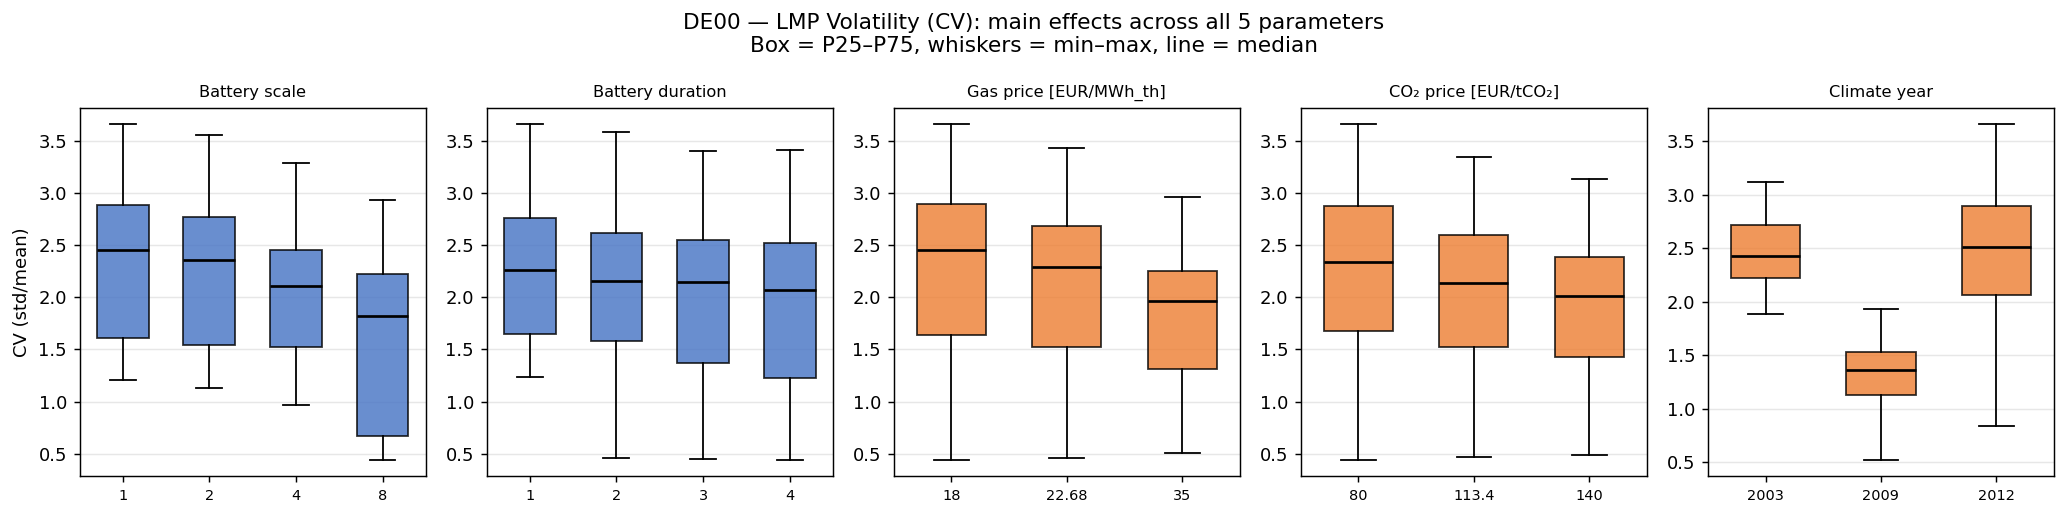

In [5]:
# Compute CV per scenario for DE00
lmp_std_s2 = lmp_raw.groupby("tag")[BUS].std().rename("lmp_std_s2")
lmp_mean_s2 = lmp_raw.groupby("tag")[BUS].mean().rename("lmp_mean_s2")
lmp_cv_s2 = (lmp_std_s2 / lmp_mean_s2).rename("lmp_cv_s2")
res = res.drop(columns=["lmp_cv_s2", "lmp_std_s2", "lmp_mean_s2"], errors="ignore")
res = res.set_index("tag").join(lmp_cv_s2).reset_index()

# Main effects: CV by each parameter level
params = {
    "bat_scale":    [1, 2, 4, 8],
    "bat_duration": [1, 2, 3, 4],
    "gas_price":    [18, 22.68, 35],
    "co2_price":    [80, 113.4, 140],
    "climate_year": [2003, 2009, 2012],
}
labels = {
    "bat_scale":    "Battery scale",
    "bat_duration": "Battery duration",
    "gas_price":    "Gas price [EUR/MWh_th]",
    "co2_price":    "CO₂ price [EUR/tCO₂]",
    "climate_year": "Climate year",
}

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for ax, (param, levels) in zip(axes, params.items()):
    data_for_box = [res[res[param] == lvl]["lmp_cv_s2"].values for lvl in levels]
    bp = ax.boxplot(data_for_box, positions=range(len(levels)), widths=0.6,
                   patch_artist=True, showfliers=False,
                   medianprops=dict(color="black", lw=1.5))
    color = "#4472c4" if "bat" in param else "#ed7d31"
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_xticks(range(len(levels)))
    ax.set_xticklabels([str(l) for l in levels], fontsize=8)
    ax.set_title(labels[param], fontsize=9)
    ax.set_ylabel("CV (std/mean)" if ax == axes[0] else "")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(f"{BUS} — LMP Volatility (CV): main effects across all 5 parameters\n"
             f"Box = P25–P75, whiskers = min–max, line = median", fontsize=12)
plt.tight_layout()
plt.show()

## Section 3 — ANOVA: Variance Decomposition (DE00)

Which parameter explains the most variance in DE00 LMP?

In [6]:
print(res.shape)
print(res.lmp_annual.isna().sum(), "NaN out of", len(res))
print(res[["tag","bat_scale","lmp_annual"]].head(3))
print("\nlmp_raw columns:", lmp_raw.columns.tolist()[:5])

(432, 23)
0 NaN out of 432
                               tag  bat_scale  lmp_annual
0  bat1x_gas18_co2_80_cy2003_dur1x          1   61.828888
1  bat1x_gas18_co2_80_cy2003_dur2x          1   61.218777
2  bat1x_gas18_co2_80_cy2003_dur3x          1   61.402092

lmp_raw columns: ['tag', 'timestamp', 'AL00', 'AT00', 'BA00']


In [7]:
print("lmp_raw tags:", lmp_raw["tag"].nunique())
print("storage_p tags:", storage_p_raw["tag"].nunique())
print("lmp_raw shape:", lmp_raw.shape)
print("storage_p shape:", storage_p_raw.shape)
print("lmp_raw buses:", lmp_raw.shape[1] - 2)
print("battery units:", len(bat_cols))
print("DE00 battery units:", len(de00_bat_cols))
print("\nSample tags:")
print(lmp_raw["tag"].unique()[:3])


lmp_raw tags: 432
storage_p tags: 432
lmp_raw shape: (3784320, 58)
storage_p shape: (3784320, 121)
lmp_raw buses: 56
battery units: 35
DE00 battery units: 1

Sample tags:
['bat1x_gas18_co2_80_cy2003_dur1x' 'bat1x_gas18_co2_80_cy2003_dur2x'
 'bat1x_gas18_co2_80_cy2003_dur3x']


Grand mean CV (std/mean): 2.051
Total SS: 237.012

             Parameter     SS  Var explained %  F-stat  p-value
          Climate year 136.78            57.71  292.72     0.00
         Battery scale  35.70            15.06   25.30     0.00
Gas price [EUR/MWh_th]  15.39             6.49   14.90     0.00
  CO₂ price [EUR/tCO₂]   7.83             3.31    7.33     0.00
      Battery duration   7.31             3.08    4.54     0.00


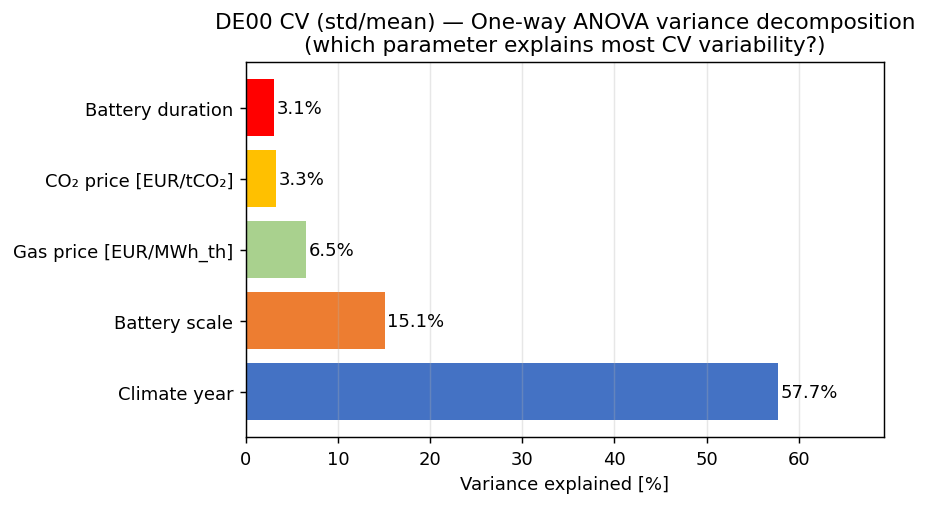

In [8]:
from scipy import stats

# ANOVA on lmp_cv (volatility) — more meaningful than lmp_annual (price level)
target = "lmp_cv_s2"  # computed in Section 2
target_label = "CV (std/mean)" 

grand_mean = res[target].mean()
ss_total = ((res[target] - grand_mean) ** 2).sum()

anova_rows = []
for param, levels in params.items():
    groups = [res[res[param] == lvl][target].values for lvl in levels]
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    f_stat, p_val = stats.f_oneway(*groups)
    anova_rows.append({
        "Parameter": labels[param],
        "SS": ss_between,
        "Var explained %": 100 * ss_between / ss_total,
        "F-stat": f_stat,
        "p-value": p_val,
    })

anova_df = pd.DataFrame(anova_rows).sort_values("Var explained %", ascending=False)
print(f"Grand mean {target_label}: {grand_mean:.3f}")
print(f"Total SS: {ss_total:.3f}")
print()
print(anova_df.to_string(index=False, float_format="{:.2f}".format))

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#4472c4", "#ed7d31", "#a9d18e", "#ffc000", "#ff0000"]
bars = ax.barh(anova_df["Parameter"], anova_df["Var explained %"], color=colors[:len(anova_df)])
for bar, val in zip(bars, anova_df["Var explained %"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f"{val:.1f}%", va="center")
ax.set_xlabel("Variance explained [%]")
ax.set_title(f"{BUS} {target_label} — One-way ANOVA variance decomposition\n(which parameter explains most CV variability?)")
ax.grid(axis="x", alpha=0.3)
ax.set_xlim(0, anova_df["Var explained %"].max() * 1.2)
plt.tight_layout()
plt.show()

In [9]:
# Export for thesis
fig.savefig("../tukedip_pdflatex_utf-8/figures/fig_anova.jpg", dpi=200, bbox_inches="tight")
print("Saved fig_anova.jpg")

Saved fig_anova.jpg


## Section 4 — Battery Analysis: Scale × Duration Heatmap

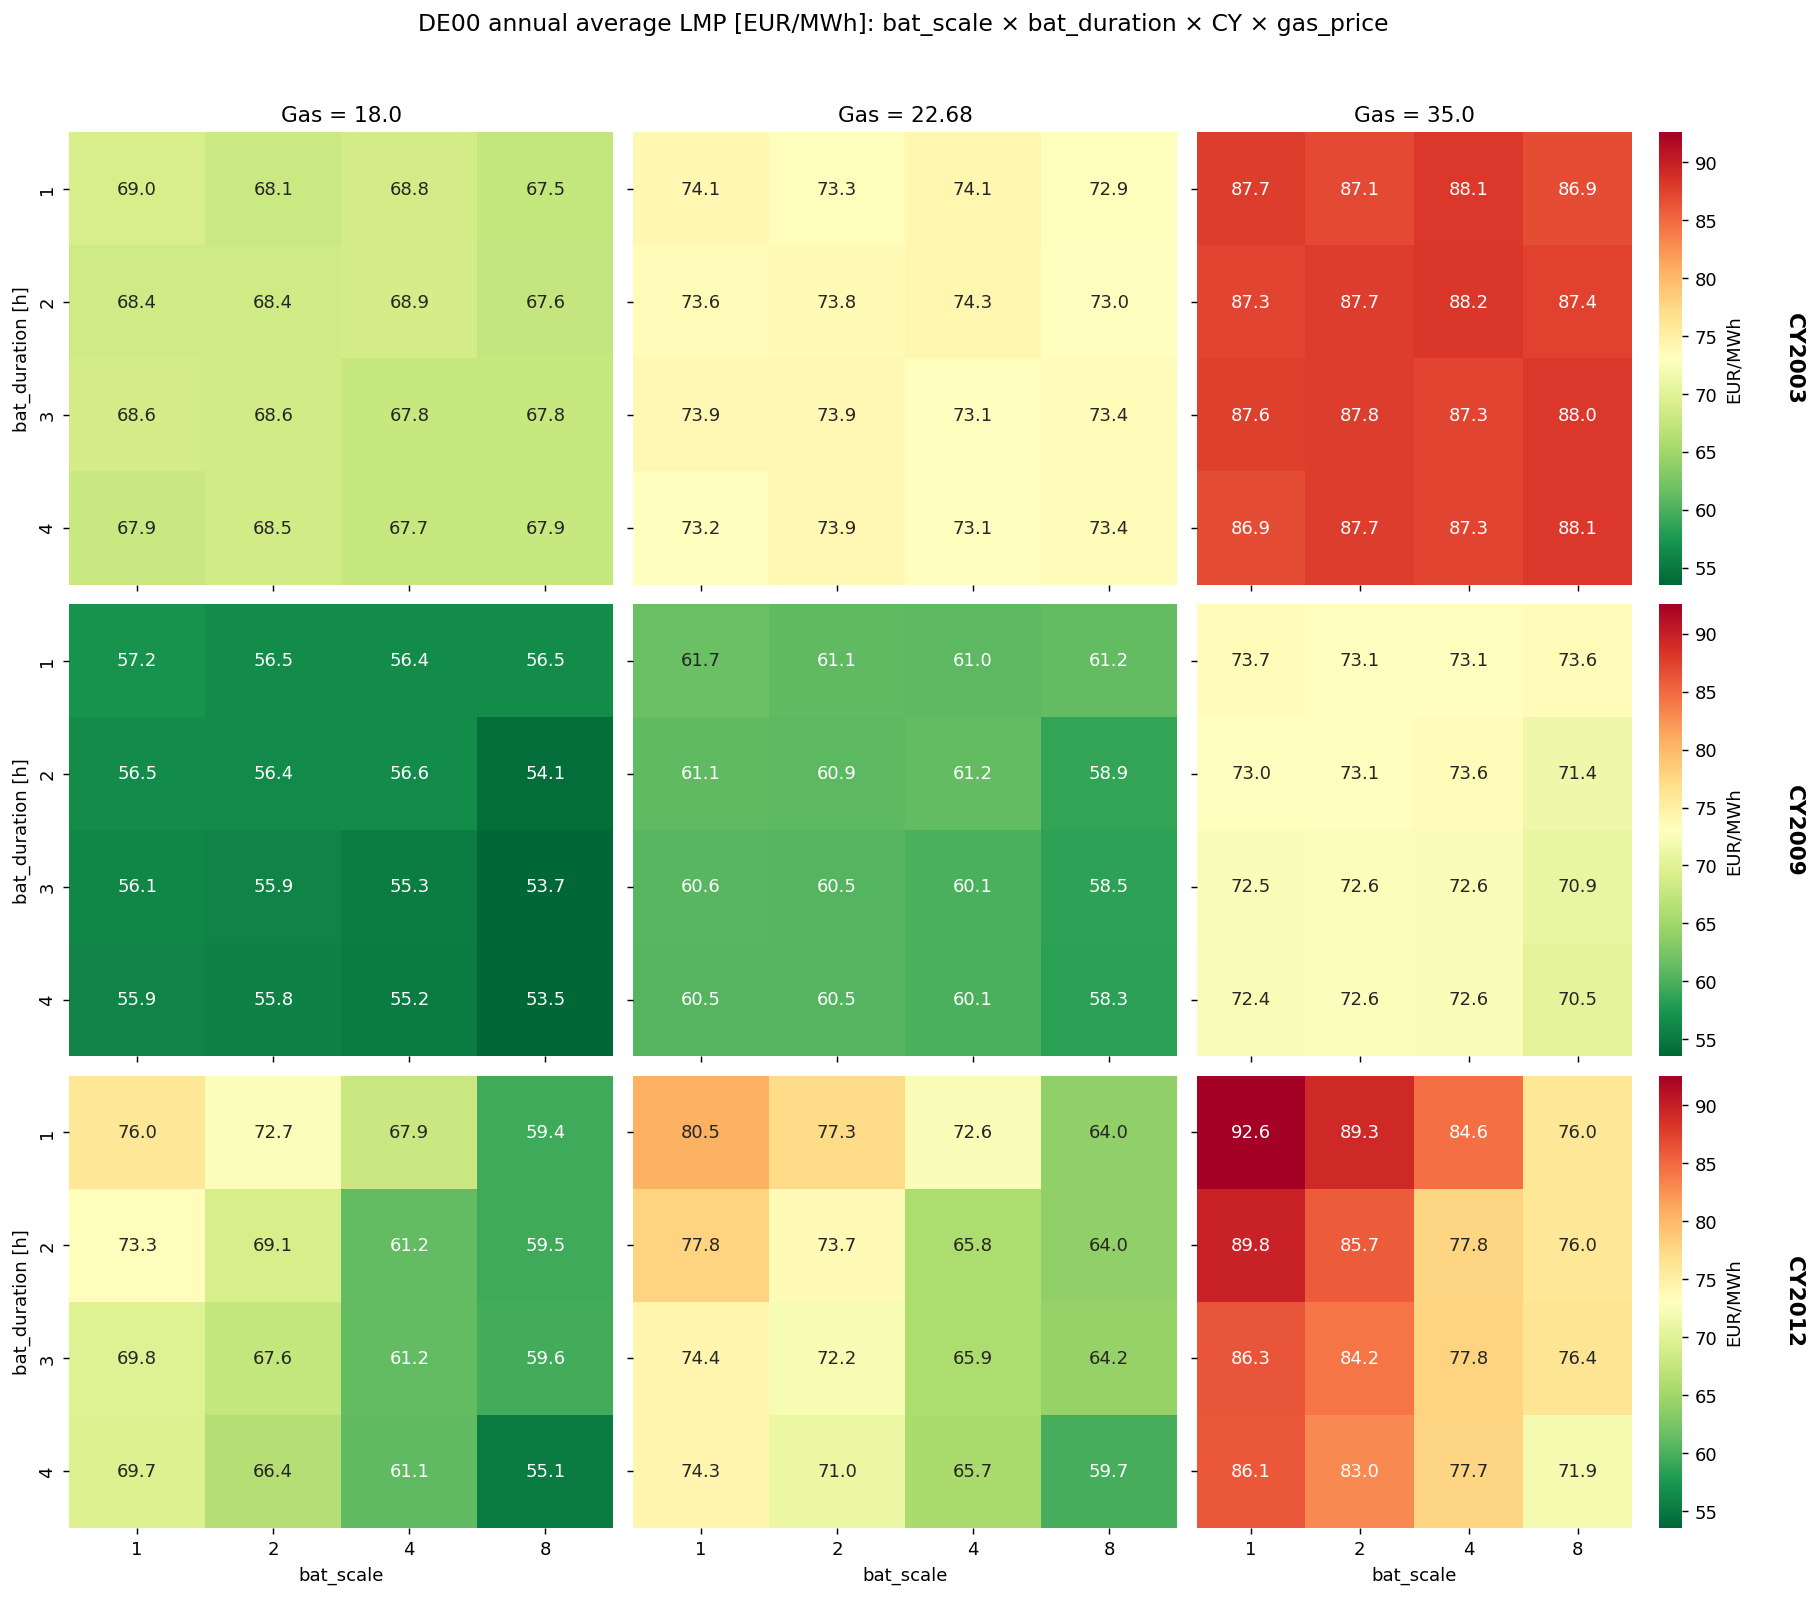

In [10]:
# LMP heatmap — 3×3 grid: CY rows × gas cols, bat_scale × bat_duration inside
CYS = sorted(res["climate_year"].unique())
GAS = sorted(res["gas_price"].unique())

fig, axes = plt.subplots(3, 3, figsize=(14, 12), sharex=True, sharey=True)

all_medians = res.groupby(["climate_year", "gas_price", "bat_duration", "bat_scale"])["lmp_annual"].median()
vmin, vmax = all_medians.min(), all_medians.max()

for row, cy in enumerate(CYS):
    for col, gp in enumerate(GAS):
        ax = axes[row, col]
        sub = res[(res["climate_year"] == cy) & (res["gas_price"] == gp)]
        pivot = sub.groupby(["bat_duration", "bat_scale"])["lmp_annual"].median().reset_index()
        hm = pivot.pivot(index="bat_duration", columns="bat_scale", values="lmp_annual")

        sns.heatmap(hm, annot=True, fmt=".1f", cmap="RdYlGn_r", ax=ax,
                    cbar=col == 2, vmin=vmin, vmax=vmax,
                    cbar_kws={"label": "EUR/MWh"} if col == 2 else {})
        ax.set_xlabel("bat_scale" if row == 2 else "")
        ax.set_ylabel("bat_duration [h]" if col == 0 else "")

        if row == 0:
            ax.set_title(f"Gas = {gp}")
        if col == 2:
            ax.yaxis.set_label_position("right")
            ax.text(1.35, 0.5, f"CY{cy}", transform=ax.transAxes,
                    rotation=-90, va="center", fontsize=12, fontweight="bold")

plt.suptitle("DE00 annual average LMP [EUR/MWh]: bat_scale × bat_duration × CY × gas_price", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## Section 5 — Interaction Effects: gas_price × co2_price

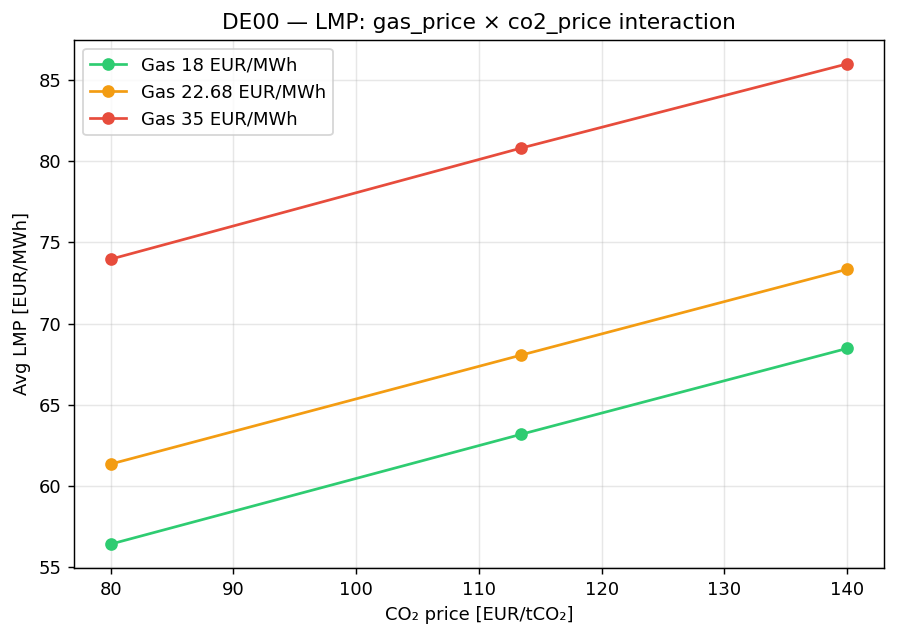

In [11]:
gas_prices = [18, 22.68, 35]
co2_prices = [80, 113.4, 140]

fig, ax = plt.subplots(figsize=(7, 5))
colors_gas = ["#2ecc71", "#f39c12", "#e74c3c"]

for gas_p, color in zip(gas_prices, colors_gas):
    means = [res[(res.gas_price == gas_p) & (res.co2_price == co2_p)]["lmp_annual"].mean()
             for co2_p in co2_prices]
    ax.plot(co2_prices, means, marker="o", color=color, label=f"Gas {gas_p} EUR/MWh")

ax.set_xlabel("CO₂ price [EUR/tCO₂]")
ax.set_ylabel("Avg LMP [EUR/MWh]")
ax.set_title(f"{BUS} — LMP: gas_price × co2_price interaction")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Section 6 — Climate Year Comparison

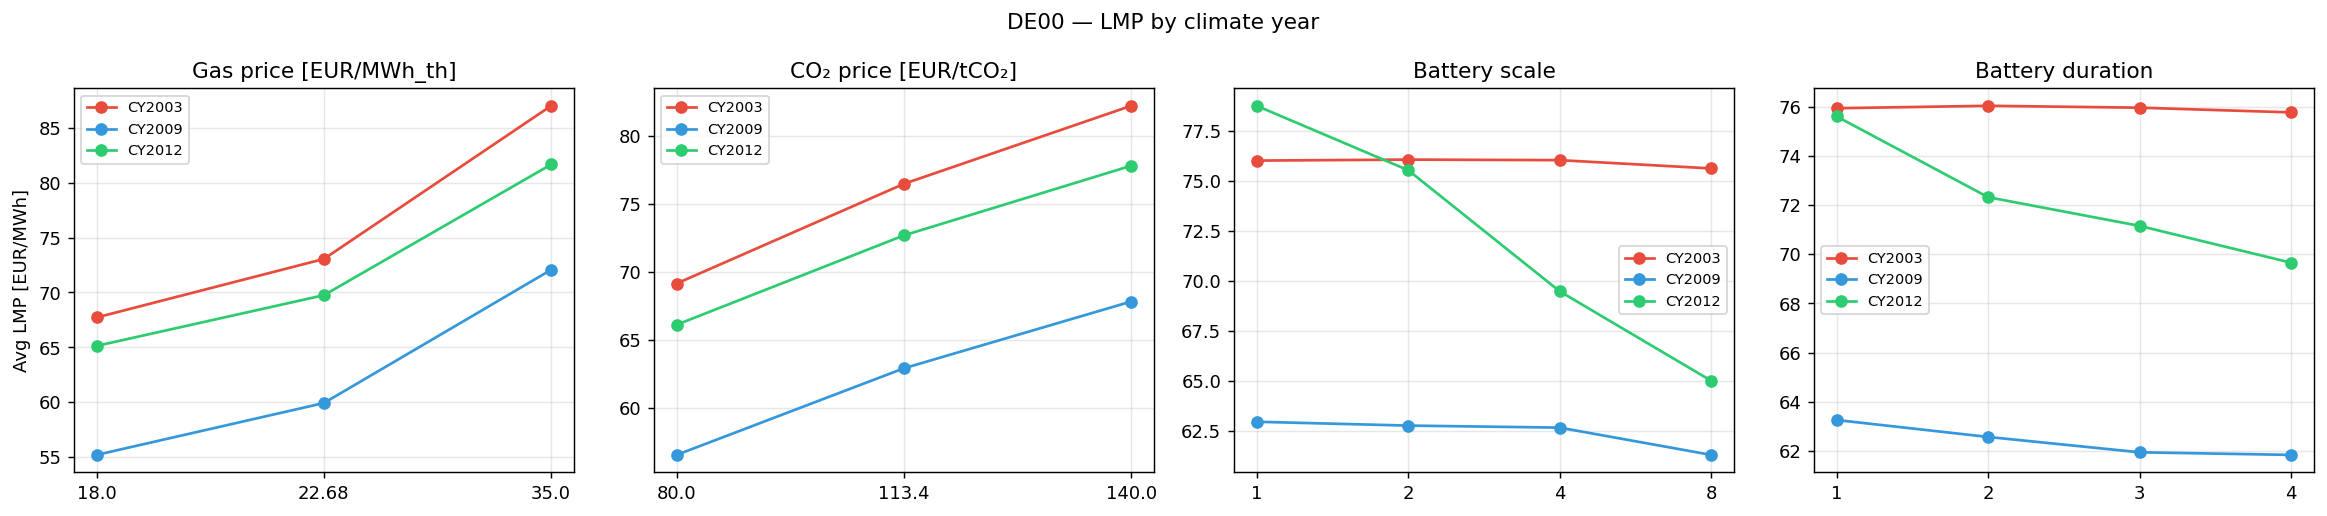


DE00 average LMP by climate year:
  CY2003: mean=75.9  min=60.2  max=93.9 EUR/MWh
  CY2009: mean=62.4  min=47.3  max=78.5 EUR/MWh
  CY2012: mean=72.2  min=48.4  max=97.5 EUR/MWh


In [12]:
cy_colors = {2003: "#e74c3c", 2009: "#3498db", 2012: "#2ecc71"}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, param in zip(axes, ["gas_price", "co2_price", "bat_scale", "bat_duration"]):
    levels = sorted(res[param].unique())
    for cy, color in cy_colors.items():
        means = [res[(res.climate_year == cy) & (res[param] == lvl)]["lmp_annual"].mean()
                 for lvl in levels]
        ax.plot(range(len(levels)), means, marker="o", color=color, label=f"CY{cy}")
    ax.set_xticks(range(len(levels)))
    ax.set_xticklabels([str(l) for l in levels])
    ax.set_title(labels.get(param, param))
    ax.set_ylabel("Avg LMP [EUR/MWh]" if ax == axes[0] else "")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle(f"{BUS} — LMP by climate year", fontsize=12)
plt.tight_layout()
plt.show()

# Summary table
print(f"\n{BUS} average LMP by climate year:")
for cy in [2003, 2009, 2012]:
    lmps = res[res.climate_year == cy]["lmp_annual"]
    print(f"  CY{cy}: mean={lmps.mean():.1f}  min={lmps.min():.1f}  max={lmps.max():.1f} EUR/MWh")

## Battery Operations Analysis

Sections on storage revenue, buy/sell prices, installed capacity, hourly charging profiles,
and SOC arbitrage patterns have been moved to **battery_arbitrage_analysis.ipynb**
to keep this notebook focused on sensitivity analysis methodology.

## Section 7 — How Batteries Reduce Price Volatility (DE00)

Representative subset: gas=22.68, co2=113.4, dur=2×, all bat_scales × all climate years.

Three panels:
1. **Price Duration Curve** — 8760 LMP values sorted descending; batteries flatten extremes
2. **Hourly LMP profile** — avg LMP by hour of day; batteries shave morning/evening peaks
3. **LMP std deviation vs bat_scale** — quantitative measure of volatility reduction

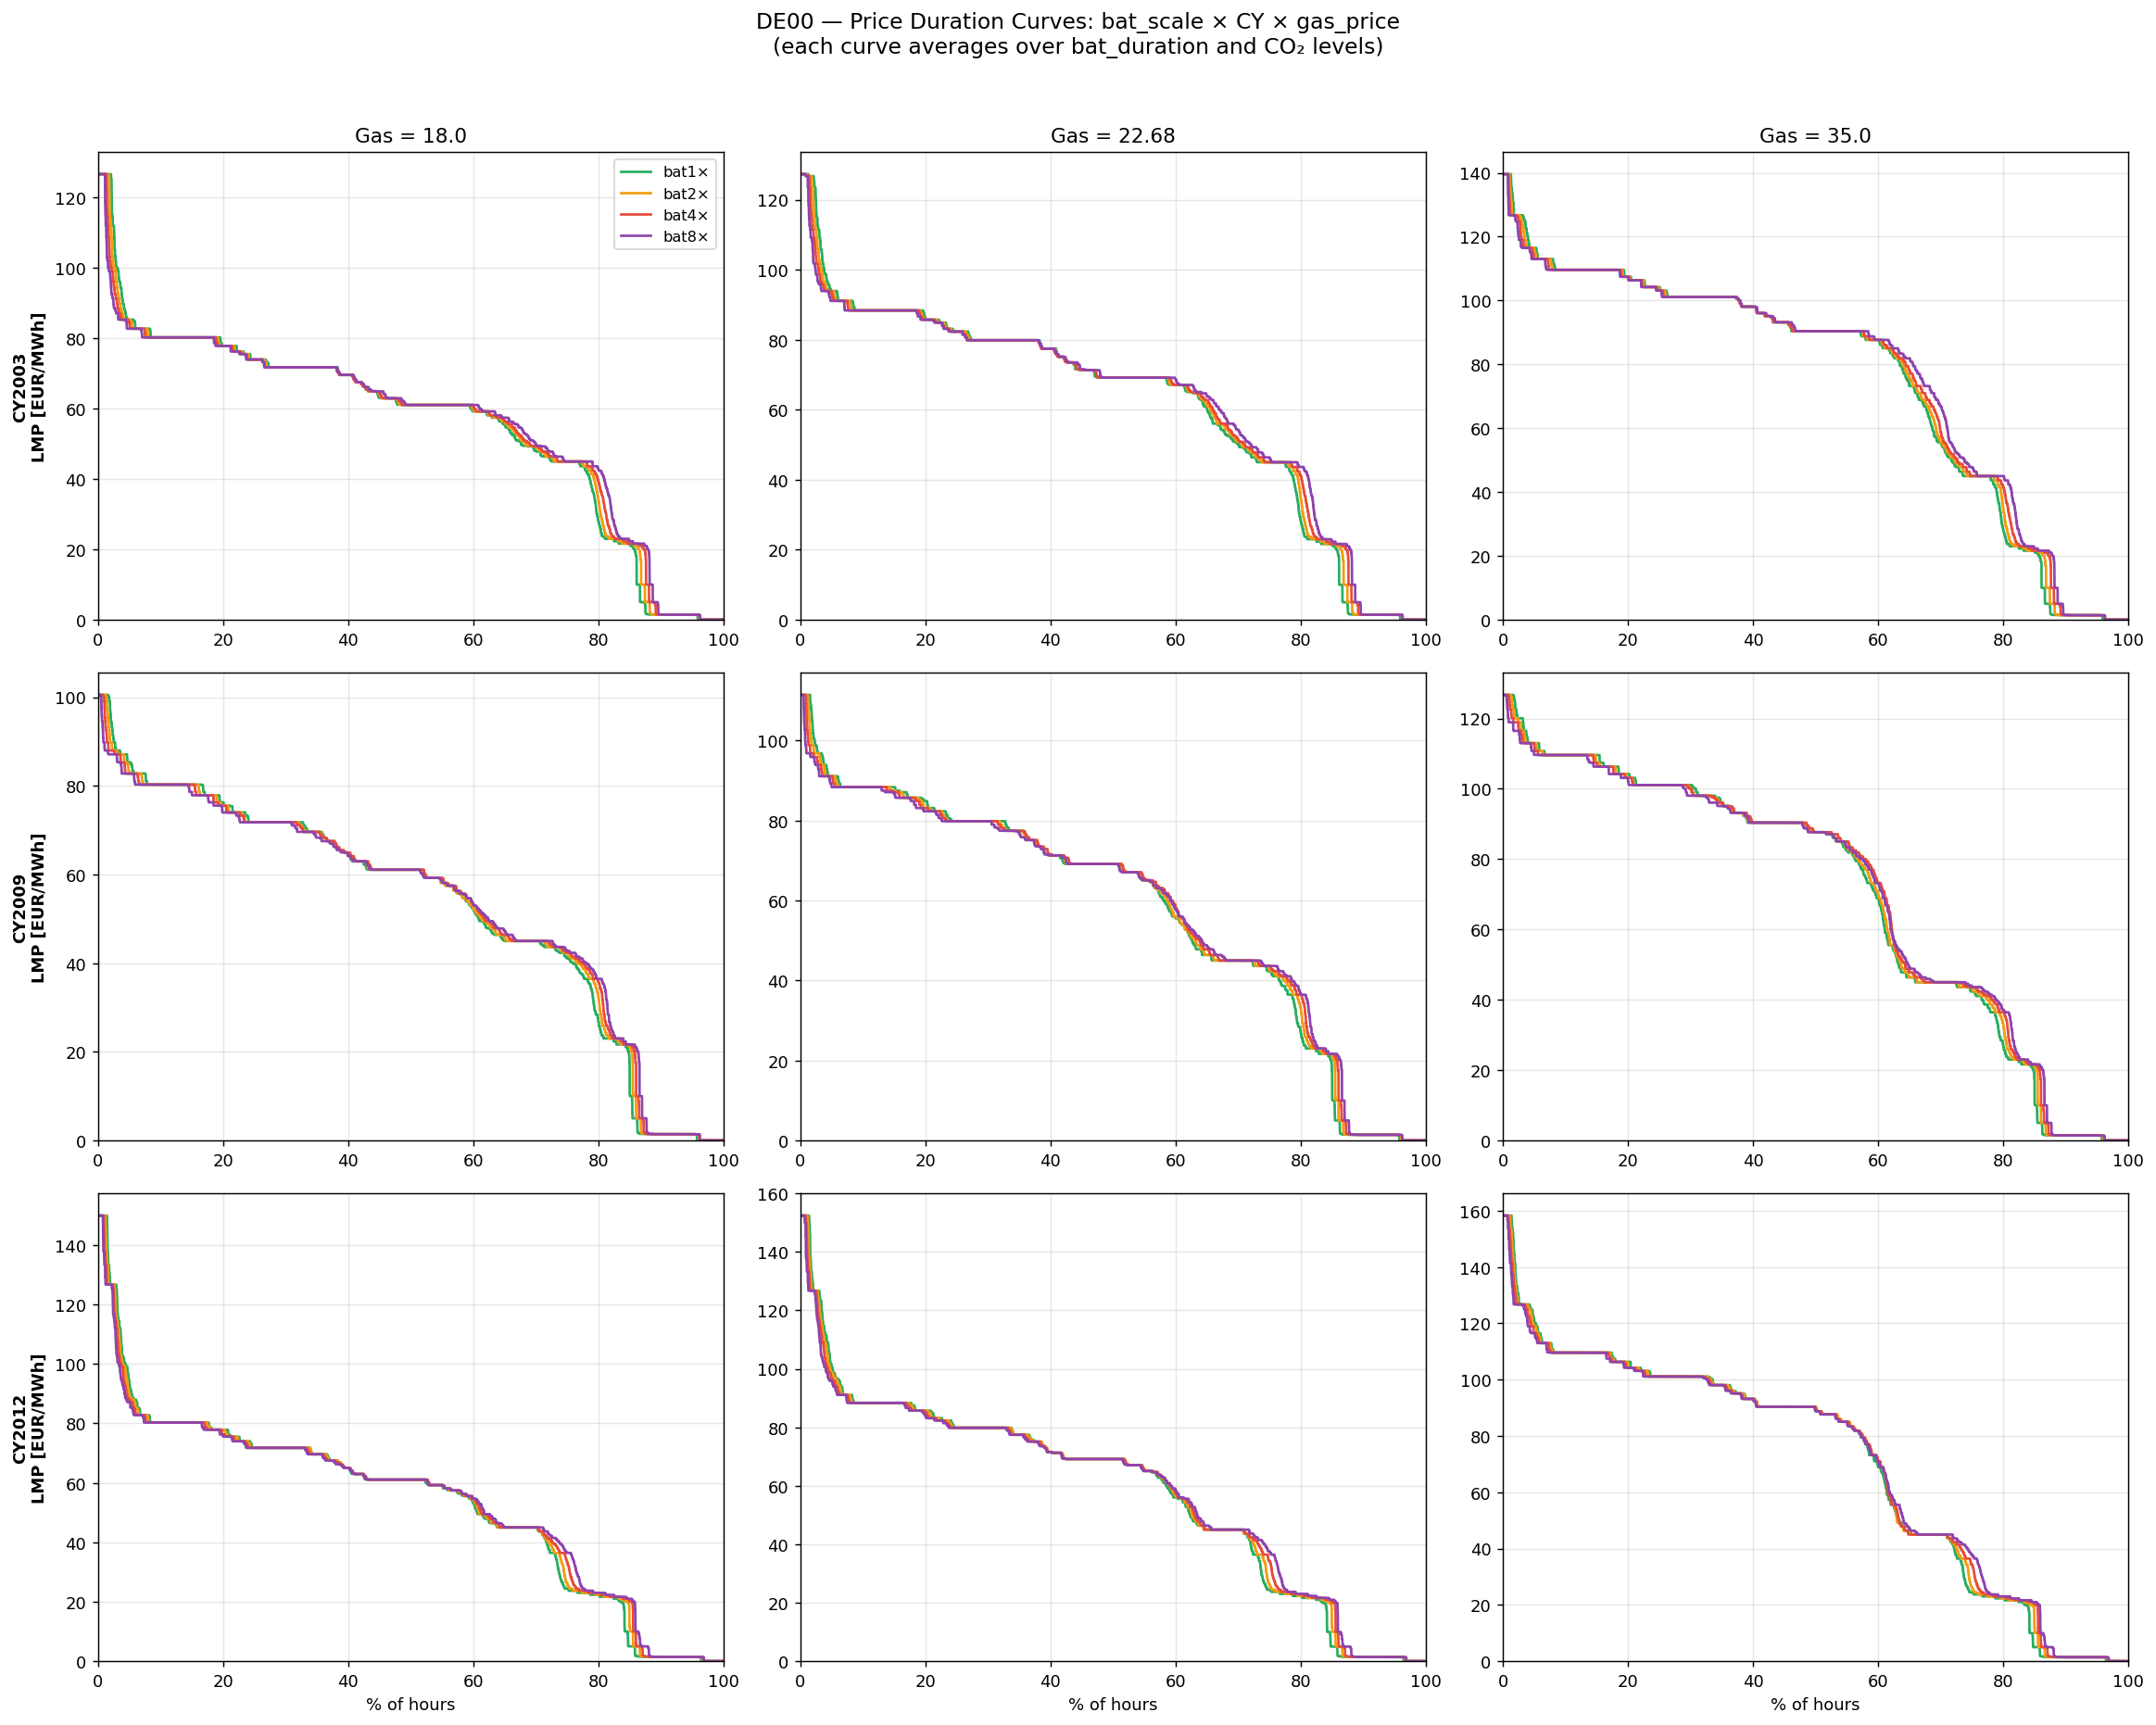

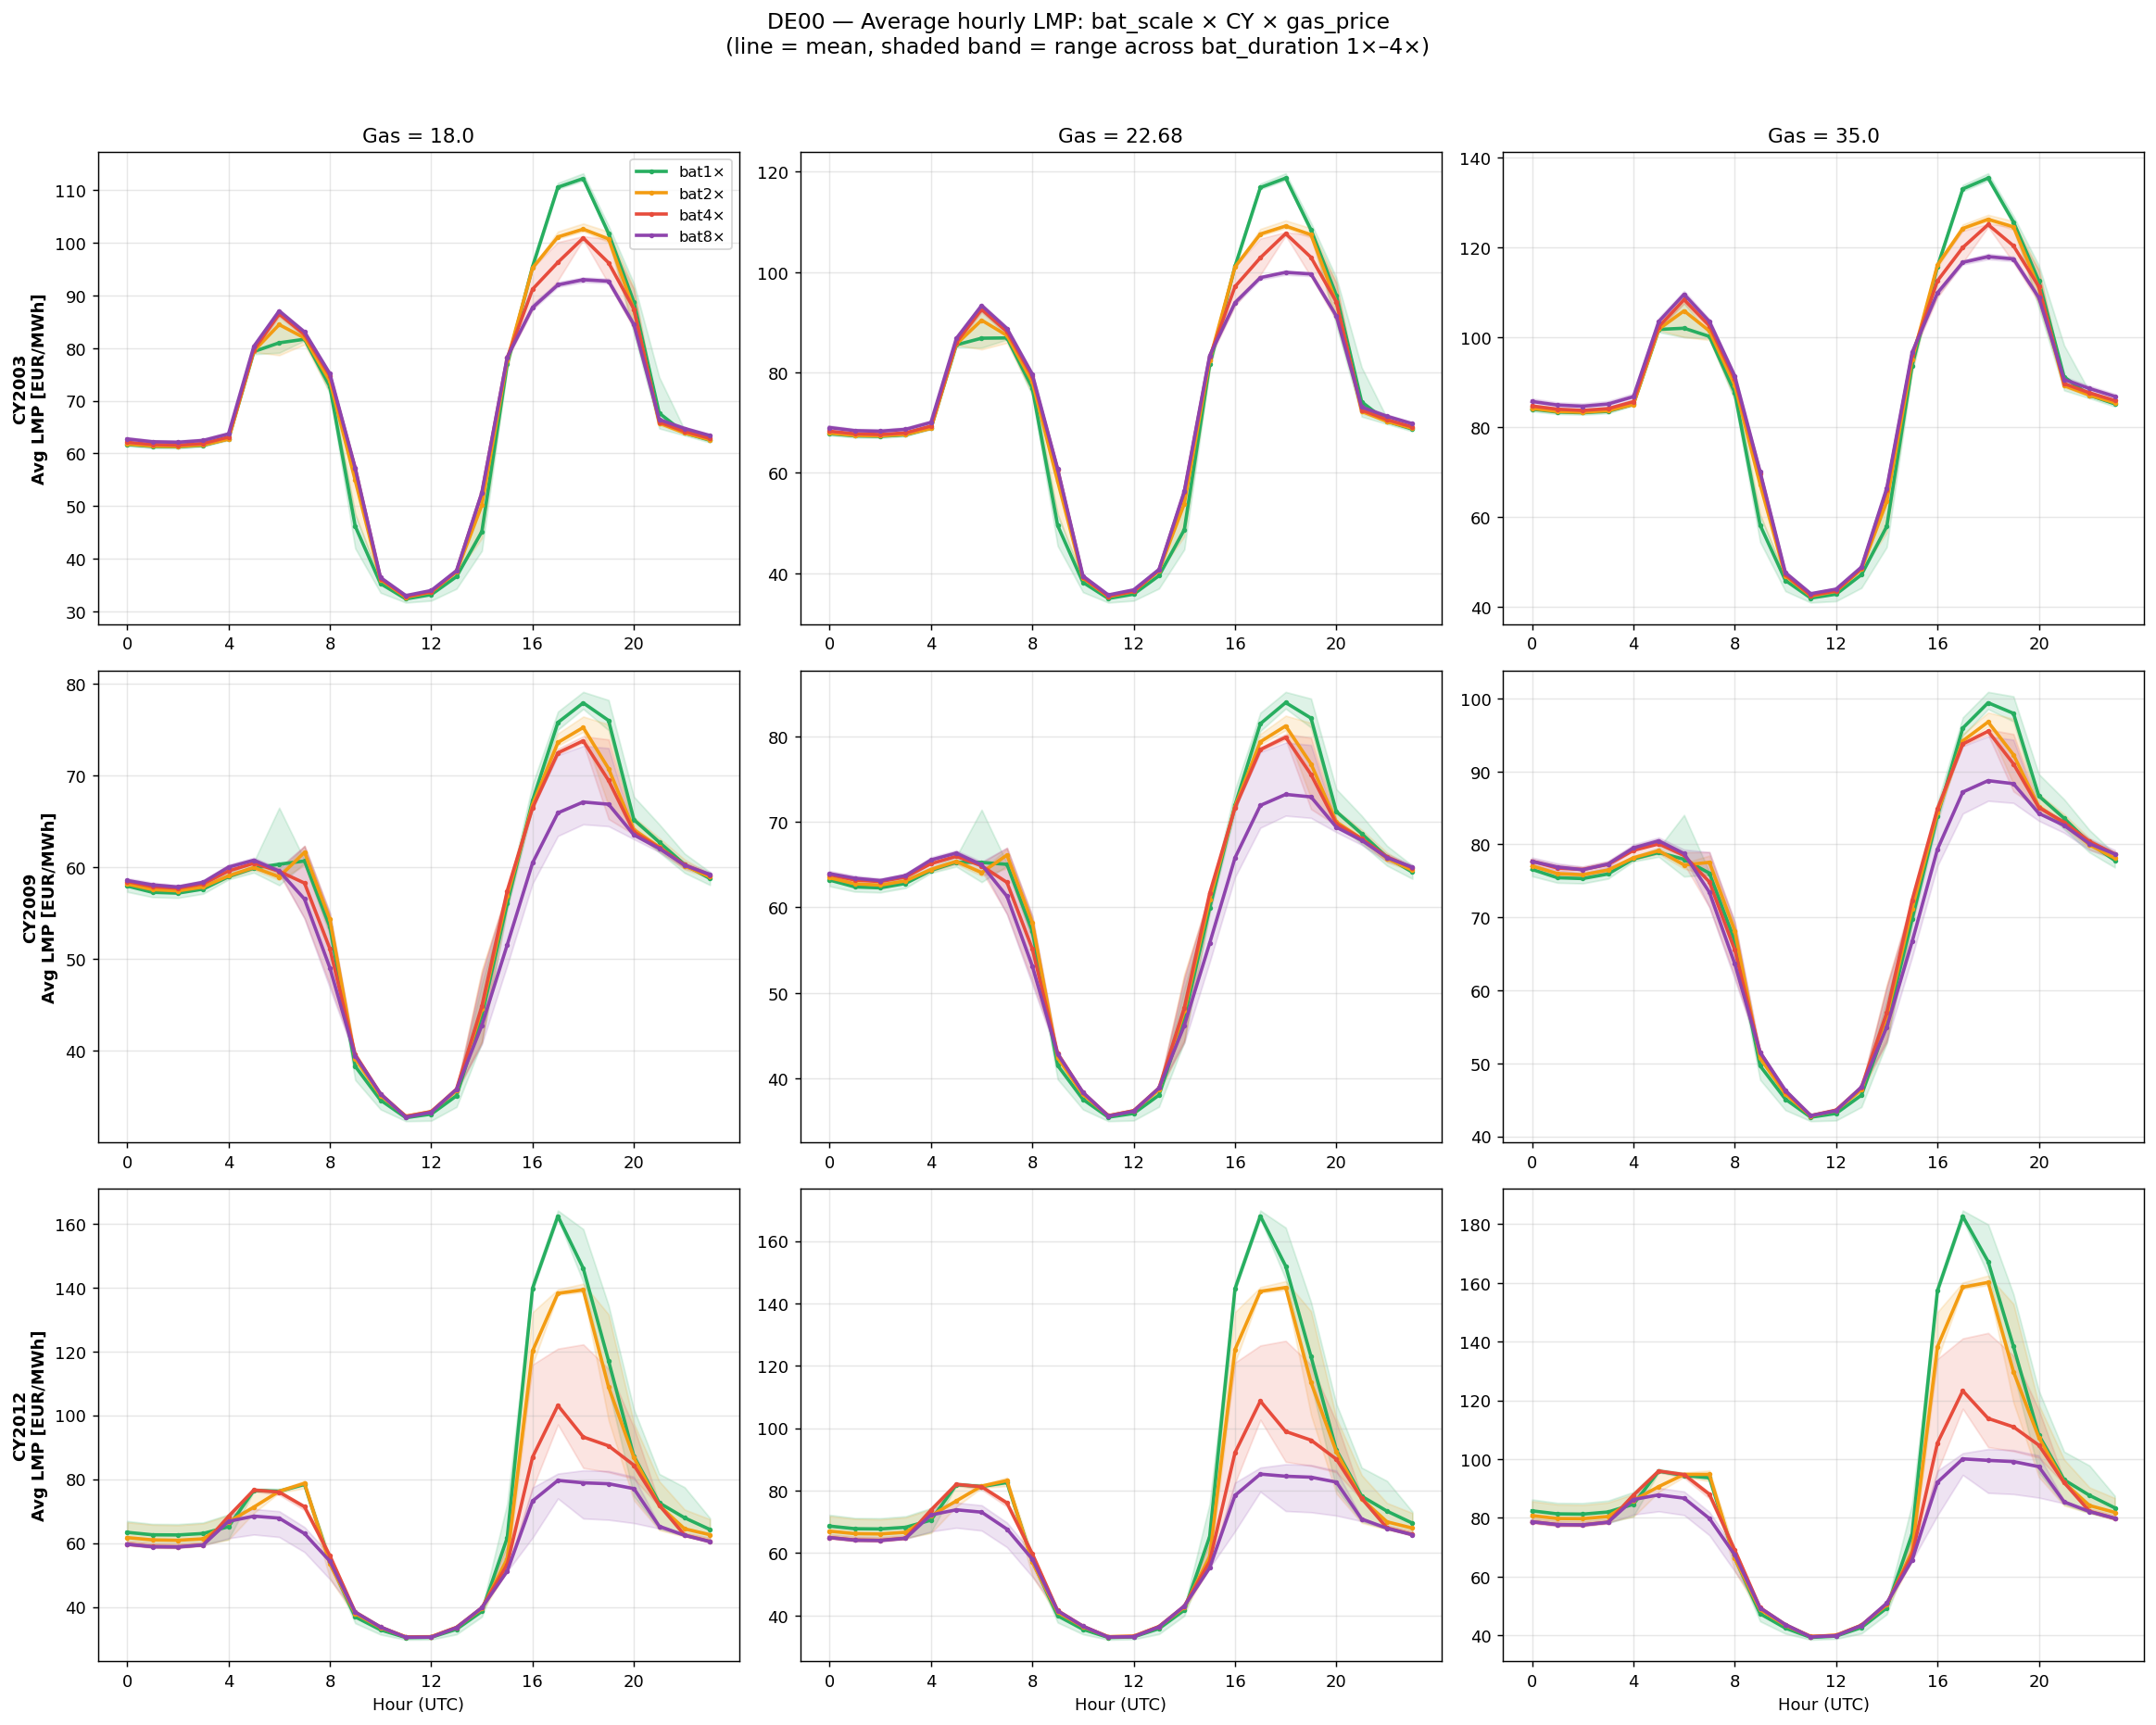

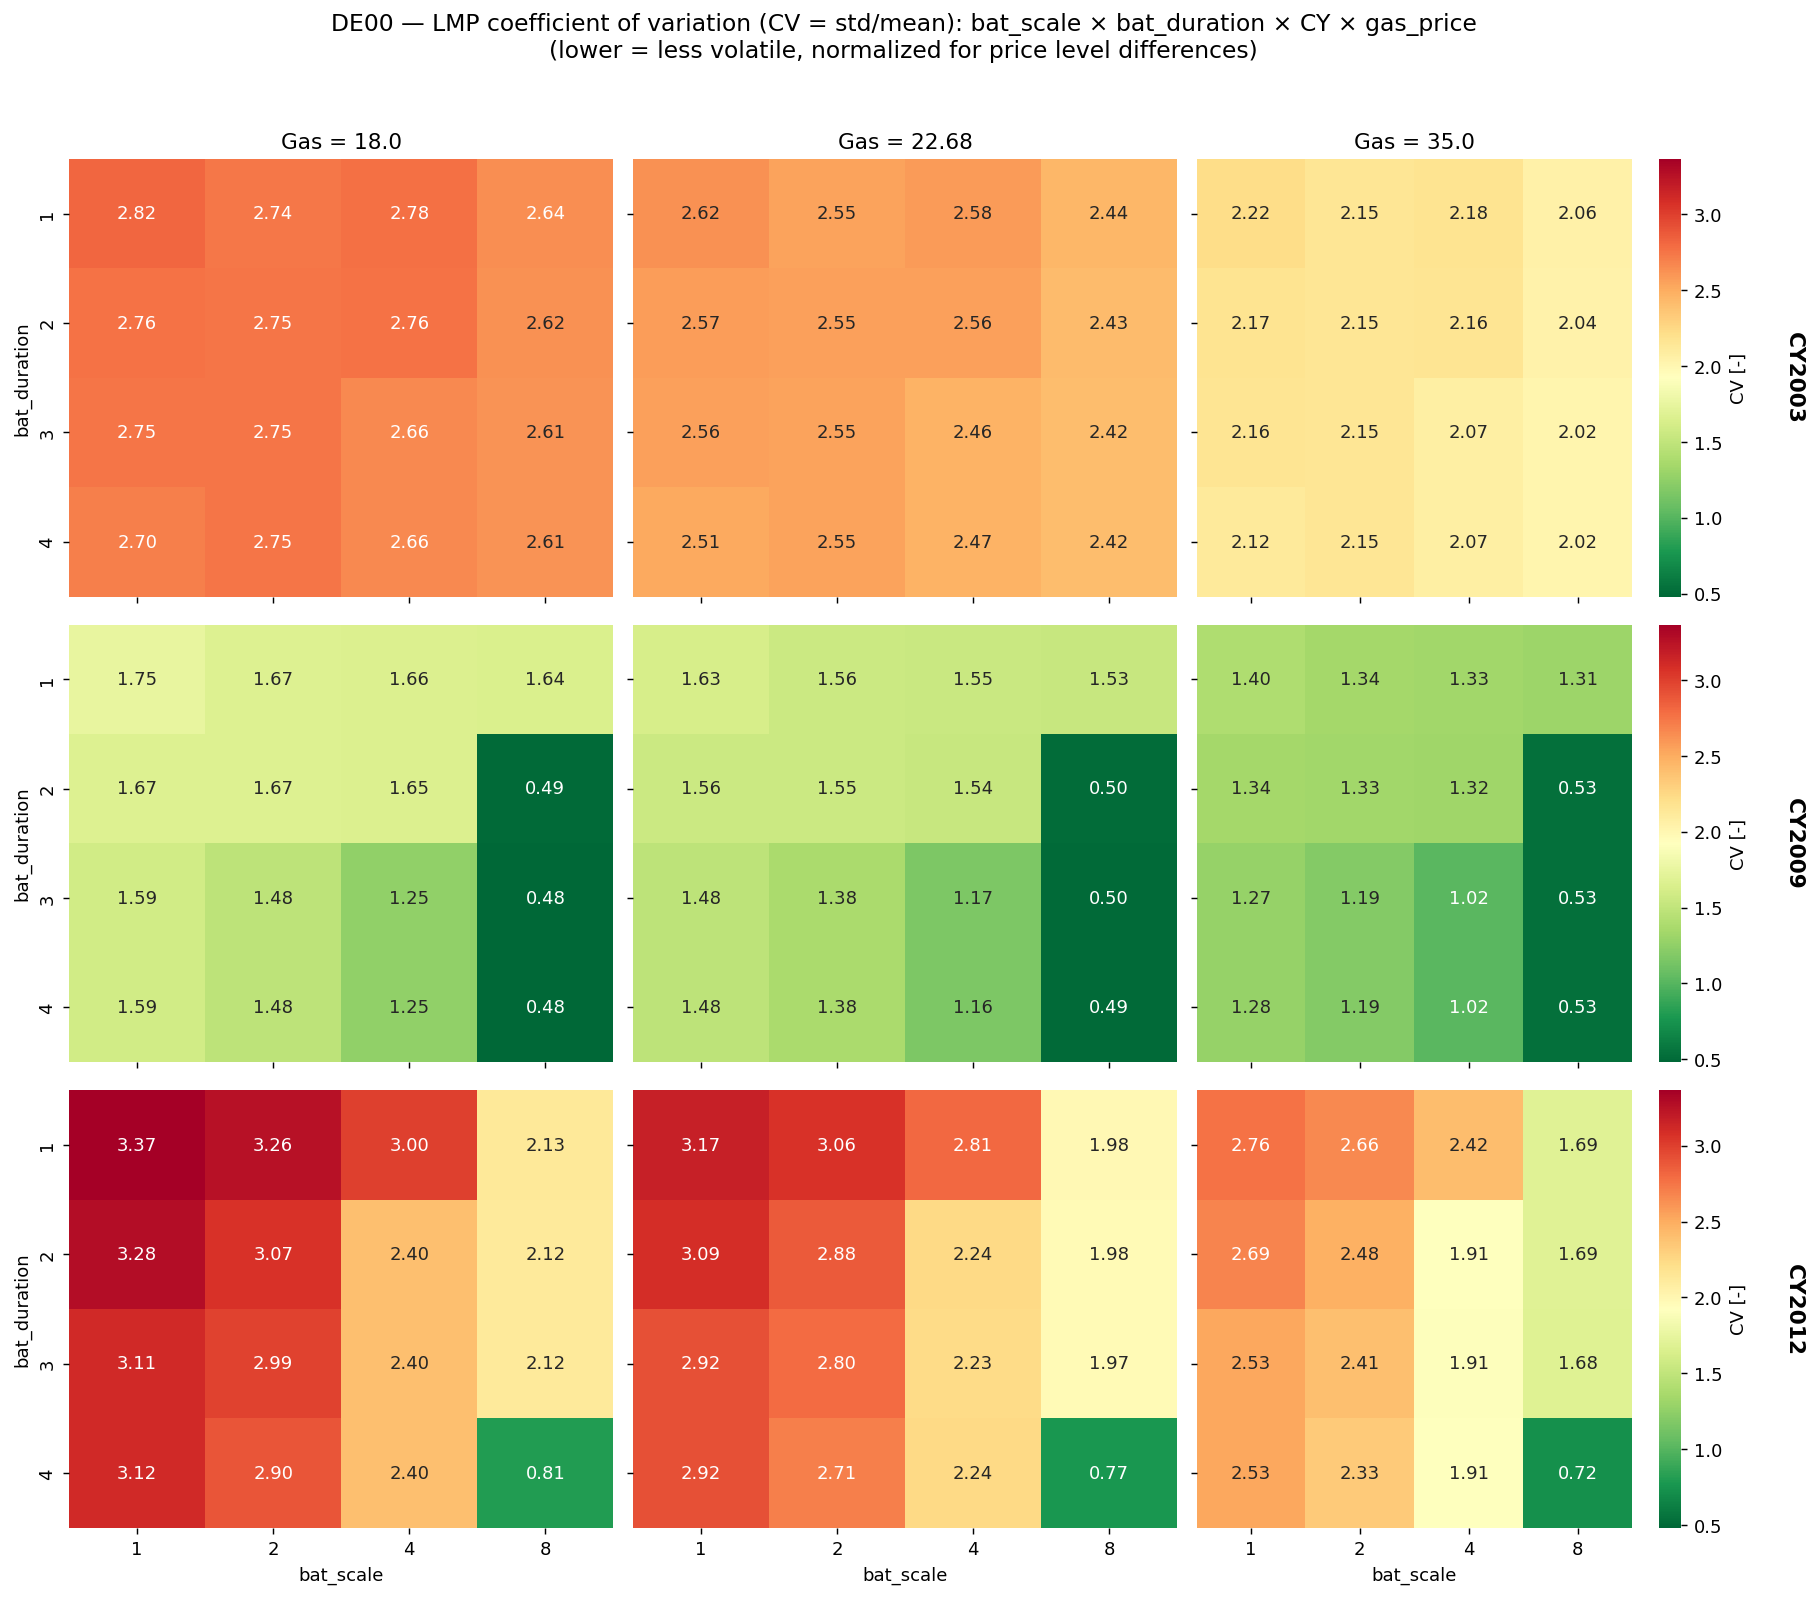

In [13]:
BUS_V = "DE00"
SCALES = [1, 2, 4, 8]
DURATIONS = [1, 2, 3, 4]
scale_colors = {1: "#27ae60", 2: "#f39c12", 4: "#e74c3c", 8: "#8e44ad"}

CYS_V = sorted(res["climate_year"].unique())
GAS_V = sorted(res["gas_price"].unique())

# 3×3 Price Duration Curve grid: CY rows × gas cols, 4 bat_scale krivky v každom paneli
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for row, cy in enumerate(CYS_V):
    for col, gp in enumerate(GAS_V):
        ax = axes[row, col]
        
        sub = res[(res.gas_price == gp) & (res.climate_year == cy)]
        lmp_sub = lmp_raw[lmp_raw["tag"].isin(sub["tag"])][["tag", BUS_V]].copy()
        lmp_sub = lmp_sub.merge(sub[["tag", "bat_scale", "bat_duration"]], on="tag")
        
        all_vals = lmp_sub[BUS_V].values
        pdc_cap = np.percentile(all_vals[np.isfinite(all_vals)], 99)
        
        for s in SCALES:
            color = scale_colors[s]
            # Average across durations and co2 prices
            vals = lmp_sub[lmp_sub.bat_scale == s][BUS_V].values
            sorted_vals = np.sort(vals)[::-1]
            x = np.linspace(0, 100, len(sorted_vals))
            clipped = np.minimum(sorted_vals, pdc_cap)
            ax.plot(x, clipped, color=color, lw=1.5, label=f"bat{s}×" if row == 0 and col == 0 else "")
        
        ax.set_ylim(bottom=0, top=pdc_cap * 1.05)
        ax.set_xlim(0, 100)
        ax.grid(alpha=0.3)
        
        if row == 0:
            ax.set_title(f"Gas = {gp}")
        if col == 0:
            ax.set_ylabel(f"CY{cy}\nLMP [EUR/MWh]", fontsize=10, fontweight="bold")
        if row == 2:
            ax.set_xlabel("% of hours")

axes[0, 0].legend(fontsize=9, loc="upper right")
plt.suptitle(f"{BUS_V} — Price Duration Curves: bat_scale × CY × gas_price\n(each curve averages over bat_duration and CO₂ levels)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# 3×3 Avg hourly LMP: CY rows × gas cols, with duration bands
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for row, cy in enumerate(CYS_V):
    for col, gp in enumerate(GAS_V):
        ax = axes[row, col]
        
        sub = res[(res.gas_price == gp) & (res.climate_year == cy)]
        lmp_sub = lmp_raw[lmp_raw["tag"].isin(sub["tag"])][["tag", "timestamp", BUS_V]].copy()
        lmp_sub = lmp_sub.merge(sub[["tag", "bat_scale", "bat_duration"]], on="tag")
        lmp_sub["hour"] = lmp_sub["timestamp"].dt.hour
        
        for s in SCALES:
            color = scale_colors[s]
            # Compute hourly mean per duration
            hourly_by_dur = {}
            for d in DURATIONS:
                h = lmp_sub[(lmp_sub.bat_scale == s) & (lmp_sub.bat_duration == d)].groupby("hour")[BUS_V].mean()
                hourly_by_dur[d] = h
            
            # Band between dur1 and dur4
            if len(hourly_by_dur) >= 2:
                lo = pd.DataFrame(hourly_by_dur).min(axis=1)
                hi = pd.DataFrame(hourly_by_dur).max(axis=1)
                ax.fill_between(lo.index, lo.values, hi.values, color=color, alpha=0.15)
            
            # Line = mean across durations
            hourly_mean = lmp_sub[lmp_sub.bat_scale == s].groupby("hour")[BUS_V].mean()
            ax.plot(hourly_mean.index, hourly_mean.values, color=color, lw=2, marker="o", markersize=2,
                    label=f"bat{s}×" if row == 0 and col == 0 else "")
        
        ax.grid(alpha=0.3)
        ax.set_xticks(range(0, 24, 4))
        
        if row == 0:
            ax.set_title(f"Gas = {gp}")
        if col == 0:
            ax.set_ylabel(f"CY{cy}\nAvg LMP [EUR/MWh]", fontsize=10, fontweight="bold")
        if row == 2:
            ax.set_xlabel("Hour (UTC)")

axes[0, 0].legend(fontsize=9)
plt.suptitle(f"{BUS_V} — Average hourly LMP: bat_scale × CY × gas_price\n(line = mean, shaded band = range across bat_duration 1×–4×)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# LMP CV heatmap — 3×3 grid (CV = std/mean, relative volatility)
fig, axes = plt.subplots(3, 3, figsize=(14, 12), sharex=True, sharey=True)

all_cvs = []
for cy in CYS_V:
    for gp in GAS_V:
        sub = res[(res.climate_year == cy) & (res.gas_price == gp)]
        lmp_sub = lmp_raw[lmp_raw["tag"].isin(sub["tag"])][["tag", BUS_V]].copy()
        lmp_sub = lmp_sub.merge(sub[["tag", "bat_scale", "bat_duration"]], on="tag")
        for s in SCALES:
            for d in DURATIONS:
                vals = lmp_sub[(lmp_sub.bat_scale == s) & (lmp_sub.bat_duration == d)][BUS_V]
                all_cvs.append(vals.std() / vals.mean() if vals.mean() != 0 else 0)
vmin_cv, vmax_cv = min(all_cvs), max(all_cvs)

for row, cy in enumerate(CYS_V):
    for col, gp in enumerate(GAS_V):
        ax = axes[row, col]
        sub = res[(res.climate_year == cy) & (res.gas_price == gp)]
        lmp_sub = lmp_raw[lmp_raw["tag"].isin(sub["tag"])][["tag", BUS_V]].copy()
        lmp_sub = lmp_sub.merge(sub[["tag", "bat_scale", "bat_duration"]], on="tag")
        
        cv_matrix = np.zeros((len(DURATIONS), len(SCALES)))
        for i, d in enumerate(DURATIONS):
            for j, s in enumerate(SCALES):
                vals = lmp_sub[(lmp_sub.bat_scale == s) & (lmp_sub.bat_duration == d)][BUS_V]
                cv_matrix[i, j] = vals.std() / vals.mean() if vals.mean() != 0 else 0
        
        hm_df = pd.DataFrame(cv_matrix, index=DURATIONS, columns=SCALES)
        sns.heatmap(hm_df, annot=True, fmt=".2f", cmap="RdYlGn_r", ax=ax,
                    cbar=col == 2, vmin=vmin_cv, vmax=vmax_cv,
                    cbar_kws={"label": "CV [-]"} if col == 2 else {})
        ax.set_xlabel("bat_scale" if row == 2 else "")
        ax.set_ylabel("bat_duration" if col == 0 else "")
        
        if row == 0:
            ax.set_title(f"Gas = {gp}")
        if col == 2:
            ax.yaxis.set_label_position("right")
            ax.text(1.35, 0.5, f"CY{cy}", transform=ax.transAxes,
                    rotation=-90, va="center", fontsize=12, fontweight="bold")

plt.suptitle(f"{BUS_V} — LMP coefficient of variation (CV = std/mean): bat_scale × bat_duration × CY × gas_price\n(lower = less volatile, normalized for price level differences)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## Section 8 — Volatility Metrics: CV, Spike Hours, Near-Zero Hours

Thesis research question: *how do battery parameters affect LMP volatility?*

Metrics computed for every scenario (DE00):
- **LMP std** — absolute price volatility
- **CV** = std / mean — relative volatility (scale-invariant)
- **Spike hours** — hours > 150 €/MWh (scarcity events)
- **Near-zero hours** — hours < 1 €/MWh (VRE surplus / curtailment proxy)


In [14]:
BUS_VOL = "DE00"

lmp_bus = lmp_raw[["tag", BUS_VOL]].copy()

lmp_std   = lmp_bus.groupby("tag")[BUS_VOL].std().rename("lmp_std")
lmp_mean_ = lmp_bus.groupby("tag")[BUS_VOL].mean().rename("_mean")
lmp_cv    = (lmp_std / lmp_mean_).rename("lmp_cv")
spike_h   = lmp_bus.groupby("tag")[BUS_VOL].apply(lambda x: int((x > 150).sum())).rename("spike_hours")
zero_h    = lmp_bus.groupby("tag")[BUS_VOL].apply(lambda x: int((x < 1).sum())).rename("zero_hours")

# Drop lmp_cv if already exists from ANOVA cell
res_clean = res.drop(columns=["lmp_cv", "lmp_std"], errors="ignore")

res_vol = (
    res_clean.set_index("tag")
    .join(lmp_std).join(lmp_cv).join(spike_h).join(zero_h)
    .reset_index()
)

print(f"Volatility metrics added. CV range: {res_vol.lmp_cv.min():.3f} – {res_vol.lmp_cv.max():.3f}")
print(f"Spike hours range:   {res_vol.spike_hours.min()} – {res_vol.spike_hours.max()} h/yr")
print(f"Near-zero hours:     {res_vol.zero_hours.min()} – {res_vol.zero_hours.max()} h/yr")
res_vol[["tag","bat_scale","bat_duration","gas_price","co2_price","climate_year",
         "lmp_annual","lmp_std","lmp_cv","spike_hours","zero_hours"]].head(3)


Volatility metrics added. CV range: 0.444 – 3.656
Spike hours range:   0 – 242 h/yr
Near-zero hours:     270 – 426 h/yr


,tag,bat_scale,bat_duration,gas_price,co2_price,climate_year,lmp_annual,lmp_std,lmp_cv,spike_hours,zero_hours
0,bat1x_gas18_co2_80_cy2003_dur1x,1,1,18.0,80.0,2003,61.828888,192.774734,3.117875,75,422
1,bat1x_gas18_co2_80_cy2003_dur2x,1,2,18.0,80.0,2003,61.218777,187.513443,3.063005,46,355
2,bat1x_gas18_co2_80_cy2003_dur3x,1,3,18.0,80.0,2003,61.402092,187.197937,3.048723,44,335


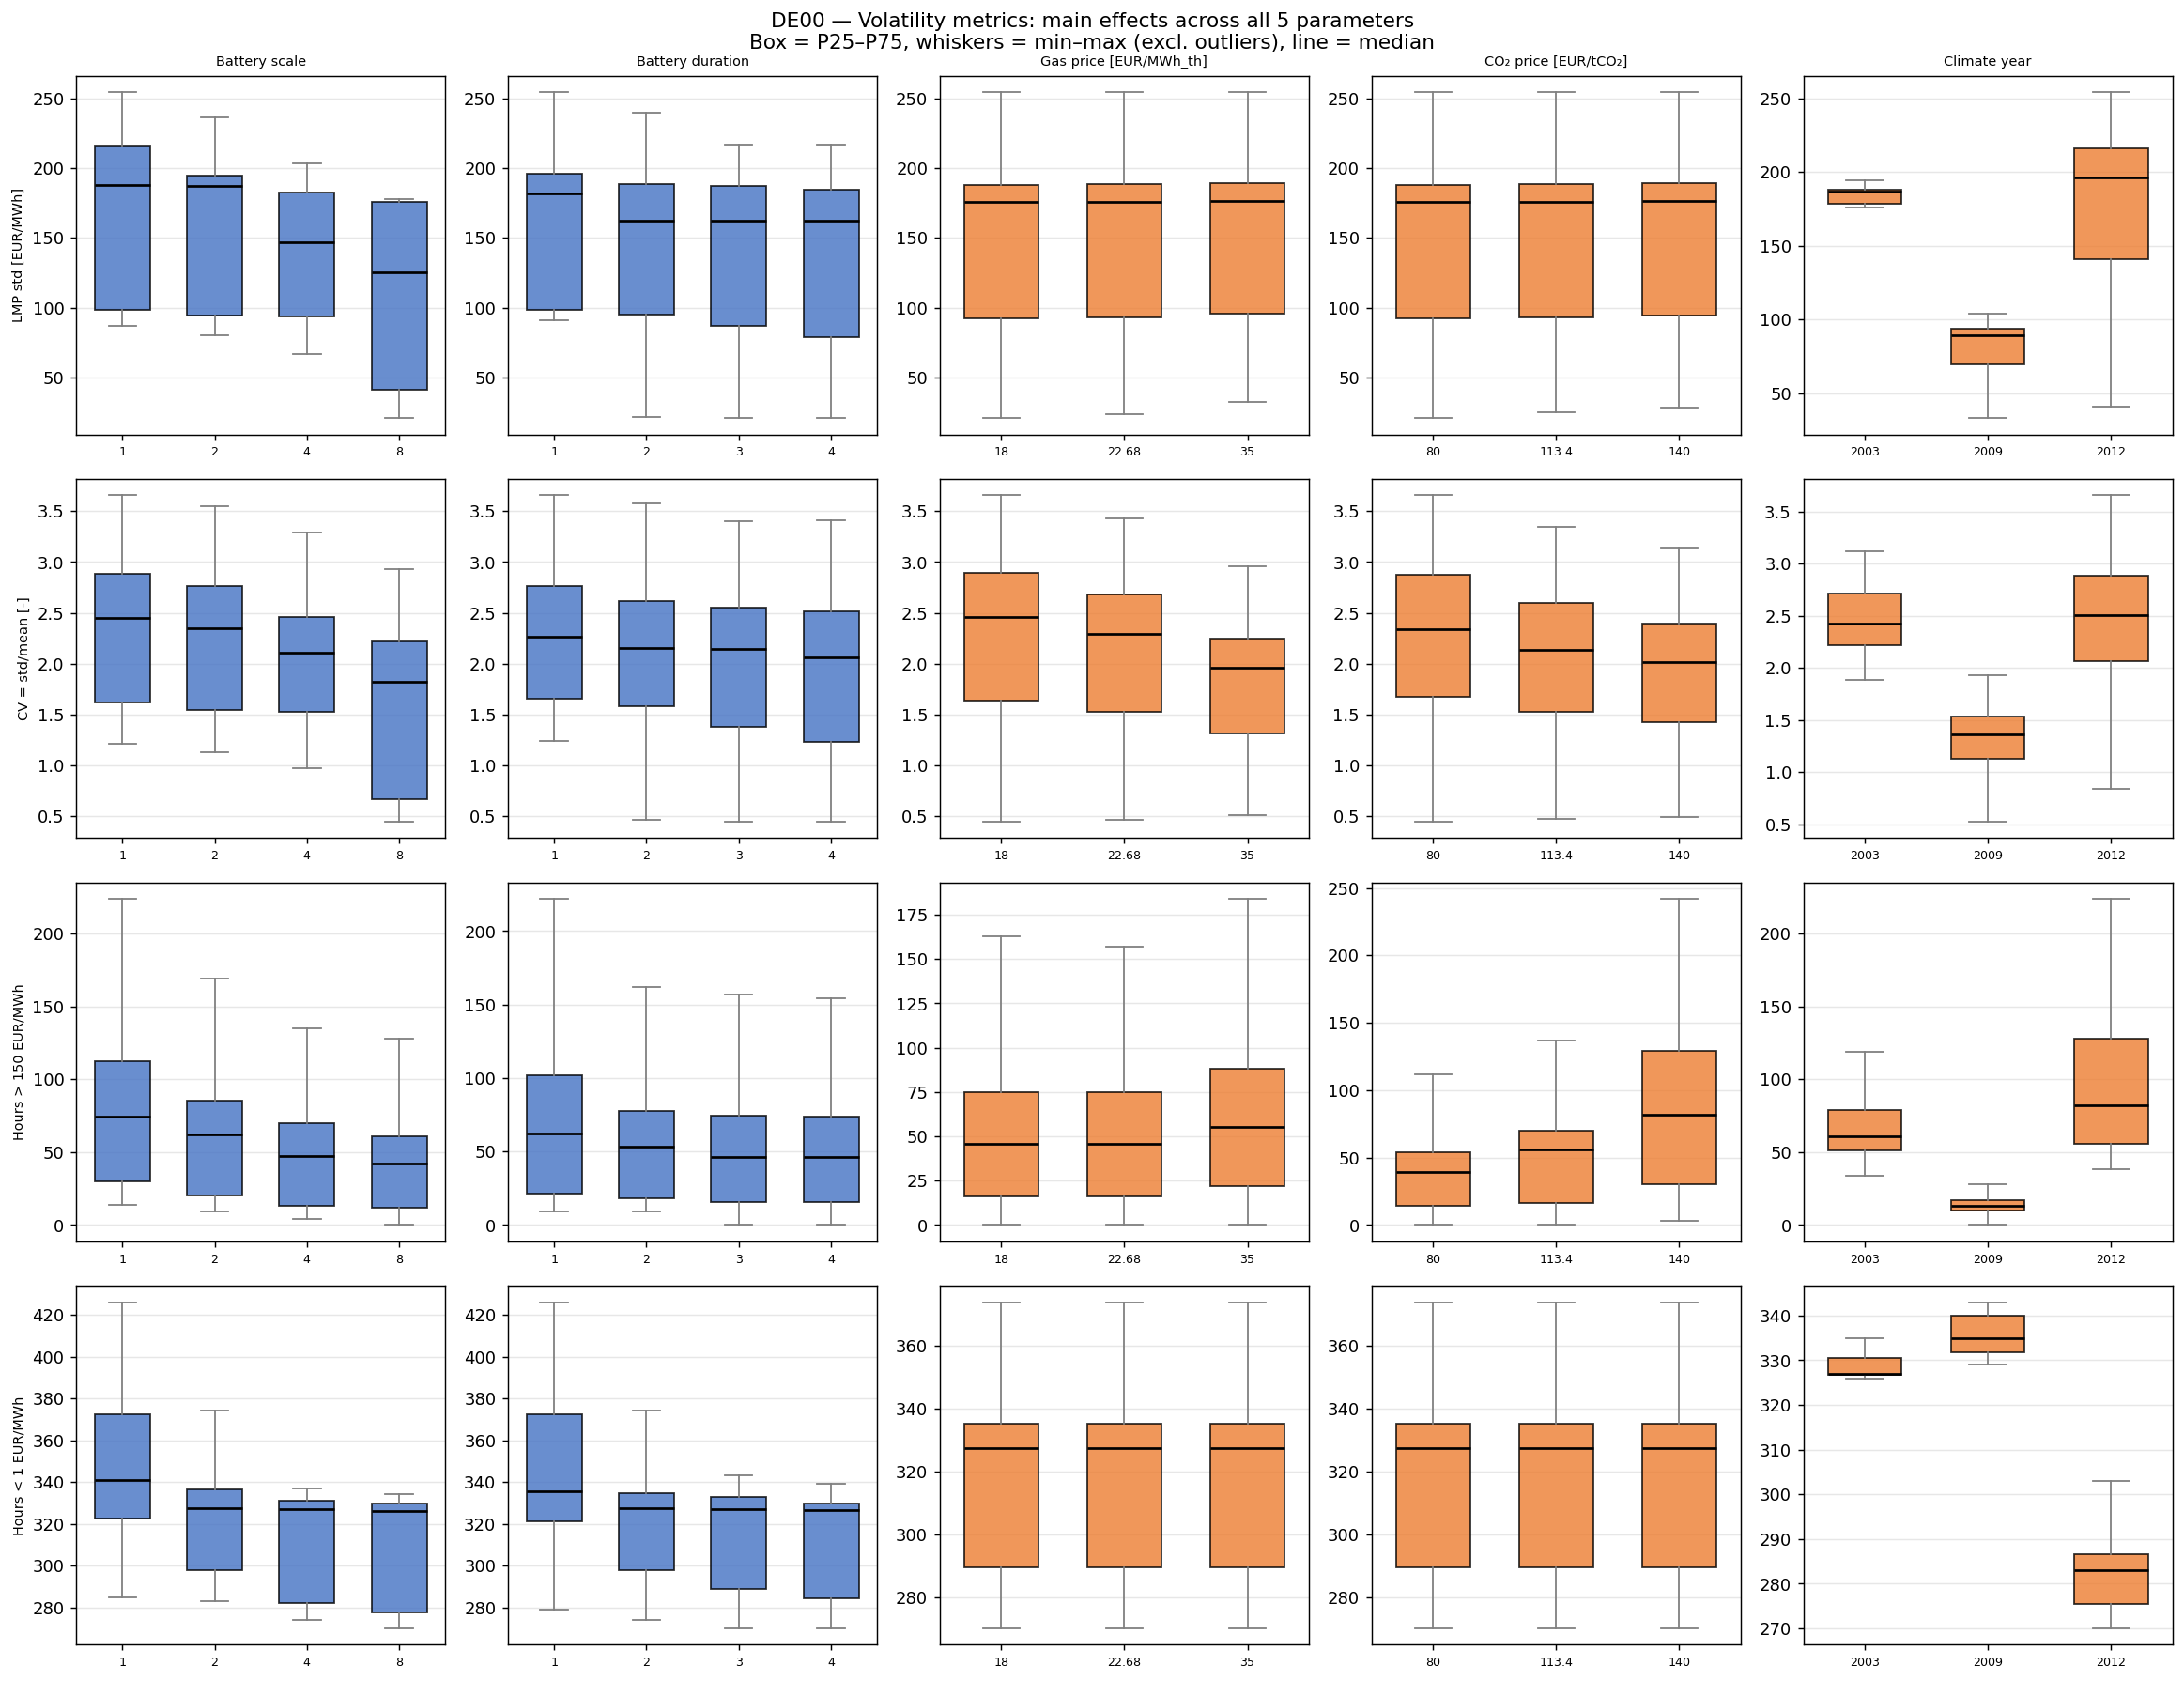

In [15]:
vol_metrics = {
    "lmp_std":     ("LMP std [EUR/MWh]",   "Absolute volatility"),
    "lmp_cv":      ("CV = std/mean [-]",    "Relative volatility"),
    "spike_hours": ("Hours > 150 EUR/MWh",  "Price spikes"),
    "zero_hours":  ("Hours < 1 EUR/MWh",    "Near-zero prices"),
}

params_vol = {
    "bat_scale":    [1, 2, 4, 8],
    "bat_duration": [1, 2, 3, 4],
    "gas_price":    [18, 22.68, 35],
    "co2_price":    [80, 113.4, 140],
    "climate_year": [2003, 2009, 2012],
}
param_labels = {
    "bat_scale":    "Battery scale",
    "bat_duration": "Battery duration",
    "gas_price":    "Gas price [EUR/MWh_th]",
    "co2_price":    "CO₂ price [EUR/tCO₂]",
    "climate_year": "Climate year",
}

fig, axes = plt.subplots(len(vol_metrics), len(params_vol), figsize=(18, 14))

for row, (metric, (ylabel, _)) in enumerate(vol_metrics.items()):
    for col, (param, levels) in enumerate(params_vol.items()):
        ax = axes[row, col]
        data_for_box = [res_vol[res_vol[param] == lvl][metric].values for lvl in levels]
        color = "#4472c4" if "bat" in param else "#ed7d31"
        bp = ax.boxplot(data_for_box, positions=range(len(levels)), widths=0.6,
                       patch_artist=True, showfliers=False,
                       medianprops=dict(color="black", lw=1.5),
                       whiskerprops=dict(color="gray"),
                       capprops=dict(color="gray"))
        for patch in bp["boxes"]:
            patch.set_facecolor(color)
            patch.set_alpha(0.8)
        ax.set_xticks(range(len(levels)))
        ax.set_xticklabels([str(l) for l in levels], fontsize=7)
        if col == 0:
            ax.set_ylabel(ylabel, fontsize=8)
        if row == 0:
            ax.set_title(param_labels[param], fontsize=8)
        ax.grid(axis="y", alpha=0.3)

fig.suptitle(f"{BUS_VOL} — Volatility metrics: main effects across all 5 parameters\n"
             f"Box = P25–P75, whiskers = min–max (excl. outliers), line = median", fontsize=12)
plt.tight_layout()
plt.show()

## Section 9 — Spatial Analysis: Which Countries Benefit Most

Compare bat_scale=1× vs bat_scale=8× for all 55 buses.
Fixed: gas=22.68, co2=113.4, dur=1×, averaged over 3 climate years.

Shows absolute and relative LMP reduction per bidding zone.


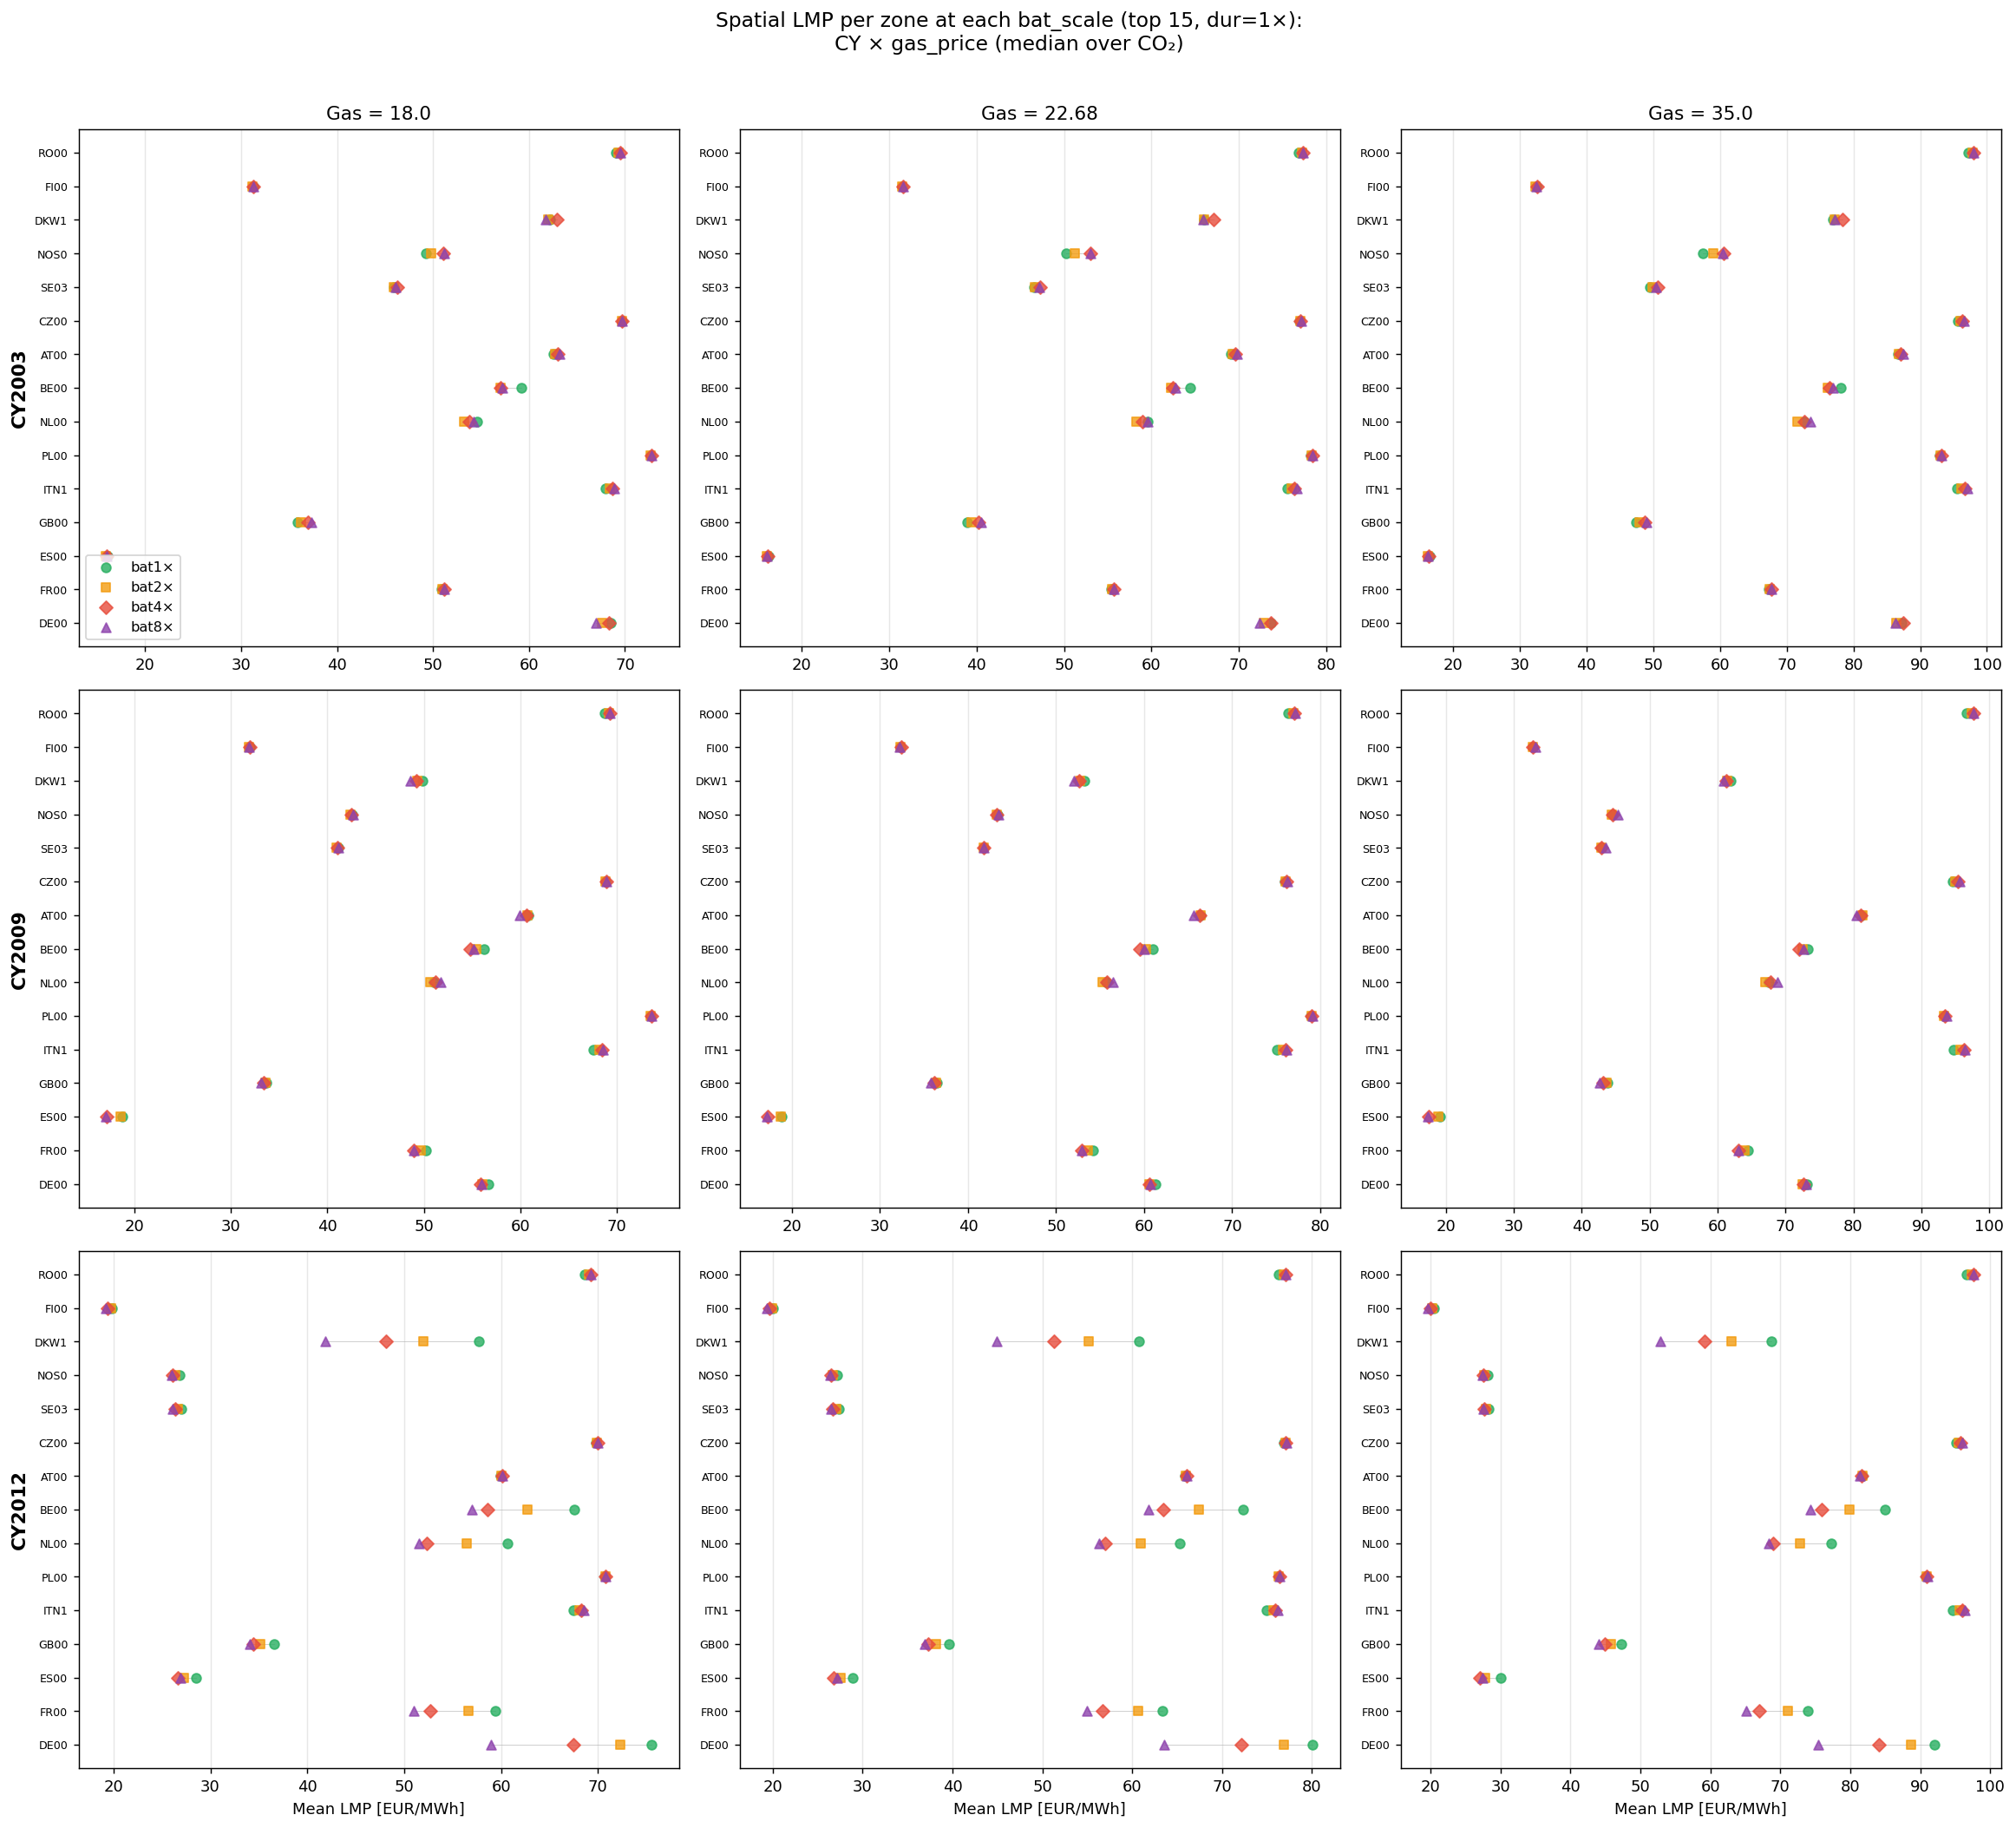

In [16]:
# Spatial analysis — 3×3 grid: CY rows × gas cols
# Each panel: top 10 zones, dots for bat1×/bat2×/bat4×/bat8× absolute LMP
FIX_DUR_S = 1
bus_cols_lmp = [c for c in lmp_raw.columns if c not in ["tag", "timestamp", "month"]]

CYS_SP = sorted(res_vol["climate_year"].unique())
GAS_SP = sorted(res_vol["gas_price"].unique())
ALL_SCALES = [1, 2, 4, 8]
scale_colors_sp = {1: "#27ae60", 2: "#f39c12", 4: "#e74c3c", 8: "#8e44ad"}
scale_markers_sp = {1: "o", 2: "s", 4: "D", 8: "^"}
# Fixed list of major bidding zones (by load/generation size)
MAJOR_ZONES = ["DE00", "FR00", "ES00", "GB00", "ITN1", "PL00", "NL00", "BE00", "AT00", "CZ00",
               "SE03", "NOS0", "DKW1", "FI00", "RO00"]

fig, axes = plt.subplots(3, 3, figsize=(18, 16), sharex=False, sharey=False)

for row, cy in enumerate(CYS_SP):
    for col, gp in enumerate(GAS_SP):
        ax = axes[row, col]
        
        # Compute mean LMP per zone per bat_scale
        lmp_per_scale = {}
        for bs in ALL_SCALES:
            tags = res_vol[
                (res_vol.bat_scale == bs) & (res_vol.bat_duration == FIX_DUR_S) &
                (res_vol.gas_price == gp) & (res_vol.climate_year == cy)
            ]["tag"].tolist()
            lmp_per_scale[bs] = lmp_raw[lmp_raw.tag.isin(tags)].groupby("tag")[bus_cols_lmp].mean().mean(axis=0)
        
        # Sort by bat1× LMP (highest first)
        top_zones = [z for z in MAJOR_ZONES if z in lmp_per_scale[1].index]
        
        for bs in ALL_SCALES:
            vals = lmp_per_scale[bs].loc[top_zones]
            ax.scatter(vals.values, range(len(top_zones)),
                      color=scale_colors_sp[bs], marker=scale_markers_sp[bs],
                      s=35, alpha=0.8, label=f"bat{bs}×" if row == 0 and col == 0 else "",
                      zorder=3)
        
        # Connect dots per zone
        for j, zone in enumerate(top_zones):
            x_vals = [lmp_per_scale[bs].loc[zone] for bs in ALL_SCALES]
            ax.plot(x_vals, [j]*4, color="gray", lw=0.5, alpha=0.4, zorder=1)
        
        ax.set_yticks(range(len(top_zones)))
        ax.set_yticklabels(top_zones, fontsize=7)
        ax.grid(axis="x", alpha=0.3)
        
        if row == 0:
            ax.set_title(f"Gas = {gp}")
        if col == 0:
            ax.set_ylabel(f"CY{cy}", fontsize=12, fontweight="bold")
        if row == 2:
            ax.set_xlabel("Mean LMP [EUR/MWh]")

axes[0, 0].legend(fontsize=9, loc="lower left")
plt.suptitle("Spatial LMP per zone at each bat_scale (top 15, dur=1×):\nCY × gas_price (median over CO₂)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

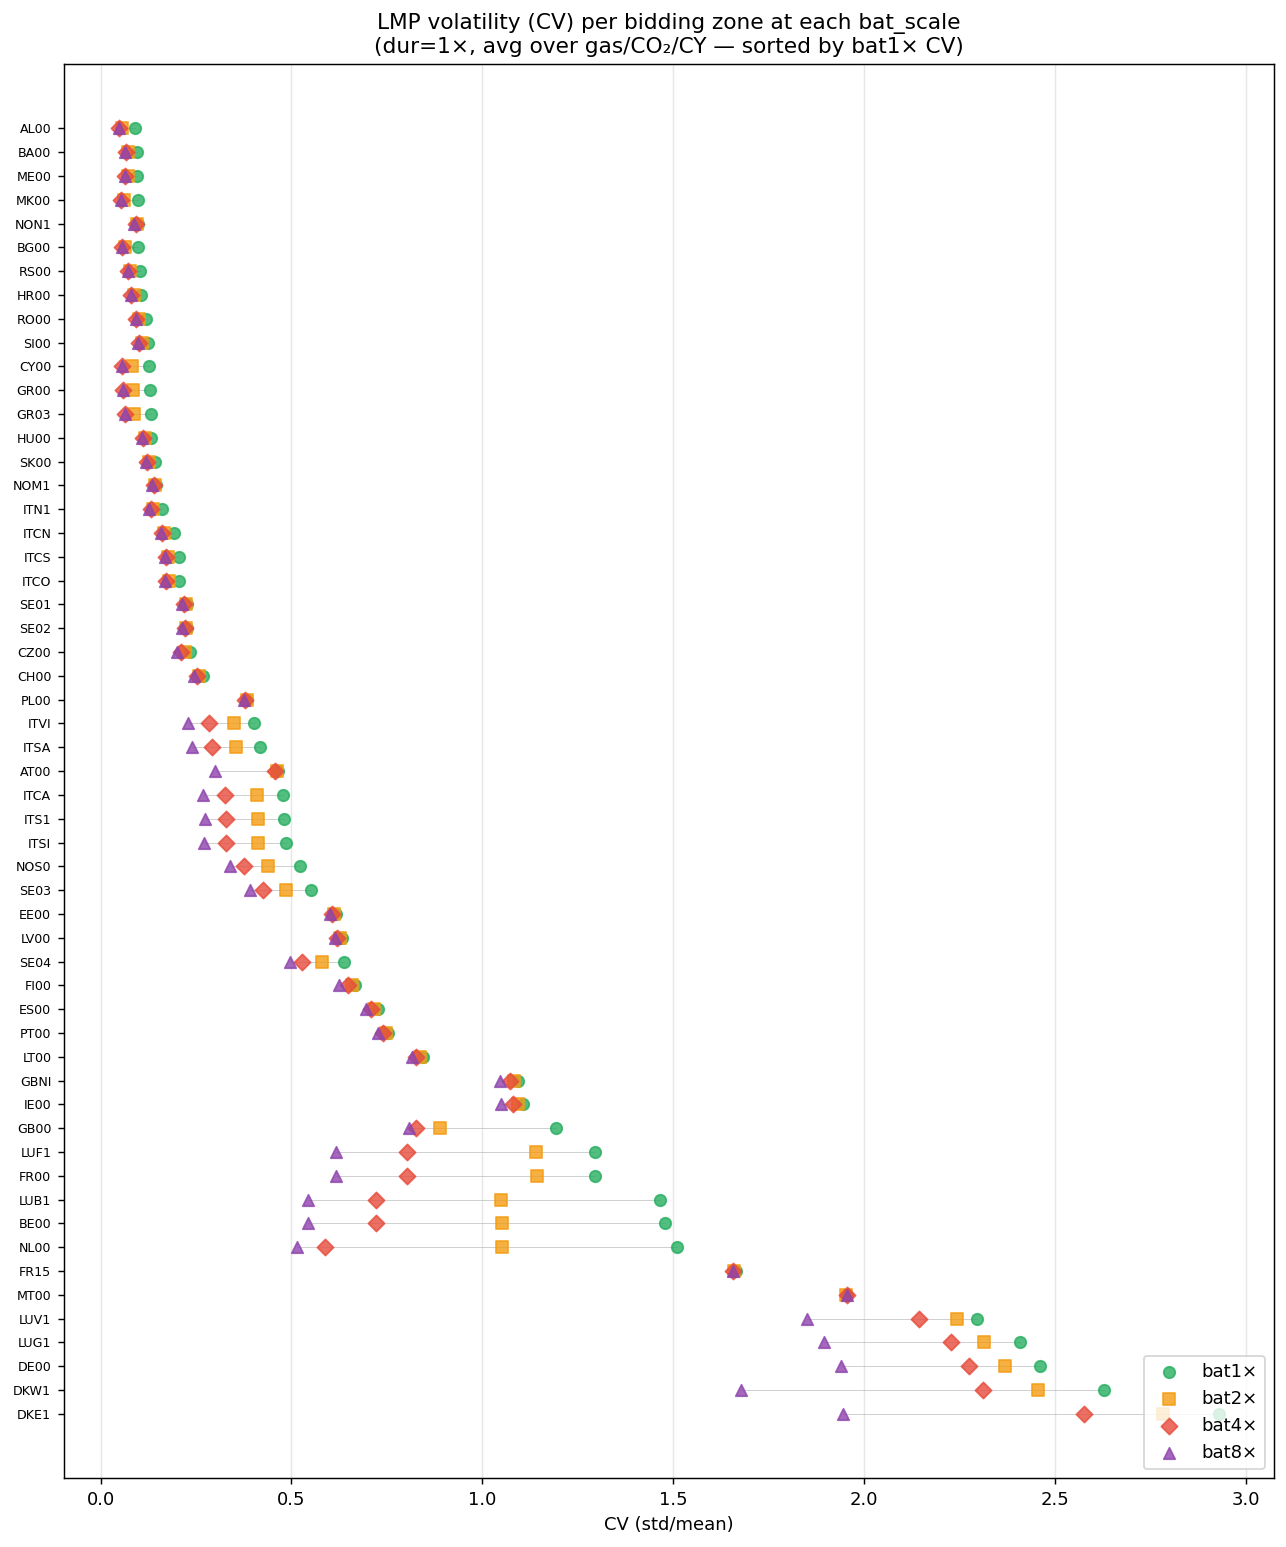


Top 10 most volatile zones (bat1×) and their CV at bat8×:
  DKE1    : bat1×=2.93, bat8×=1.94 (reduction -33.6%)
  DKW1    : bat1×=2.63, bat8×=1.68 (reduction -36.2%)
  DE00    : bat1×=2.46, bat8×=1.94 (reduction -21.1%)
  LUG1    : bat1×=2.41, bat8×=1.89 (reduction -21.3%)
  LUV1    : bat1×=2.30, bat8×=1.85 (reduction -19.4%)
  MT00    : bat1×=1.95, bat8×=1.95 (reduction -0.0%)
  FR15    : bat1×=1.66, bat8×=1.66 (reduction -0.4%)
  NL00    : bat1×=1.51, bat8×=0.52 (reduction -65.9%)
  BE00    : bat1×=1.48, bat8×=0.54 (reduction -63.2%)
  LUB1    : bat1×=1.47, bat8×=0.54 (reduction -62.9%)


In [17]:
# Spatial volatility: absolute CV per bus at each bat_scale level
# dur=1×, averaged over gas/co2/CY

cv_by_scale = {}
for bs in [1, 2, 4, 8]:
    tags_bs = res_vol[
        (res_vol.bat_scale == bs) & (res_vol.bat_duration == FIX_DUR_S)
    ]["tag"].tolist()
    cv_bs = lmp_raw[lmp_raw.tag.isin(tags_bs)].groupby("tag")[bus_cols_lmp].std().mean(axis=0) / \
            lmp_raw[lmp_raw.tag.isin(tags_bs)].groupby("tag")[bus_cols_lmp].mean().mean(axis=0)
    cv_by_scale[bs] = cv_bs

# Sort zones by bat1× CV (most volatile first)
zone_order = cv_by_scale[1].sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 12))

scale_markers = {1: "o", 2: "s", 4: "D", 8: "^"}
scale_colors_cv = {1: "#27ae60", 2: "#f39c12", 4: "#e74c3c", 8: "#8e44ad"}

for bs in [1, 2, 4, 8]:
    vals = cv_by_scale[bs].loc[zone_order]
    ax.scatter(vals.values, range(len(zone_order)),
              color=scale_colors_cv[bs], marker=scale_markers[bs],
              s=40, alpha=0.8, label=f"bat{bs}×", zorder=3)

# Connect dots per zone
for j, zone in enumerate(zone_order):
    x_vals = [cv_by_scale[bs].loc[zone] for bs in [1, 2, 4, 8]]
    ax.plot(x_vals, [j, j, j, j], color="gray", lw=0.5, alpha=0.4, zorder=1)

ax.set_yticks(range(len(zone_order)))
ax.set_yticklabels(zone_order, fontsize=7)
ax.set_xlabel("CV (std/mean)")
ax.set_title("LMP volatility (CV) per bidding zone at each bat_scale\n(dur=1×, avg over gas/CO₂/CY — sorted by bat1× CV)")
ax.legend(fontsize=10, loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 10 most volatile zones (bat1×) and their CV at bat8×:")
for zone in zone_order[:10]:
    cv1 = cv_by_scale[1].loc[zone]
    cv8 = cv_by_scale[8].loc[zone]
    print(f"  {zone:8s}: bat1×={cv1:.2f}, bat8×={cv8:.2f} (reduction {(cv8-cv1)/cv1*100:+.1f}%)")

In [18]:
# Export for thesis
fig.savefig("../tukedip_pdflatex_utf-8/figures/fig_spatial_cv.jpg", dpi=200, bbox_inches="tight")
print("Saved fig_spatial_cv.jpg")

Saved fig_spatial_cv.jpg


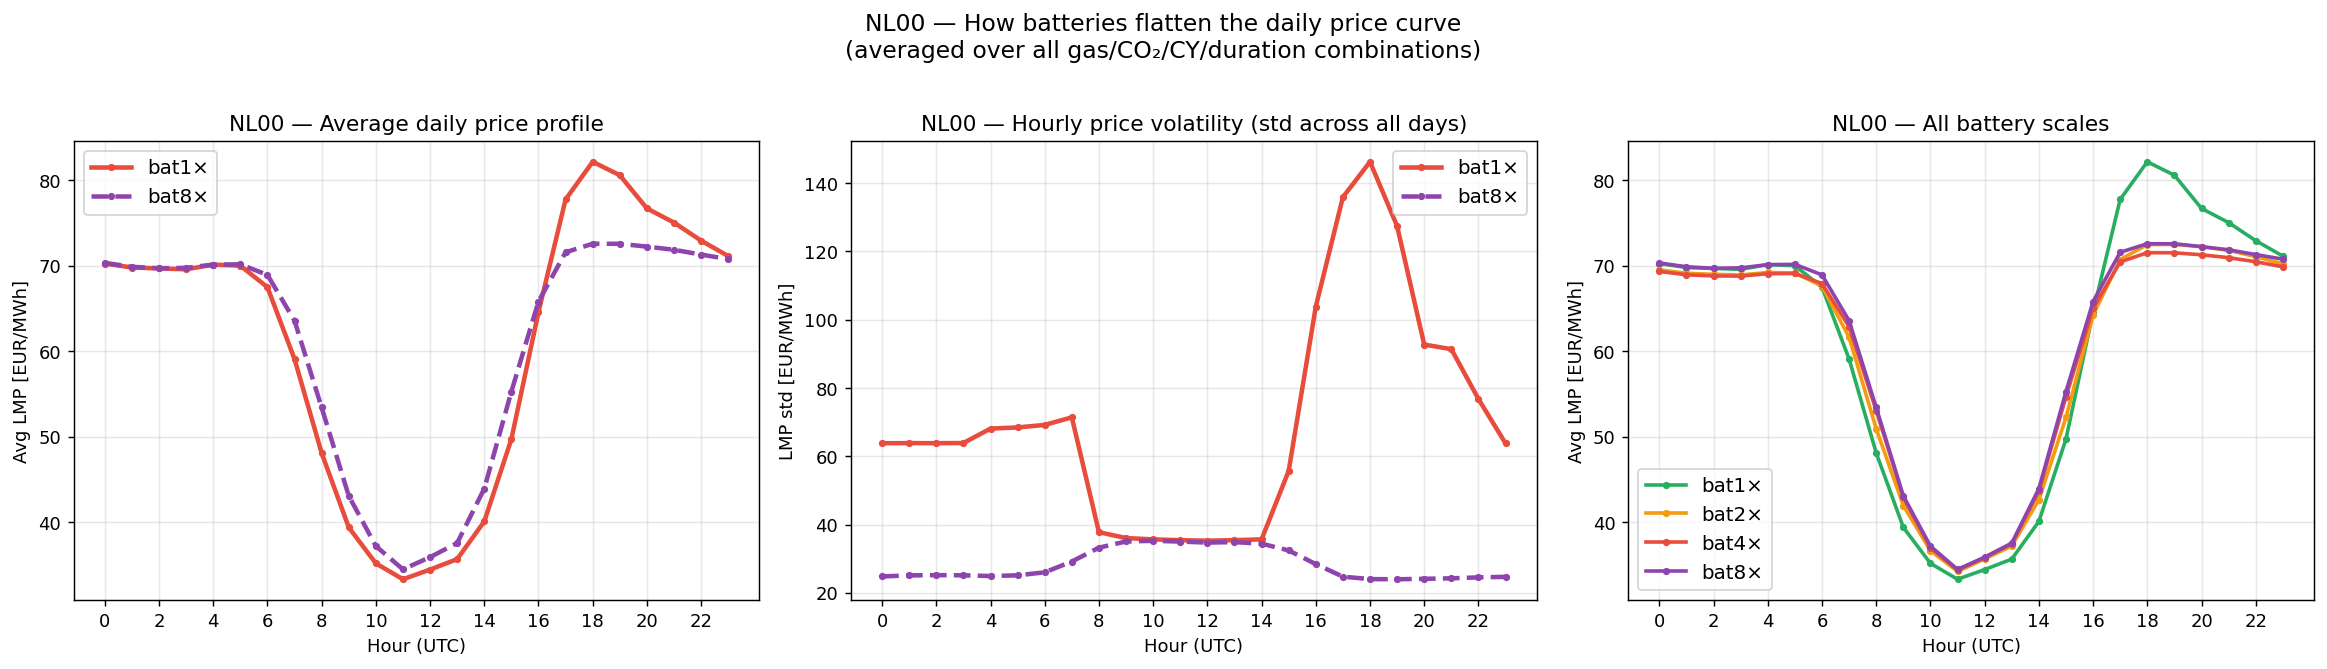

bat1×: peak=82.2, valley=33.4, spread=48.8 EUR/MWh
bat8×: peak=72.6, valley=34.5, spread=38.1 EUR/MWh


In [19]:
# Daily price profile: NL00 bat1× vs bat8× (averaged over all scenarios)
BUS_NL = "NL00"

lmp_nl = lmp_raw[["tag", "timestamp", BUS_NL]].copy()
lmp_nl["hour"] = lmp_nl["timestamp"].dt.hour
lmp_nl = lmp_nl.merge(res_vol[["tag", "bat_scale", "bat_duration"]], on="tag")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: bat1× vs bat8× average profile
ax = axes[0]
for bs, color, ls in [(1, "#e74c3c", "-"), (8, "#8e44ad", "--")]:
    hourly = lmp_nl[lmp_nl.bat_scale == bs].groupby("hour")[BUS_NL].mean()
    ax.plot(hourly.index, hourly.values, color=color, lw=2.5, ls=ls, marker="o", markersize=3,
            label=f"bat{bs}×")
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("Avg LMP [EUR/MWh]")
ax.set_title(f"{BUS_NL} — Average daily price profile")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_xticks(range(0, 24, 2))

# Panel 2: hourly std (volatility across days)
ax = axes[1]
for bs, color, ls in [(1, "#e74c3c", "-"), (8, "#8e44ad", "--")]:
    hourly_std = lmp_nl[lmp_nl.bat_scale == bs].groupby("hour")[BUS_NL].std()
    ax.plot(hourly_std.index, hourly_std.values, color=color, lw=2.5, ls=ls, marker="o", markersize=3,
            label=f"bat{bs}×")
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("LMP std [EUR/MWh]")
ax.set_title(f"{BUS_NL} — Hourly price volatility (std across all days)")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_xticks(range(0, 24, 2))

# Panel 3: all 4 scales
ax = axes[2]
for bs, color in scale_colors.items():
    hourly = lmp_nl[lmp_nl.bat_scale == bs].groupby("hour")[BUS_NL].mean()
    ax.plot(hourly.index, hourly.values, color=color, lw=2, marker="o", markersize=3,
            label=f"bat{bs}×")
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("Avg LMP [EUR/MWh]")
ax.set_title(f"{BUS_NL} — All battery scales")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_xticks(range(0, 24, 2))

plt.suptitle(f"{BUS_NL} — How batteries flatten the daily price curve\n(averaged over all gas/CO₂/CY/duration combinations)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# Print stats
for bs in [1, 8]:
    hourly = lmp_nl[lmp_nl.bat_scale == bs].groupby("hour")[BUS_NL].mean()
    print(f"bat{bs}×: peak={hourly.max():.1f}, valley={hourly.min():.1f}, spread={hourly.max()-hourly.min():.1f} EUR/MWh")

## Section 10 — Diminishing Returns: Battery Value Saturation (DE00)

As battery capacity scales up, marginal price reduction per additional GW decreases.
The 3×3 grid below shows marginal LMP reduction for each scale step (1→2×, 2→4×, 4→8×)
across all CY × gas_price combinations, averaged over CO₂ and bat_duration.

Key findings:
- First doubling (1→2×) consistently reduces LMP
- Later steps (2→4×, 4→8×) can have near-zero or even negative marginal effect — batteries may slightly increase average LMP by raising demand during charging hours while reducing peak prices
- Effect varies significantly across climate years and gas prices

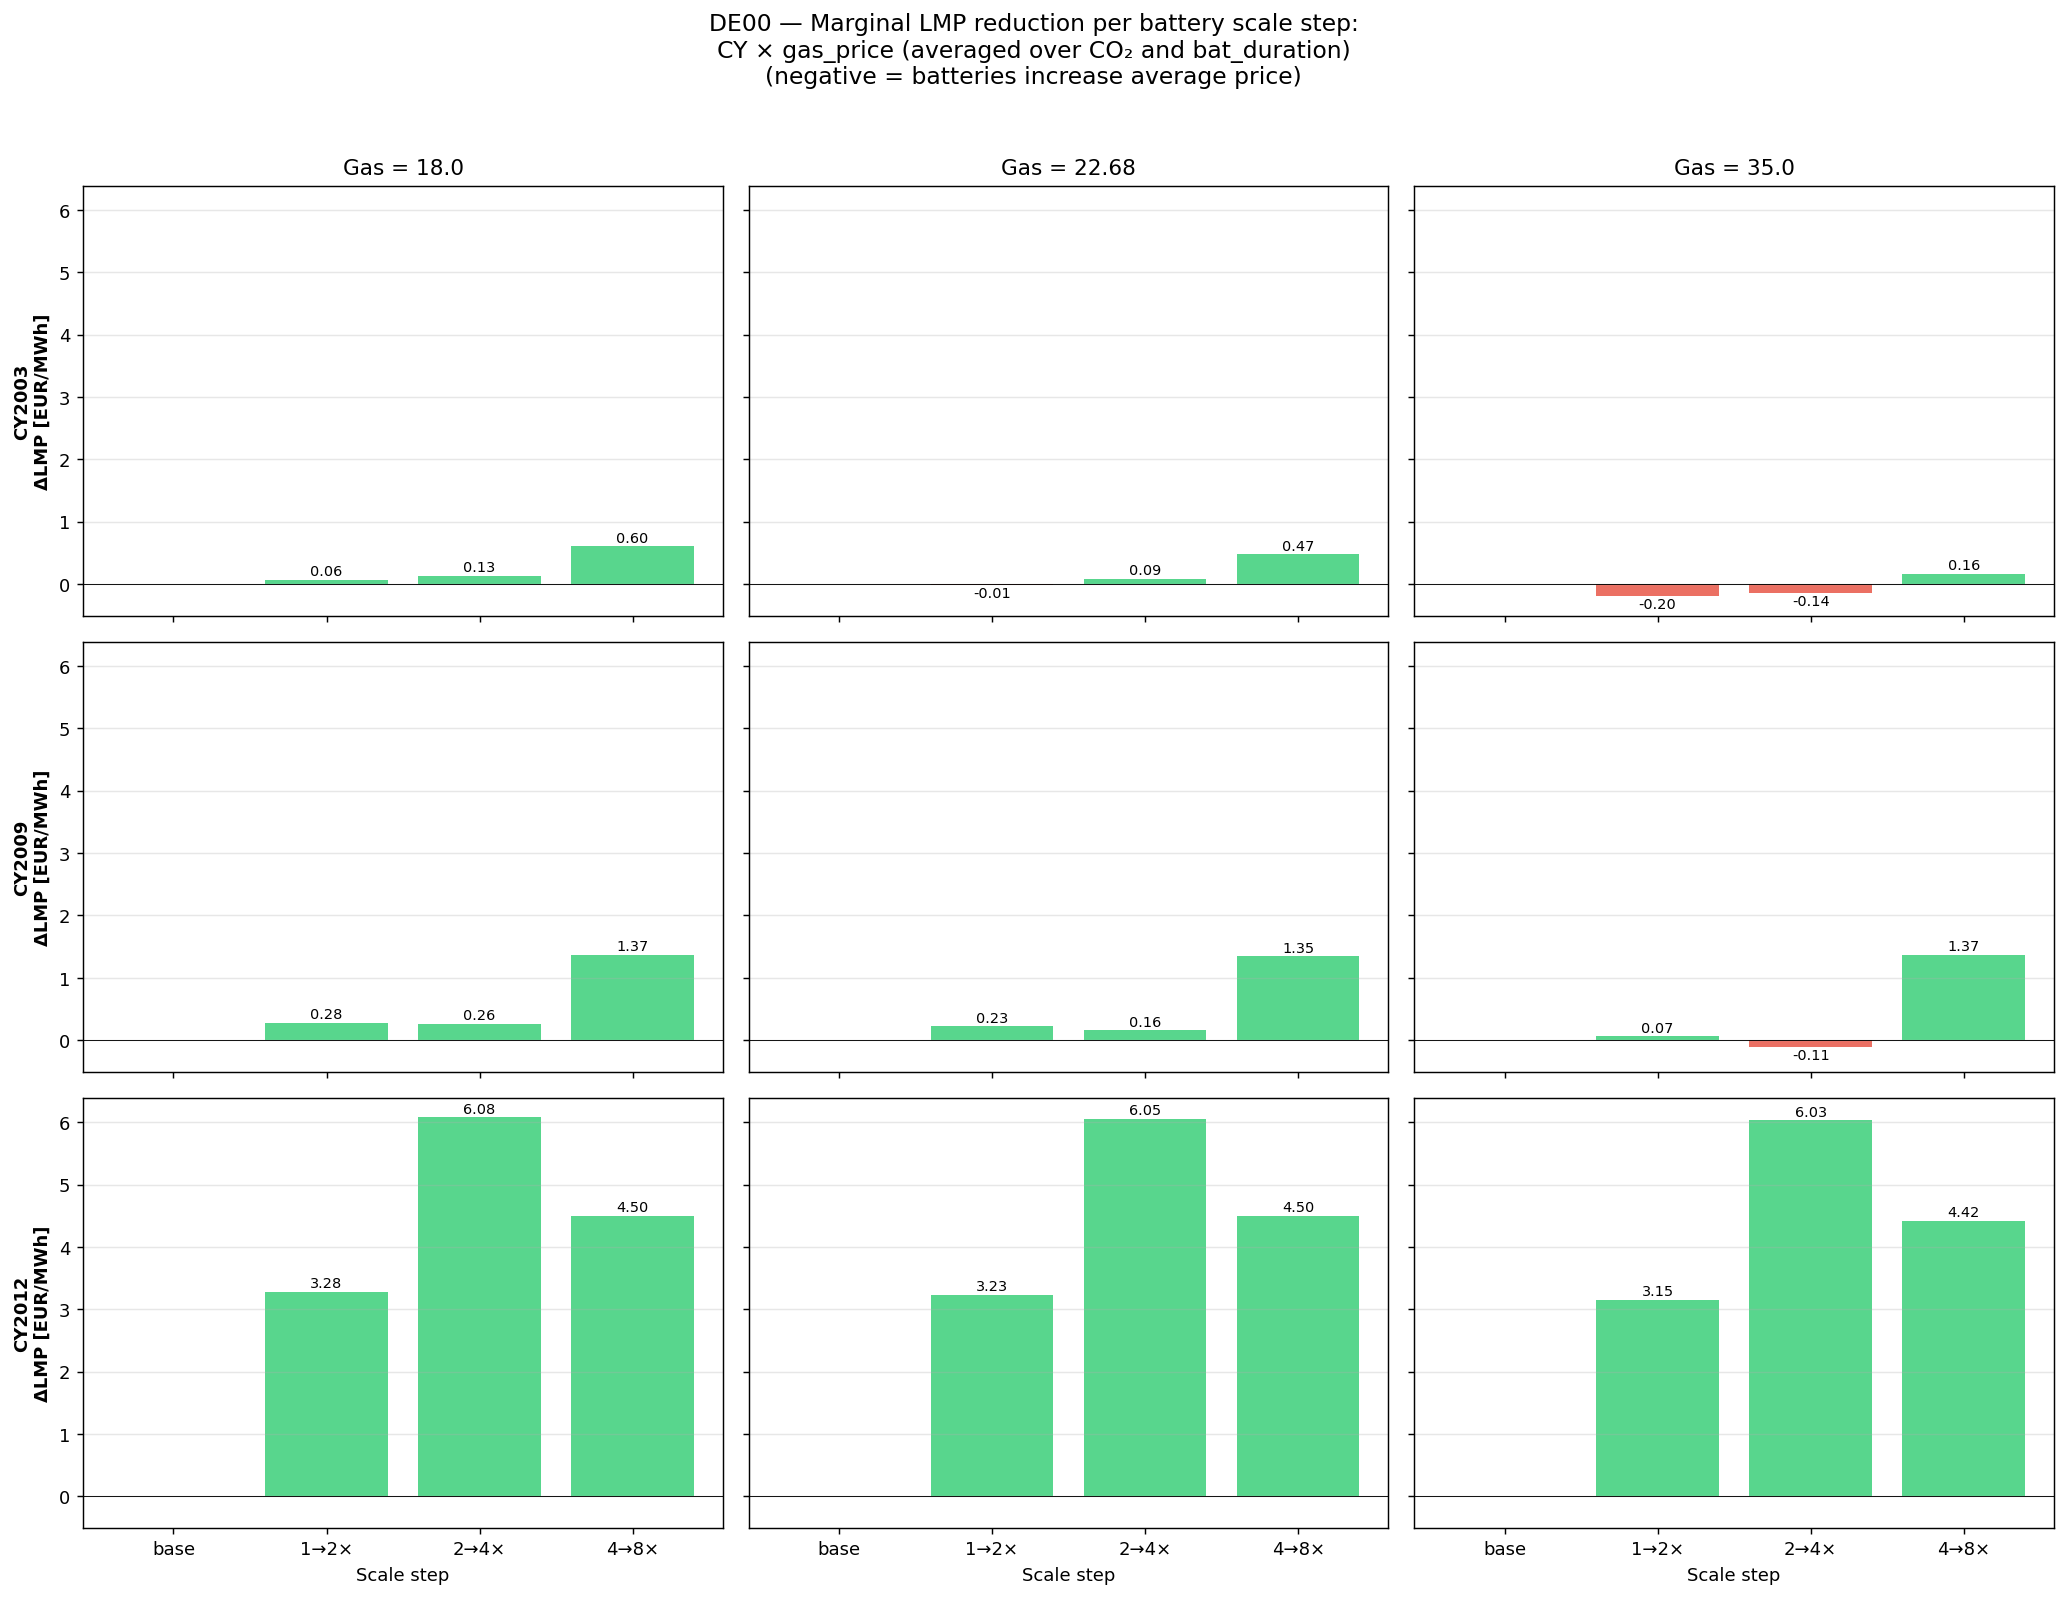

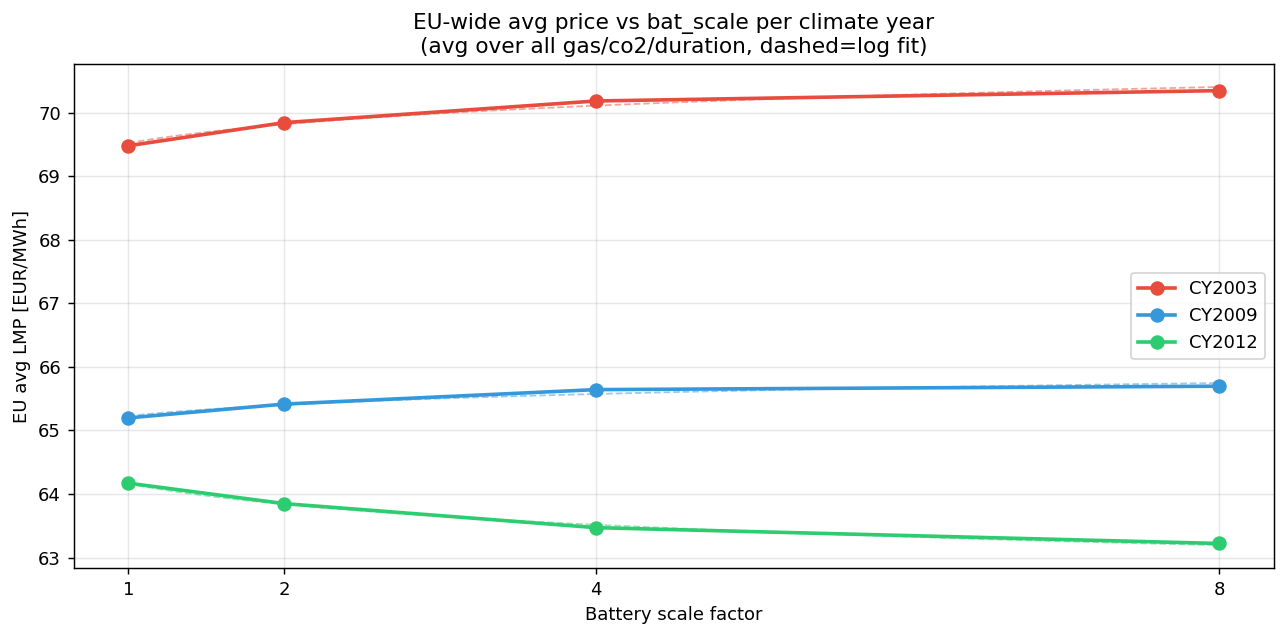

In [20]:
from scipy.optimize import curve_fit

scales = [1, 2, 4, 8]
gas_colors = {18: "#2ecc71", 22.68: "#f39c12", 35: "#e74c3c"}

def log_curve(x, a, b):
    return a - b * np.log(x)

# --- Marginal LMP reduction — 3×3 grid: CY rows × gas cols ---
CYS_D = sorted(res_vol["climate_year"].unique())
GAS_D = sorted(res_vol["gas_price"].unique())

fig, axes = plt.subplots(3, 3, figsize=(16, 12), sharex=True, sharey=True)

for row, cy in enumerate(CYS_D):
    for col, gp in enumerate(GAS_D):
        ax = axes[row, col]
        
        # Mean LMP per bat_scale (avg over co2 and duration)
        means = []
        for s in scales:
            val = res_vol[(res_vol.bat_scale == s) & (res_vol.gas_price == gp) &
                          (res_vol.climate_year == cy)]["lmp_annual"].mean()
            means.append(val)
        
        # Marginal reduction per step
        steps = ["base", "1→2×", "2→4×", "4→8×"]
        marginal = [0] + [means[i-1] - means[i] for i in range(1, len(means))]
        
        colors = ["#2ecc71" if m >= 0 else "#e74c3c" for m in marginal]
        ax.bar(steps, marginal, color=colors, alpha=0.8)
        ax.axhline(0, color="black", lw=0.5)
        ax.grid(axis="y", alpha=0.3)
        
        # Annotate values
        for j, m in enumerate(marginal):
            if j > 0:
                ax.text(j, m + 0.02 * (1 if m >= 0 else -1), f"{m:.2f}",
                        ha="center", va="bottom" if m >= 0 else "top", fontsize=8)
        
        if row == 0:
            ax.set_title(f"Gas = {gp}")
        if col == 0:
            ax.set_ylabel(f"CY{cy}\nΔLMP [EUR/MWh]", fontsize=10, fontweight="bold")
        if row == 2:
            ax.set_xlabel("Scale step")

plt.suptitle("DE00 — Marginal LMP reduction per battery scale step:\nCY × gas_price (averaged over CO₂ and bat_duration)\n(negative = batteries increase average price)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# --- EU-wide avg LMP vs bat_scale per climate year ---
fig, ax = plt.subplots(figsize=(10, 5))
eu_buses = [c for c in lmp_raw.columns if c not in ["tag", "timestamp", "month"]]
lmp_eu_per_tag = lmp_raw.groupby("tag")[eu_buses].mean().mean(axis=1).rename("lmp_eu")
res_eu = res_vol.set_index("tag").join(lmp_eu_per_tag).reset_index()

for cy, cy_color in [(2003, "#e74c3c"), (2009, "#3498db"), (2012, "#2ecc71")]:
    vals = [res_eu[(res_eu.bat_scale == s) & (res_eu.climate_year == cy)]["lmp_eu"].mean()
            for s in scales]
    ax.plot(scales, vals, "o-", color=cy_color, linewidth=2, markersize=7, label=f"CY{cy}")
    try:
        popt, _ = curve_fit(log_curve, scales, vals)
        x_fine = np.linspace(1, 8, 100)
        ax.plot(x_fine, log_curve(x_fine, *popt), "--", color=cy_color, alpha=0.5, linewidth=1)
    except Exception:
        pass

ax.set_xlabel("Battery scale factor")
ax.set_ylabel("EU avg LMP [EUR/MWh]")
ax.set_title("EU-wide avg price vs bat_scale per climate year\n(avg over all gas/co2/duration, dashed=log fit)")
ax.set_xticks(scales)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# Export for thesis
fig.savefig("../tukedip_pdflatex_utf-8/figures/fig_diminishing_returns.jpg", dpi=200, bbox_inches="tight")
print("Saved fig_diminishing_returns.jpg")

Saved fig_diminishing_returns.jpg


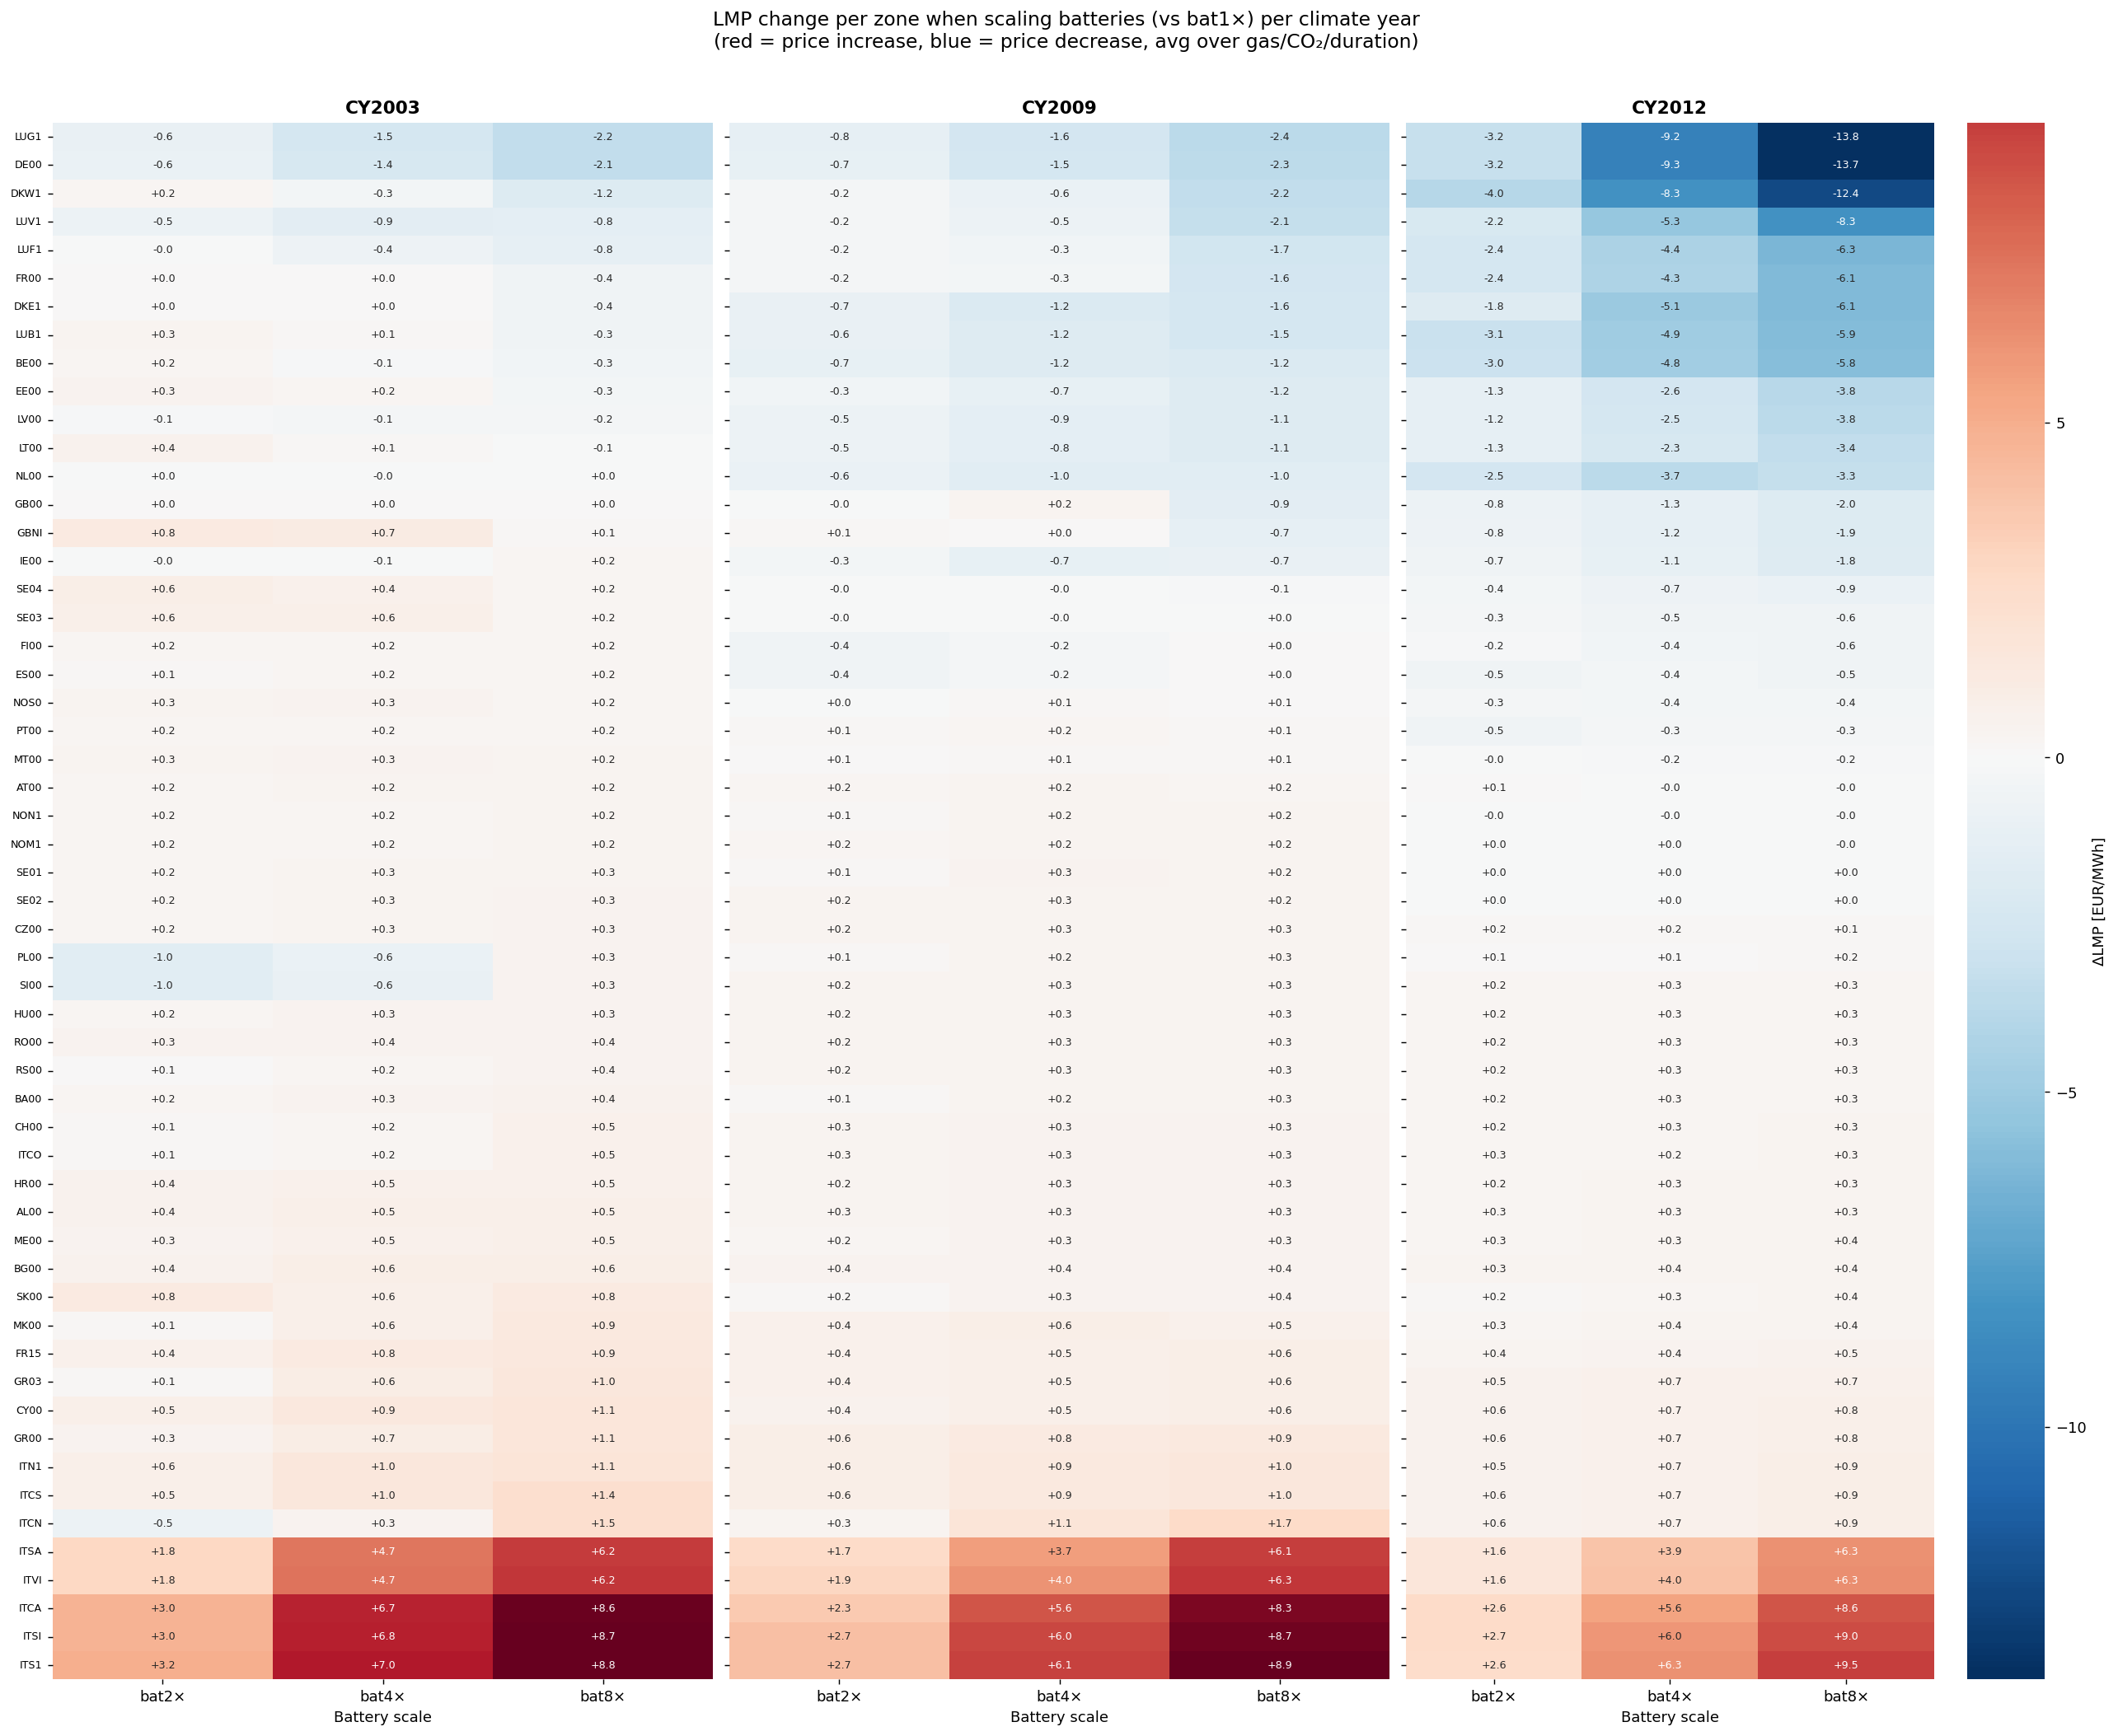

In [22]:
# Per-country LMP change — 3 heatmaps (one per CY), all zones × bat_scale
ALL_ZONES = [c for c in lmp_raw.columns if c not in ["tag", "timestamp", "month"]]

scales = [1, 2, 4, 8]
CYS_Z = sorted(res_vol["climate_year"].unique())

fig, axes = plt.subplots(1, 3, figsize=(20, 16), sharey=True)

for col, cy in enumerate(CYS_Z):
    ax = axes[col]
    
    # LMP at bat1× for this CY
    tags_1x = res_vol[(res_vol.bat_scale == 1) & (res_vol.climate_year == cy)]["tag"].tolist()
    lmp_1x = lmp_raw[lmp_raw.tag.isin(tags_1x)][ALL_ZONES].mean()
    
    # Delta for bat2×, bat4×, bat8×
    delta_rows = {}
    for bs in [2, 4, 8]:
        tags_bs = res_vol[(res_vol.bat_scale == bs) & (res_vol.climate_year == cy)]["tag"].tolist()
        lmp_bs = lmp_raw[lmp_raw.tag.isin(tags_bs)][ALL_ZONES].mean()
        delta_rows[f"bat{bs}×"] = lmp_bs - lmp_1x
    
    delta_df = pd.DataFrame(delta_rows)
    # Sort by bat8× delta
    delta_df = delta_df.loc[delta_df["bat8×"].sort_values().index]
    
    sns.heatmap(delta_df, annot=True, fmt="+.1f", cmap="RdBu_r", center=0, ax=ax,
                cbar=col == 2, cbar_kws={"label": "ΔLMP [EUR/MWh]"} if col == 2 else {},
                annot_kws={"fontsize": 7})
    ax.set_title(f"CY{cy}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Battery scale")
    if col == 0:
        ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=7)

plt.suptitle("LMP change per zone when scaling batteries (vs bat1×) per climate year\n"
             "(red = price increase, blue = price decrease, avg over gas/CO₂/duration)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## Section 11 — Interaction: bat_scale × gas_price × co2_price (DE00)

Key question: *Is battery value (volatility reduction) larger when gas prices are high?*

Each cell = mean CV averaged over all climate years and battery durations.
If rows are not parallel → interaction exists (battery effect depends on gas/CO2 price).


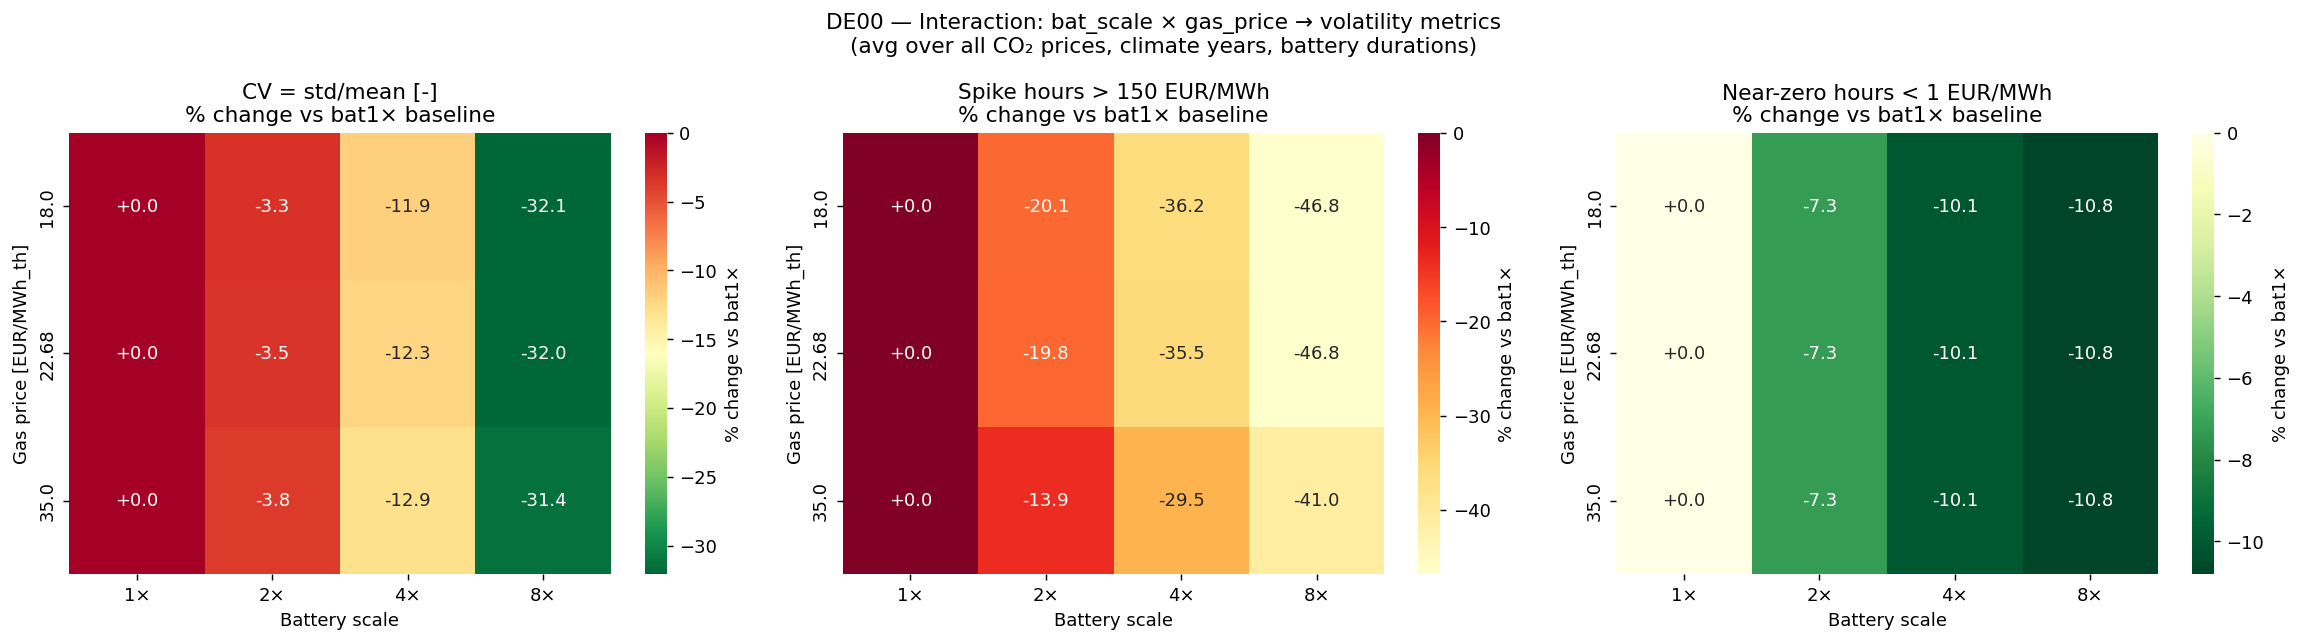

In [23]:
import matplotlib.gridspec as gridspec

scales    = [1, 2, 4, 8]
gas_prices  = sorted(res_vol.gas_price.unique())
co2_prices  = sorted(res_vol.co2_price.unique())
cy_list     = sorted(res_vol.climate_year.unique())

# ── 1. bat_scale × gas_price heatmap (averaged over co2, cy, dur) ──────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_interact = [
    ("lmp_cv",      "CV = std/mean [-]",        "RdYlGn_r"),
    ("spike_hours", "Spike hours > 150 EUR/MWh", "YlOrRd"),
    ("zero_hours",  "Near-zero hours < 1 EUR/MWh","YlGn_r"),
]

for ax, (metric, label, cmap) in zip(axes, metrics_interact):
    matrix = np.zeros((len(gas_prices), len(scales)))
    for i, gp in enumerate(gas_prices):
        for j, s in enumerate(scales):
            val = res_vol[(res_vol.gas_price == gp) & (res_vol.bat_scale == s)][metric].mean()
            matrix[i, j] = val

    # Reduction relative to bat_scale=1
    base_col = matrix[:, 0:1]
    matrix_pct = (matrix - base_col) / base_col * 100  # % change vs bat1x

    hm_df = pd.DataFrame(matrix_pct,
                          index=[f"{gp}" for gp in gas_prices],
                          columns=[f"{s}×" for s in scales])
    sns.heatmap(hm_df, annot=True, fmt="+.1f", cmap=cmap, ax=ax,
                cbar_kws={"label": "% change vs bat1×"})
    ax.set_xlabel("Battery scale")
    ax.set_ylabel("Gas price [EUR/MWh_th]")
    ax.set_title(f"{label}\n% change vs bat1× baseline")

fig.suptitle("DE00 — Interaction: bat_scale × gas_price → volatility metrics\n"
             "(avg over all CO₂ prices, climate years, battery durations)", fontsize=12)
plt.tight_layout()
plt.show()

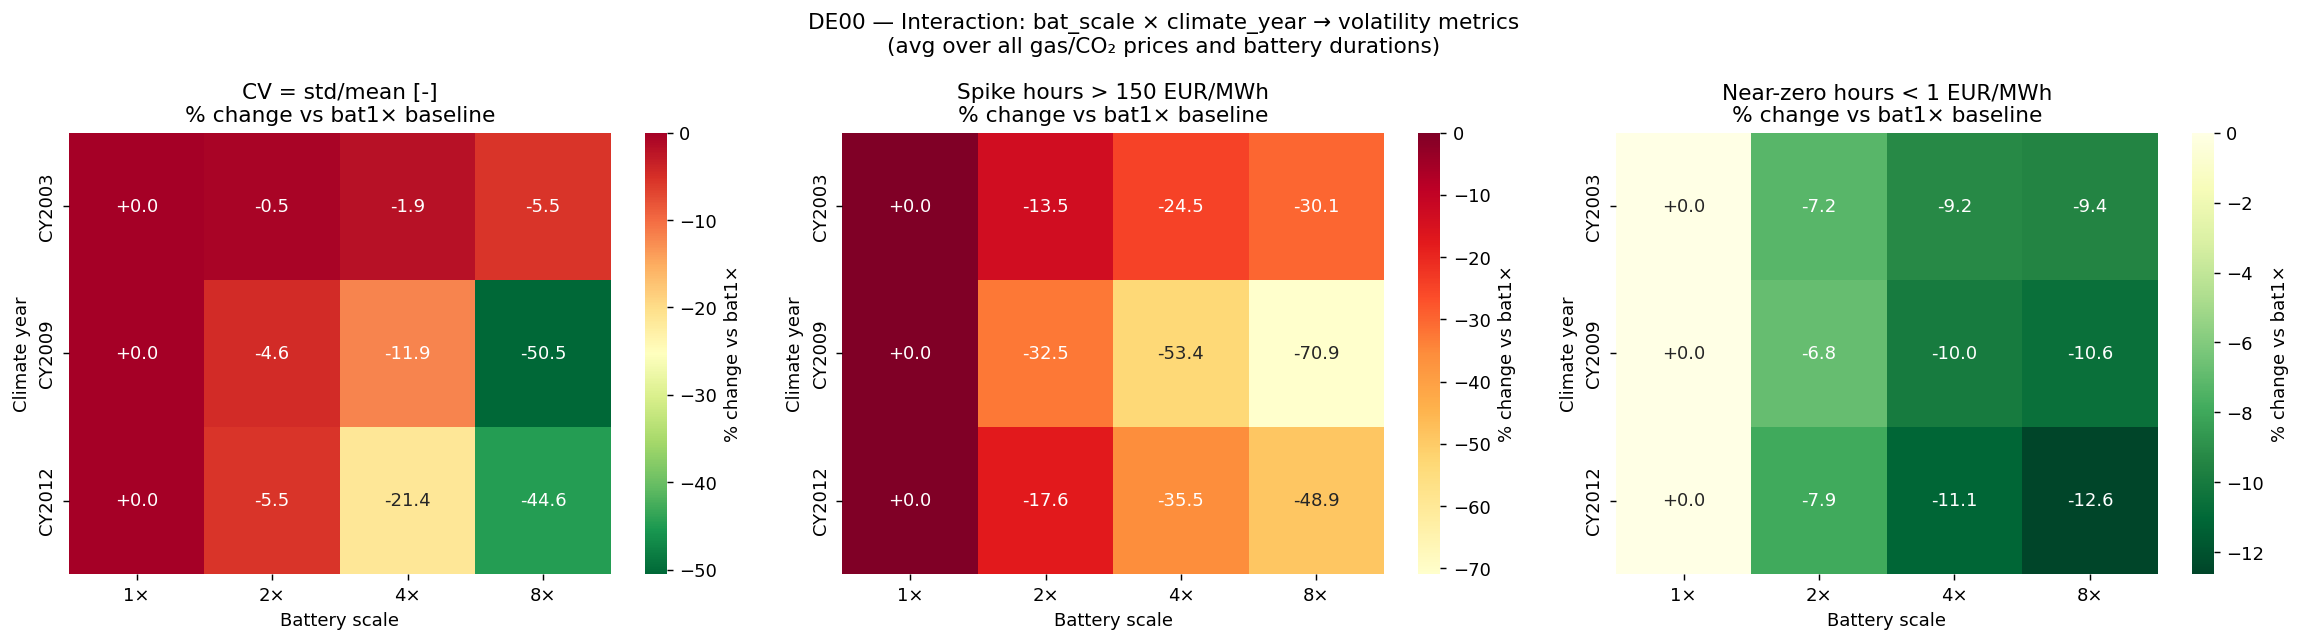


Interaction magnitude (CV, bat8× vs bat1×):
  gas=18:    1.735  vs bat1×: 2.555
  gas=35:    1.403  vs bat1×: 2.045
  CY2003:    2.372  vs bat1×: 2.510
  CY2012:    1.644  vs bat1×: 2.968


In [24]:
# ── 2. bat_scale × climate_year interaction ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (metric, label, cmap) in zip(axes, metrics_interact):
    matrix = np.zeros((len(cy_list), len(scales)))
    for i, cy in enumerate(cy_list):
        for j, s in enumerate(scales):
            val = res_vol[(res_vol.climate_year == cy) & (res_vol.bat_scale == s)][metric].mean()
            matrix[i, j] = val

    base_col = matrix[:, 0:1]
    matrix_pct = (matrix - base_col) / base_col * 100

    hm_df = pd.DataFrame(matrix_pct,
                          index=[f"CY{cy}" for cy in cy_list],
                          columns=[f"{s}×" for s in scales])
    sns.heatmap(hm_df, annot=True, fmt="+.1f", cmap=cmap, ax=ax,
                cbar_kws={"label": "% change vs bat1×"})
    ax.set_xlabel("Battery scale")
    ax.set_ylabel("Climate year")
    ax.set_title(f"{label}\n% change vs bat1× baseline")

fig.suptitle("DE00 — Interaction: bat_scale × climate_year → volatility metrics\n"
             "(avg over all gas/CO₂ prices and battery durations)", fontsize=12)
plt.tight_layout()
plt.show()

# Print summary of interaction magnitude
print("\nInteraction magnitude (CV, bat8× vs bat1×):")
print(f"  gas=18:    {res_vol[(res_vol.gas_price==18)   & (res_vol.bat_scale==8)]['lmp_cv'].mean():.3f}  "
      f"vs bat1×: {res_vol[(res_vol.gas_price==18)   & (res_vol.bat_scale==1)]['lmp_cv'].mean():.3f}")
print(f"  gas=35:    {res_vol[(res_vol.gas_price==35)   & (res_vol.bat_scale==8)]['lmp_cv'].mean():.3f}  "
      f"vs bat1×: {res_vol[(res_vol.gas_price==35)   & (res_vol.bat_scale==1)]['lmp_cv'].mean():.3f}")
print(f"  CY2003:    {res_vol[(res_vol.climate_year==2003) & (res_vol.bat_scale==8)]['lmp_cv'].mean():.3f}  "
      f"vs bat1×: {res_vol[(res_vol.climate_year==2003) & (res_vol.bat_scale==1)]['lmp_cv'].mean():.3f}")
print(f"  CY2012:    {res_vol[(res_vol.climate_year==2012) & (res_vol.bat_scale==8)]['lmp_cv'].mean():.3f}  "
      f"vs bat1×: {res_vol[(res_vol.climate_year==2012) & (res_vol.bat_scale==1)]['lmp_cv'].mean():.3f}")

## Section 12 — Correlation Matrix & OLS Regression (DE00)

**Correlation matrix:** Pearson r between the 5 input parameters and 4 volatility metrics.
Each cell shows how strongly a parameter correlates with a volatility metric across all 432 scenarios.

**Reading the matrix:**
- Negative r (blue) = parameter increase → metric decrease (e.g. bat_scale reduces CV)
- Positive r (red) = parameter increase → metric increase (e.g. co2_price increases spike hours)
- Stars indicate statistical significance: *** p<0.001 (99.9% certain it's not random), ** p<0.01, * p<0.05, no stars = could be random noise

**OLS regression:** Standardized coefficients (beta) showing relative importance of each parameter.

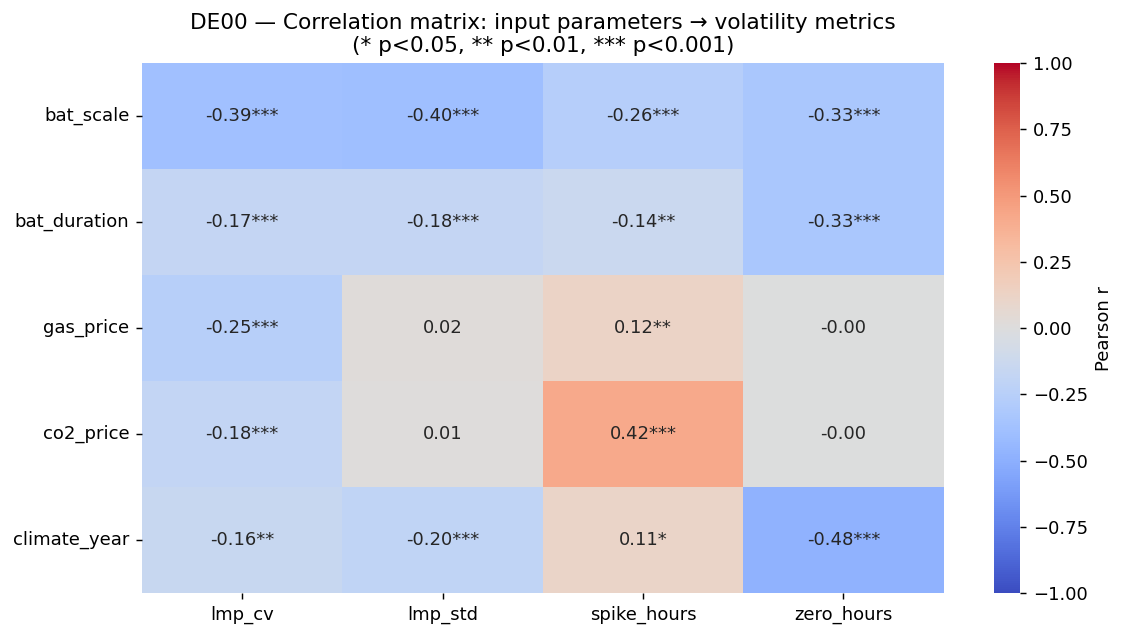


Correlation matrix (Pearson r):
              lmp_cv  lmp_std  spike_hours  zero_hours
bat_scale     -0.388   -0.396       -0.261      -0.332
bat_duration  -0.174   -0.177       -0.140      -0.330
gas_price     -0.254    0.018        0.125      -0.000
co2_price     -0.182    0.013        0.417      -0.000
climate_year  -0.156   -0.200        0.110      -0.479


In [25]:
from scipy import stats as sp_stats

params_list  = ["bat_scale", "bat_duration", "gas_price", "co2_price", "climate_year"]
metrics_list = ["lmp_cv", "lmp_std", "spike_hours", "zero_hours"]

# ── Pearson correlation matrix ───────────────────────────────────────────────
corr_data = res_vol[params_list + metrics_list].copy()
corr_matrix = corr_data.corr().loc[params_list, metrics_list]

# p-values
pval_matrix = pd.DataFrame(index=params_list, columns=metrics_list, dtype=float)
for p in params_list:
    for m in metrics_list:
        r, pv = sp_stats.pearsonr(corr_data[p], corr_data[m])
        pval_matrix.loc[p, m] = pv

# Annotation with stars
annot = corr_matrix.copy().astype(str)
for p in params_list:
    for m in metrics_list:
        r_val = float(corr_matrix.loc[p, m])
        pv = float(pval_matrix.loc[p, m])
        stars = "***" if pv < 0.001 else "**" if pv < 0.01 else "*" if pv < 0.05 else ""
        annot.loc[p, m] = f"{r_val:.2f}{stars}"

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(corr_matrix.astype(float), annot=annot, fmt="", cmap="coolwarm",
            vmin=-1, vmax=1, center=0, ax=ax,
            cbar_kws={"label": "Pearson r"})
ax.set_title("DE00 — Correlation matrix: input parameters → volatility metrics\n"
             "(* p<0.05, ** p<0.01, *** p<0.001)")
plt.tight_layout()
plt.show()

print("\nCorrelation matrix (Pearson r):")
print(corr_matrix.round(3).to_string())

### OLS Regression — Standardized Coefficients

**What is OLS regression?** It finds the best linear equation that predicts a volatility metric from the 5 scenario parameters. For example: `CV ≈ a + b₁×bat_scale + b₂×gas_price + ...`

**Standardized β** coefficients are unitless — they show how many standard deviations the metric changes when the parameter changes by one standard deviation. This makes them comparable across parameters with different scales (bat_scale 1–8 vs gas_price 18–35).

**R²** = how much of the variability the equation explains:
- R² = 1.0 → perfect prediction
- R² = 0.30 → explains 30%, remaining 70% comes from non-linear effects and interactions
- Low R² here is expected and is itself a finding — it motivates the SHAP/LightGBM analysis in Section 16 which captures non-linearities (R² = 0.76)

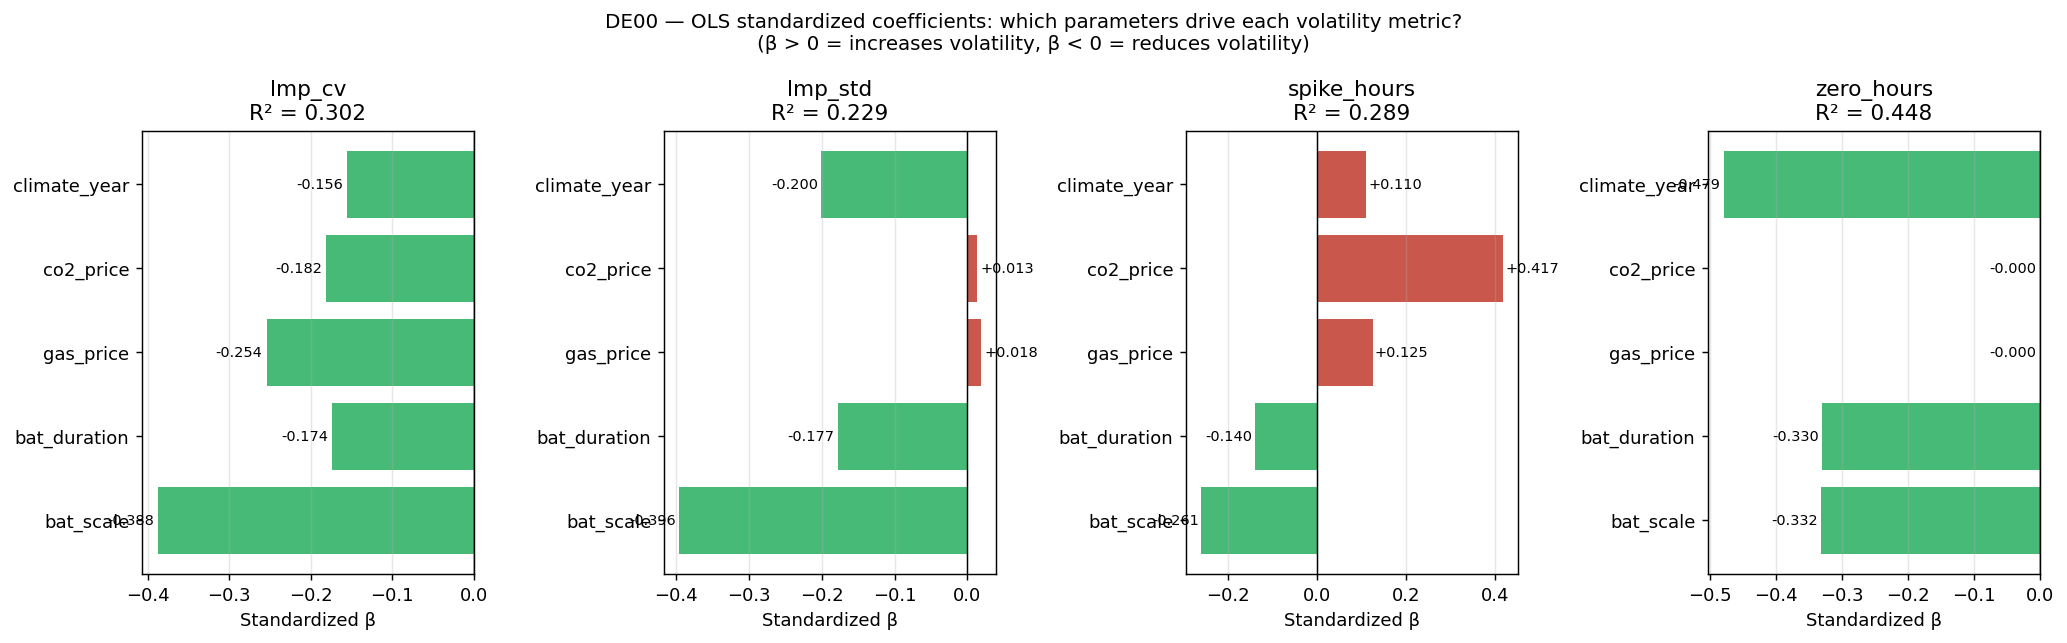


Standardized coefficients (β) — top drivers per metric:

lmp_cv (R²=0.302):
  bat_scale        β = -0.3876
  gas_price        β = -0.2543
  co2_price        β = -0.1815
  bat_duration     β = -0.1738
  climate_year     β = -0.1557

lmp_std (R²=0.229):
  bat_scale        β = -0.3957
  climate_year     β = -0.2004
  bat_duration     β = -0.1774
  gas_price        β = +0.0182
  co2_price        β = +0.0128

spike_hours (R²=0.289):
  co2_price        β = +0.4170
  bat_scale        β = -0.2605
  bat_duration     β = -0.1399
  gas_price        β = +0.1250
  climate_year     β = +0.1100

zero_hours (R²=0.448):
  climate_year     β = -0.4788
  bat_scale        β = -0.3317
  bat_duration     β = -0.3297
  gas_price        β = -0.0000
  co2_price        β = -0.0000


In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# ── OLS with standardized coefficients ──────────────────────────────────────
X_raw = res_vol[params_list].values.astype(float)
scaler_X = StandardScaler()
X_std = scaler_X.fit_transform(X_raw)

fig, axes = plt.subplots(1, len(metrics_list), figsize=(16, 5))

elasticity_rows = []
for ax, metric in zip(axes, metrics_list):
    y = res_vol[metric].values.astype(float)
    scaler_y = StandardScaler()
    y_std = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

    reg = LinearRegression().fit(X_std, y_std)
    betas = reg.coef_
    r2 = reg.score(X_std, y_std)

    colors_beta = ["#c0392b" if b > 0 else "#27ae60" for b in betas]
    ax.barh(params_list, betas, color=colors_beta, alpha=0.85)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Standardized β")
    ax.set_title(f"{metric}\nR² = {r2:.3f}")
    ax.grid(axis="x", alpha=0.3)
    for i, (b, p) in enumerate(zip(betas, params_list)):
        ax.text(b + (0.005 if b >= 0 else -0.005), i, f"{b:+.3f}",
                va="center", ha="left" if b >= 0 else "right", fontsize=8)

    for param, beta in zip(params_list, betas):
        x_mean = scaler_X.mean_[params_list.index(param)]
        x_std_val = scaler_X.scale_[params_list.index(param)]
        y_mean = scaler_y.mean_[0]
        elasticity = beta * (y_mean / x_std_val) if y_mean != 0 else np.nan
        elasticity_rows.append({"metric": metric, "parameter": param,
                                  "beta_std": round(beta, 4), "R2": round(r2, 4)})

fig.suptitle("DE00 — OLS standardized coefficients: which parameters drive each volatility metric?\n"
             "(β > 0 = increases volatility, β < 0 = reduces volatility)", fontsize=11)
plt.tight_layout()
plt.show()

elasticity_df = pd.DataFrame(elasticity_rows)
print("\nStandardized coefficients (β) — top drivers per metric:")
for metric in metrics_list:
    sub = elasticity_df[elasticity_df.metric == metric].sort_values("beta_std", key=abs, ascending=False)
    print(f"\n{metric} (R²={sub.R2.iloc[0]:.3f}):")
    for _, row in sub.iterrows():
        print(f"  {row.parameter:15s}  β = {row.beta_std:+.4f}")


In [27]:
# Export for thesis
fig.savefig("../tukedip_pdflatex_utf-8/figures/fig_ols_coefficients.jpg", dpi=200, bbox_inches="tight")
print("Saved fig_ols_coefficients.jpg")

Saved fig_ols_coefficients.jpg


## Section 13 — Supply Adequacy: Slack MWh Analysis

Slack generators (p_nom=1e9 MW, cost=3000 EUR/MWh) cover infeasibility — unserved load.
Slack > 0 means the model could not meet demand with available capacity.

Do larger batteries reduce supply shortfalls? Which scenarios are most critical?


Slack MWh statistics across all 432 scenarios:
count       432.0
mean     160766.0
std      124100.0
min        5827.0
25%       62756.0
50%      128652.0
75%      242691.0
max      508962.0

Scenarios with slack > 100k MWh: 234
Scenarios with slack < 50k MWh:  90


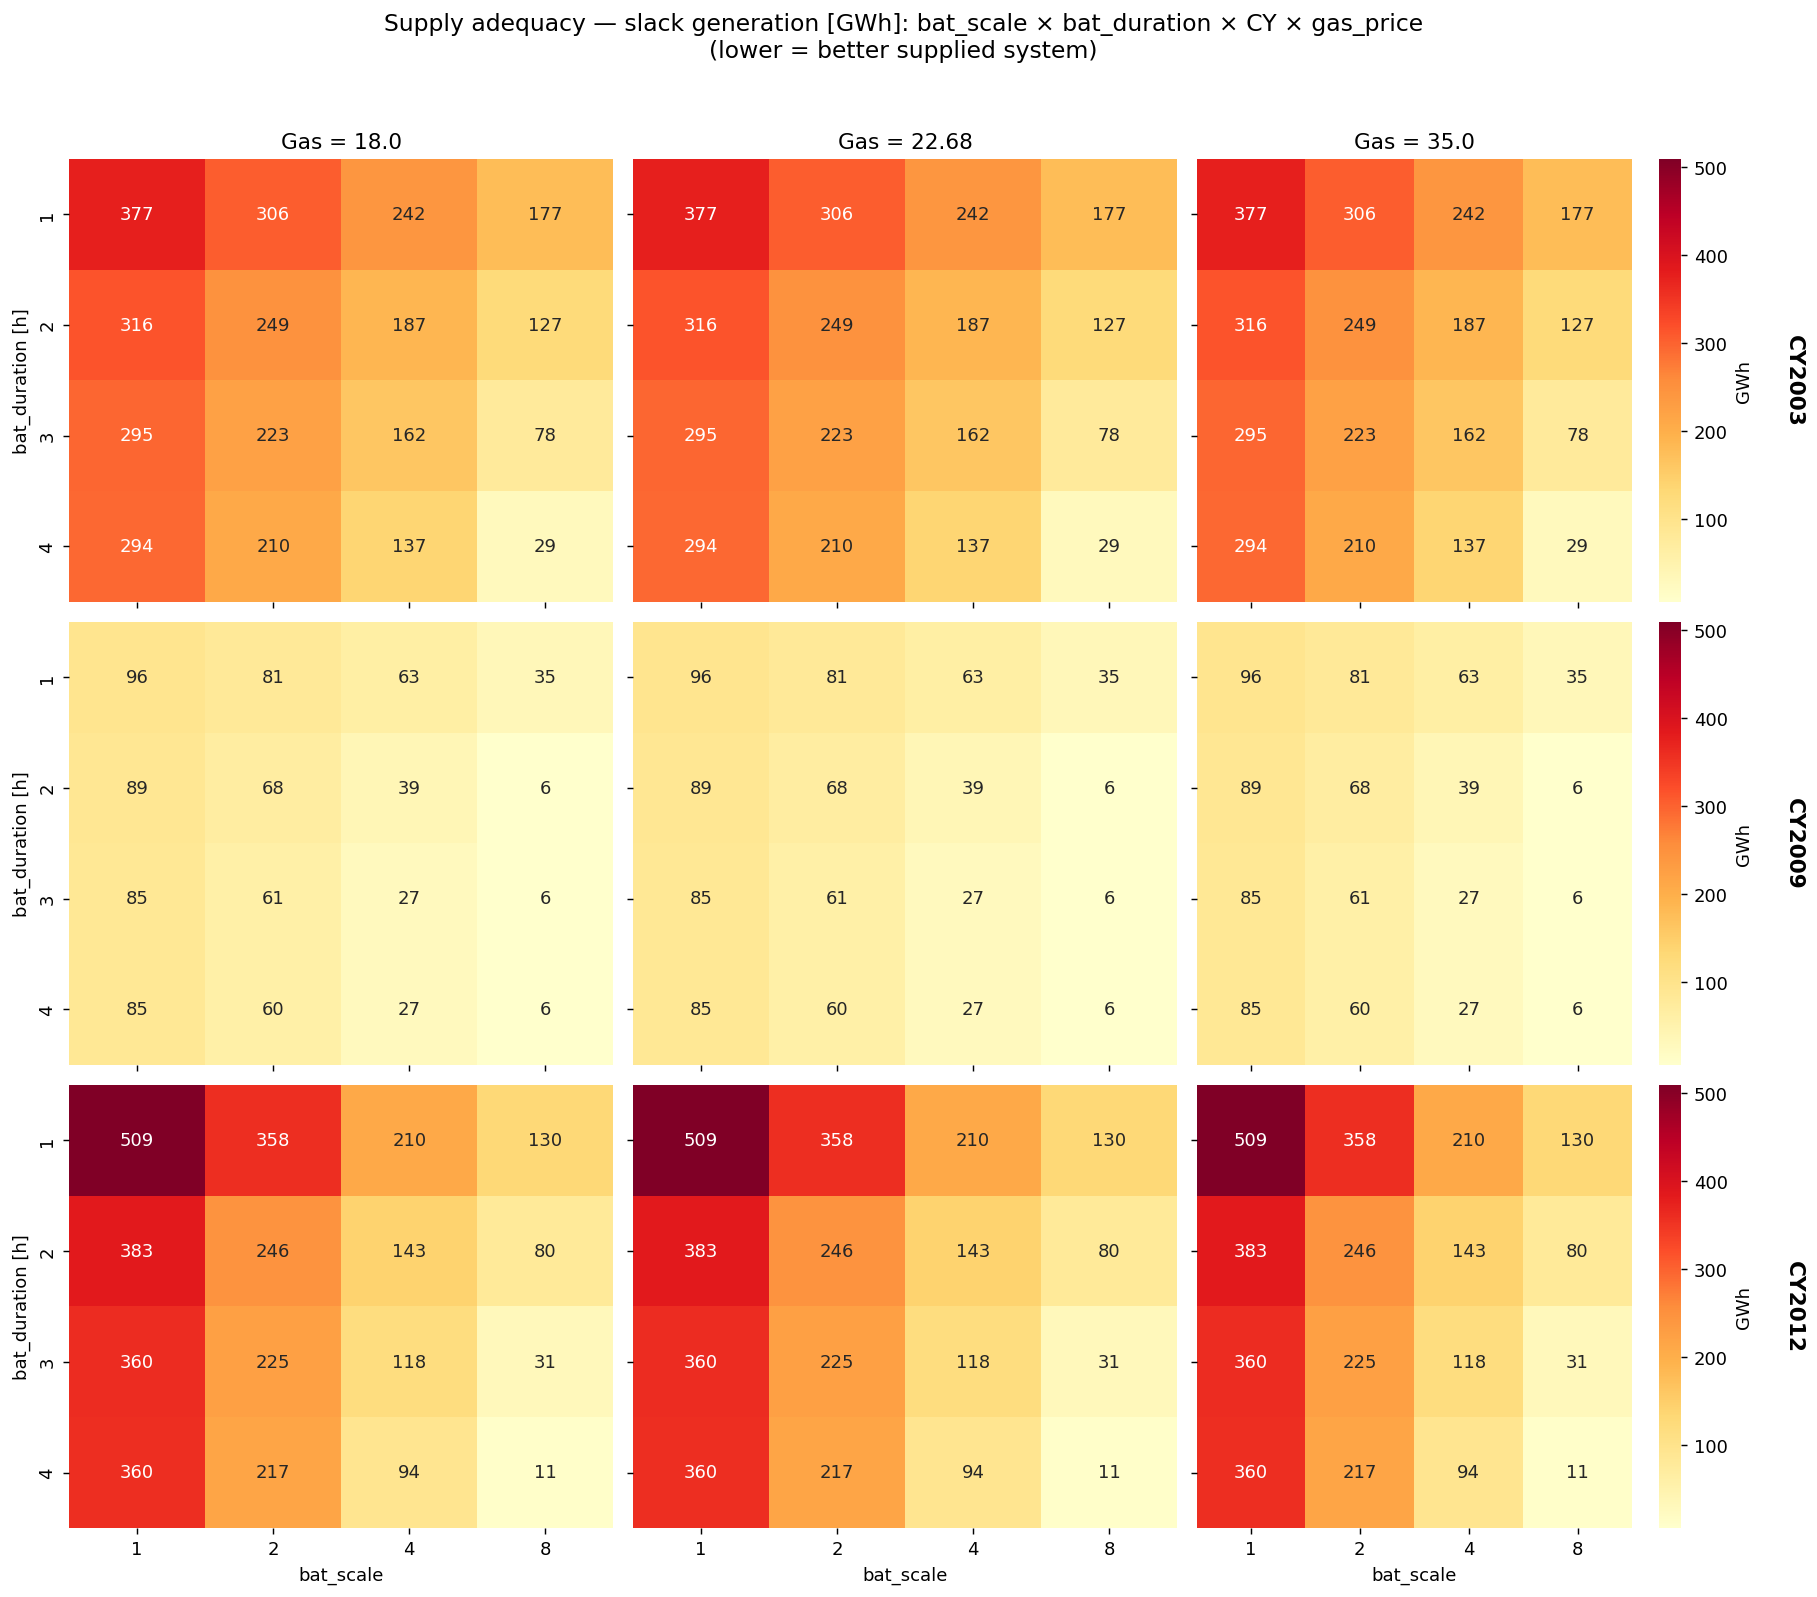

In [28]:
adequacy = res_vol[["tag", "bat_scale", "bat_duration", "gas_price", "co2_price",
                     "climate_year", "slack_mwh", "solve_time_s"]].copy()

print("Slack MWh statistics across all 432 scenarios:")
print(adequacy["slack_mwh"].describe().round(0).to_string())
print(f"\nScenarios with slack > 100k MWh: {(adequacy.slack_mwh > 100_000).sum()}")
print(f"Scenarios with slack < 50k MWh:  {(adequacy.slack_mwh < 50_000).sum()}")

# Slack heatmap — 3×3 grid: CY rows × gas cols, bat_scale × bat_duration inside
CYS_S = sorted(adequacy["climate_year"].unique())
GAS_S = sorted(adequacy["gas_price"].unique())

fig, axes = plt.subplots(3, 3, figsize=(14, 12), sharex=True, sharey=True)

all_medians = adequacy.groupby(["climate_year", "gas_price", "bat_duration", "bat_scale"])["slack_mwh"].median() / 1e3
vmin, vmax = all_medians.min(), all_medians.max()

for row, cy in enumerate(CYS_S):
    for col, gp in enumerate(GAS_S):
        ax = axes[row, col]
        sub = adequacy[(adequacy["climate_year"] == cy) & (adequacy["gas_price"] == gp)]
        pivot = sub.groupby(["bat_duration", "bat_scale"])["slack_mwh"].median().reset_index()
        pivot["slack_gwh"] = pivot["slack_mwh"] / 1e3
        hm = pivot.pivot(index="bat_duration", columns="bat_scale", values="slack_gwh")

        sns.heatmap(hm, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax,
                    cbar=col == 2, vmin=vmin, vmax=vmax,
                    cbar_kws={"label": "GWh"} if col == 2 else {})
        ax.set_xlabel("bat_scale" if row == 2 else "")
        ax.set_ylabel("bat_duration [h]" if col == 0 else "")

        if row == 0:
            ax.set_title(f"Gas = {gp}")
        if col == 2:
            ax.yaxis.set_label_position("right")
            ax.text(1.35, 0.5, f"CY{cy}", transform=ax.transAxes,
                    rotation=-90, va="center", fontsize=12, fontweight="bold")

plt.suptitle("Supply adequacy — slack generation [GWh]: bat_scale × bat_duration × CY × gas_price\n(lower = better supplied system)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## Section 14 — Quantile Regression (DE00)

OLS gives one average β across all scenarios. Quantile regression estimates separate β for different volatility levels (τ):
- **τ = 0.1** → effect among the 10% least volatile scenarios
- **τ = 0.9** → effect among the 10% most volatile scenarios

If a parameter's β changes across τ levels, it means the parameter affects volatility differently in calm vs extreme conditions.

**Caveat:** bat_scale enters as a linear variable (1, 2, 4, 8), so the regression assumes a uniform effect per unit increase. In reality, the effect is non-linear (diminishing returns: 1→2 has more impact than 4→8). The quantile regression captures **how the effect varies across volatility levels**, not the non-linearity in bat_scale itself. For non-linear effects, see Section 16 (SHAP).

In [29]:
from statsmodels.regression.quantile_regression import QuantReg
from sklearn.preprocessing import StandardScaler

params_qr = ["bat_scale", "bat_duration", "gas_price", "co2_price", "climate_year"]
metrics_qr = ["lmp_cv", "lmp_std", "spike_hours", "zero_hours"]
taus = [0.1, 0.25, 0.5, 0.75, 0.9]

X_raw = res_vol[params_qr].values.astype(float)
scaler = StandardScaler()
X_std  = scaler.fit_transform(X_raw)
X_const = np.column_stack([np.ones(len(X_std)), X_std])

# Collect coefficients per metric per tau
qr_results = {}
for metric in metrics_qr:
    y = res_vol[metric].values.astype(float)
    qr_results[metric] = {}
    for tau in taus:
        model = QuantReg(y, X_const).fit(q=tau, max_iter=5000)
        qr_results[metric][tau] = model.params[1:]  # skip intercept

print("Quantile regression coefficients (standardized X):")
for metric in metrics_qr:
    print(f"\n{metric}:")
    print(f"  {'param':15s}  " + "  ".join(f"τ={t}" for t in taus))
    for i, p in enumerate(params_qr):
        vals = "  ".join(f"{qr_results[metric][t][i]:+.3f}" for t in taus)
        print(f"  {p:15s}  {vals}")


Quantile regression coefficients (standardized X):

lmp_cv:
  param            τ=0.1  τ=0.25  τ=0.5  τ=0.75  τ=0.9
  bat_scale        -0.364  -0.105  -0.118  -0.141  -0.121
  bat_duration     -0.064  -0.088  -0.022  -0.070  -0.066
  gas_price        -0.138  -0.157  -0.231  -0.248  -0.246
  co2_price        -0.097  -0.107  -0.163  -0.181  -0.182
  climate_year     -0.545  -0.569  -0.129  +0.070  +0.107

lmp_std:
  param            τ=0.1  τ=0.25  τ=0.5  τ=0.75  τ=0.9
  bat_scale        -23.017  -6.159  -10.312  -11.826  -8.342
  bat_duration     -4.408  -5.391  -0.771  -5.944  -8.427
  gas_price        +1.576  +1.107  +0.606  +0.327  +0.254
  co2_price        +1.054  +0.818  +0.436  +0.239  +0.196
  climate_year     -57.547  -57.507  -15.897  +3.391  +10.719

spike_hours:
  param            τ=0.1  τ=0.25  τ=0.5  τ=0.75  τ=0.9
  bat_scale        -5.121  -4.656  -8.873  -14.251  -12.510
  bat_duration     -2.471  -2.413  -4.313  -7.591  -7.329
  gas_price        +0.704  +1.256  +2.827  +6.

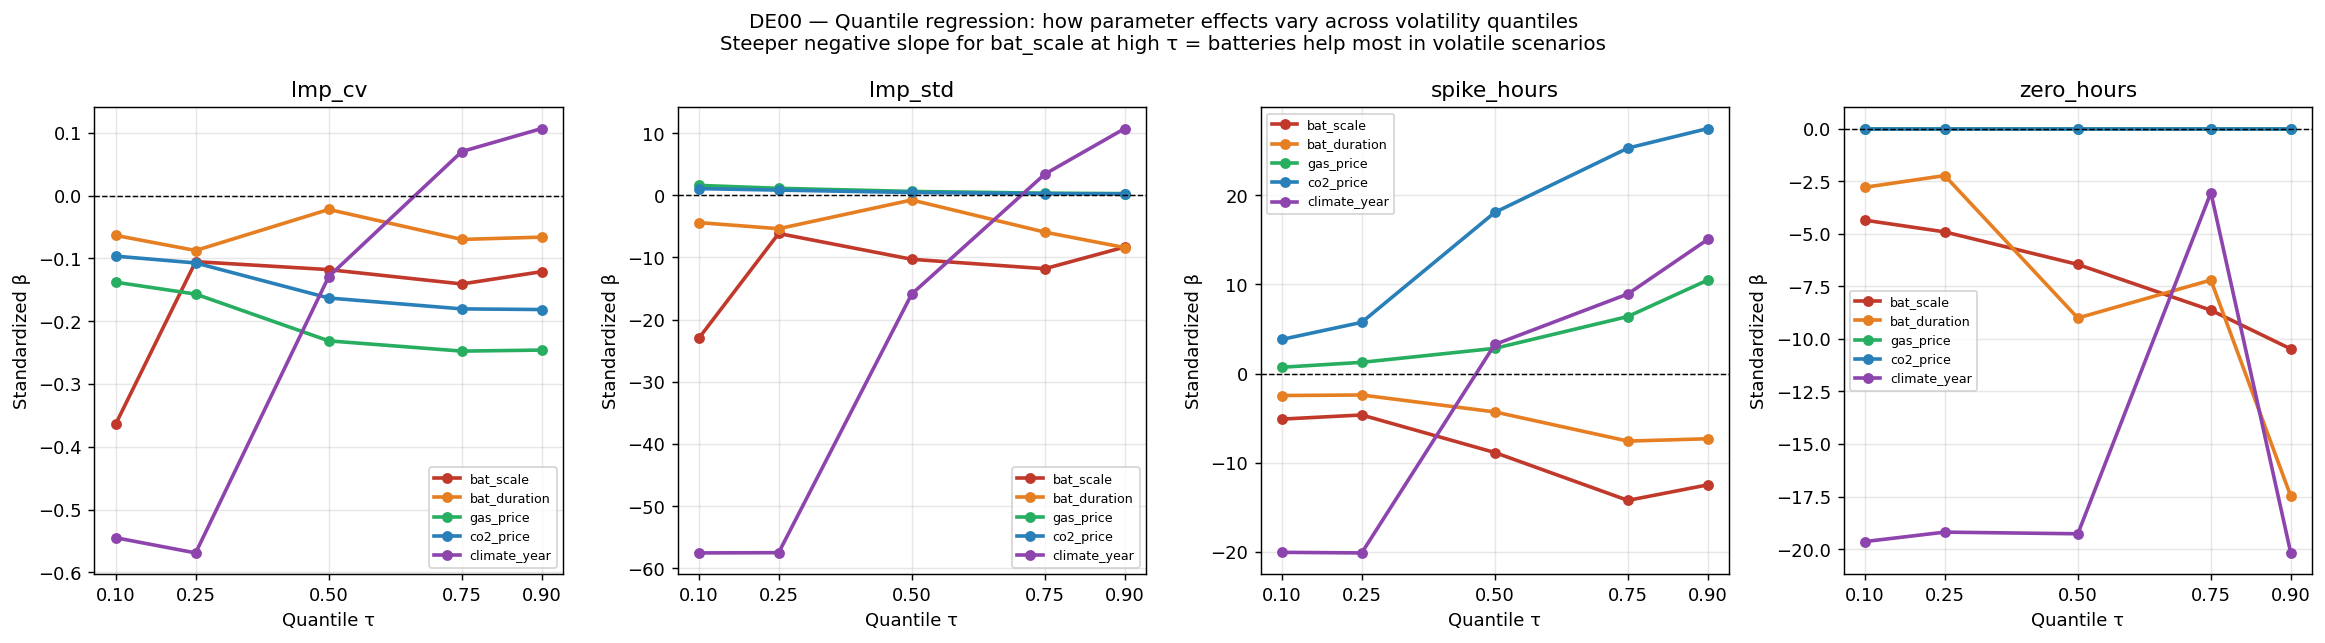

In [30]:
# Plot: β of each parameter vs quantile level — one subplot per metric
fig, axes = plt.subplots(1, len(metrics_qr), figsize=(18, 5))
param_colors = {"bat_scale":"#c0392b","bat_duration":"#e67e22",
                "gas_price":"#27ae60","co2_price":"#2980b9","climate_year":"#8e44ad"}

for ax, metric in zip(axes, metrics_qr):
    for i, p in enumerate(params_qr):
        betas = [qr_results[metric][t][i] for t in taus]
        ax.plot(taus, betas, "o-", color=param_colors[p], linewidth=2,
                markersize=5, label=p)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Quantile τ")
    ax.set_ylabel("Standardized β")
    ax.set_title(metric)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.set_xticks(taus)

fig.suptitle("DE00 — Quantile regression: how parameter effects vary across volatility quantiles\n"
             "Steeper negative slope for bat_scale at high τ = batteries help most in volatile scenarios",
             fontsize=11)
plt.tight_layout()
plt.show()

# Focus plot: bat_scale β across τ for all 4 metrics

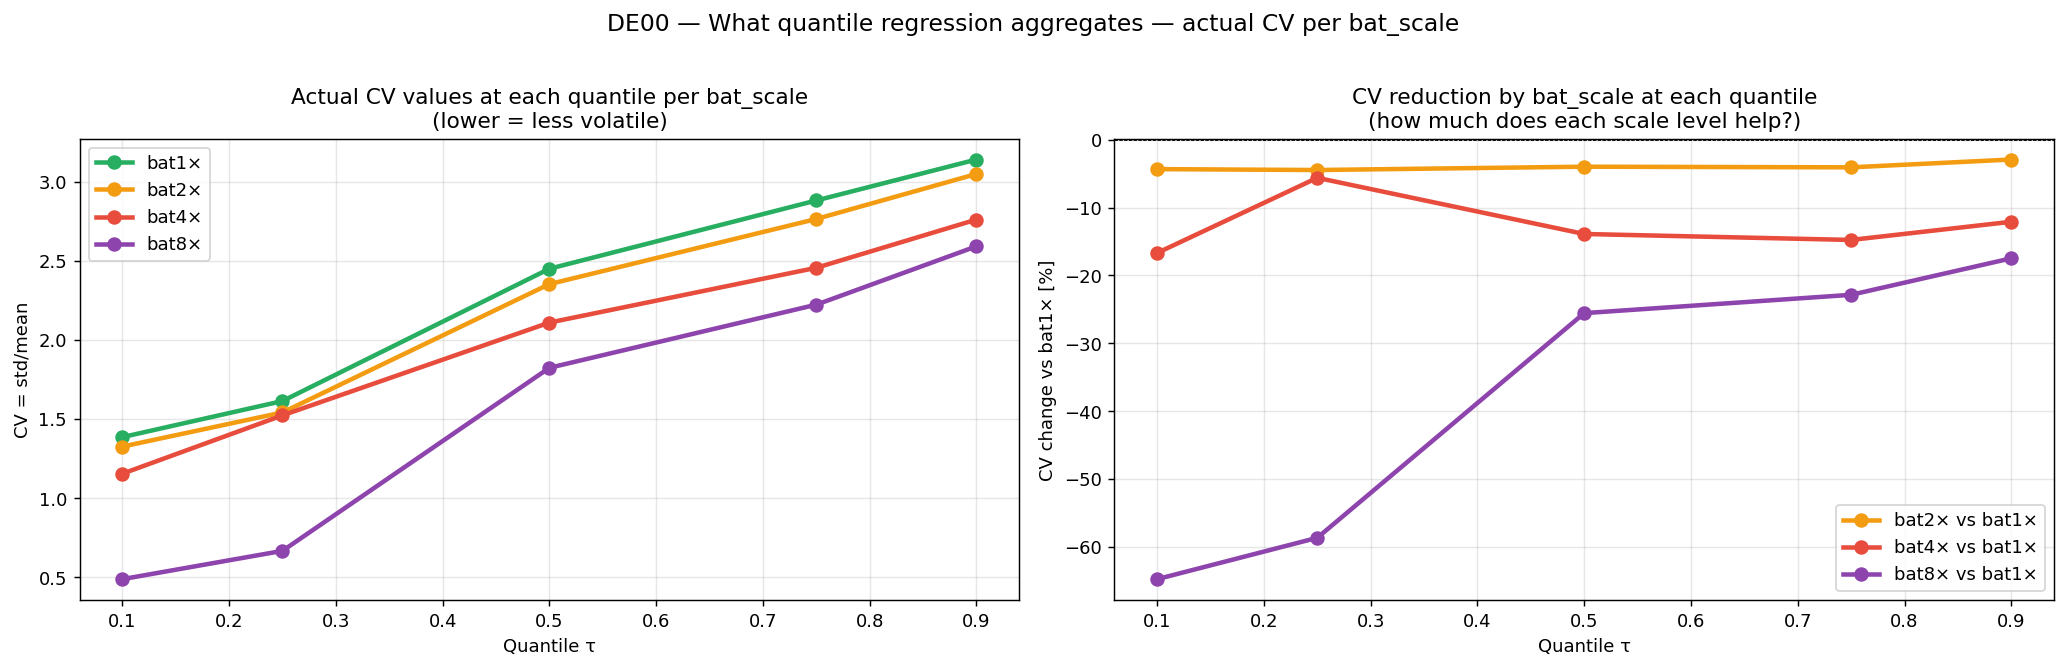

CV at key quantiles per bat_scale:
  bat1×: τ=0.1=1.385, τ=0.5=2.449, τ=0.9=3.139
  bat2×: τ=0.1=1.325, τ=0.5=2.352, τ=0.9=3.048
  bat4×: τ=0.1=1.154, τ=0.5=2.109, τ=0.9=2.760
  bat8×: τ=0.1=0.488, τ=0.5=1.823, τ=0.9=2.591


In [31]:
# CV distribution per bat_scale — shows actual values, not regression coefficients
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

scale_colors_qr = {1: "#27ae60", 2: "#f39c12", 4: "#e74c3c", 8: "#8e44ad"}
quantiles_plot = [0.10, 0.25, 0.50, 0.75, 0.90]

# Left: CV quantiles per bat_scale
ax = axes[0]
for bs in [1, 2, 4, 8]:
    cv_vals = res_vol[res_vol.bat_scale == bs]["lmp_cv"]
    q_vals = [cv_vals.quantile(q) for q in quantiles_plot]
    ax.plot(quantiles_plot, q_vals, "o-", color=scale_colors_qr[bs], lw=2.5,
            markersize=7, label=f"bat{bs}×")

ax.set_xlabel("Quantile τ")
ax.set_ylabel("CV = std/mean")
ax.set_title("Actual CV values at each quantile per bat_scale\n(lower = less volatile)")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Right: CV reduction vs bat1× at each quantile
ax = axes[1]
cv_1x = res_vol[res_vol.bat_scale == 1]["lmp_cv"]
q_1x = [cv_1x.quantile(q) for q in quantiles_plot]

for bs in [2, 4, 8]:
    cv_bs = res_vol[res_vol.bat_scale == bs]["lmp_cv"]
    q_bs = [cv_bs.quantile(q) for q in quantiles_plot]
    pct_change = [(qb - q1) / q1 * 100 for qb, q1 in zip(q_bs, q_1x)]
    ax.plot(quantiles_plot, pct_change, "o-", color=scale_colors_qr[bs], lw=2.5,
            markersize=7, label=f"bat{bs}× vs bat1×")
    

ax.axhline(0, color="black", ls="--", lw=0.5)
ax.set_xlabel("Quantile τ")
ax.set_ylabel("CV change vs bat1× [%]")
ax.set_title("CV reduction by bat_scale at each quantile\n(how much does each scale level help?)")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.suptitle("DE00 — What quantile regression aggregates — actual CV per bat_scale", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# Print key numbers
print("CV at key quantiles per bat_scale:")
for bs in [1, 2, 4, 8]:
    cv = res_vol[res_vol.bat_scale == bs]["lmp_cv"]
    print(f"  bat{bs}×: τ=0.1={cv.quantile(0.1):.3f}, τ=0.5={cv.quantile(0.5):.3f}, τ=0.9={cv.quantile(0.9):.3f}")

## Section 15 — Tail Risk & Slack: Explaining the CY2012 vs CY2003 Paradox

Hypothesis: CY2012 (cold year) has more severe supply shortfalls (higher slack_mwh),
so batteries provide larger adequacy benefit → stronger CV reduction.


CY2003: bat1x=320.4 GWh, bat8x=102.8 GWh (reduction=67.9%)
CY2009: bat1x=88.9 GWh, bat8x=13.0 GWh (reduction=85.3%)
CY2012: bat1x=402.9 GWh, bat8x=63.2 GWh (reduction=84.3%)


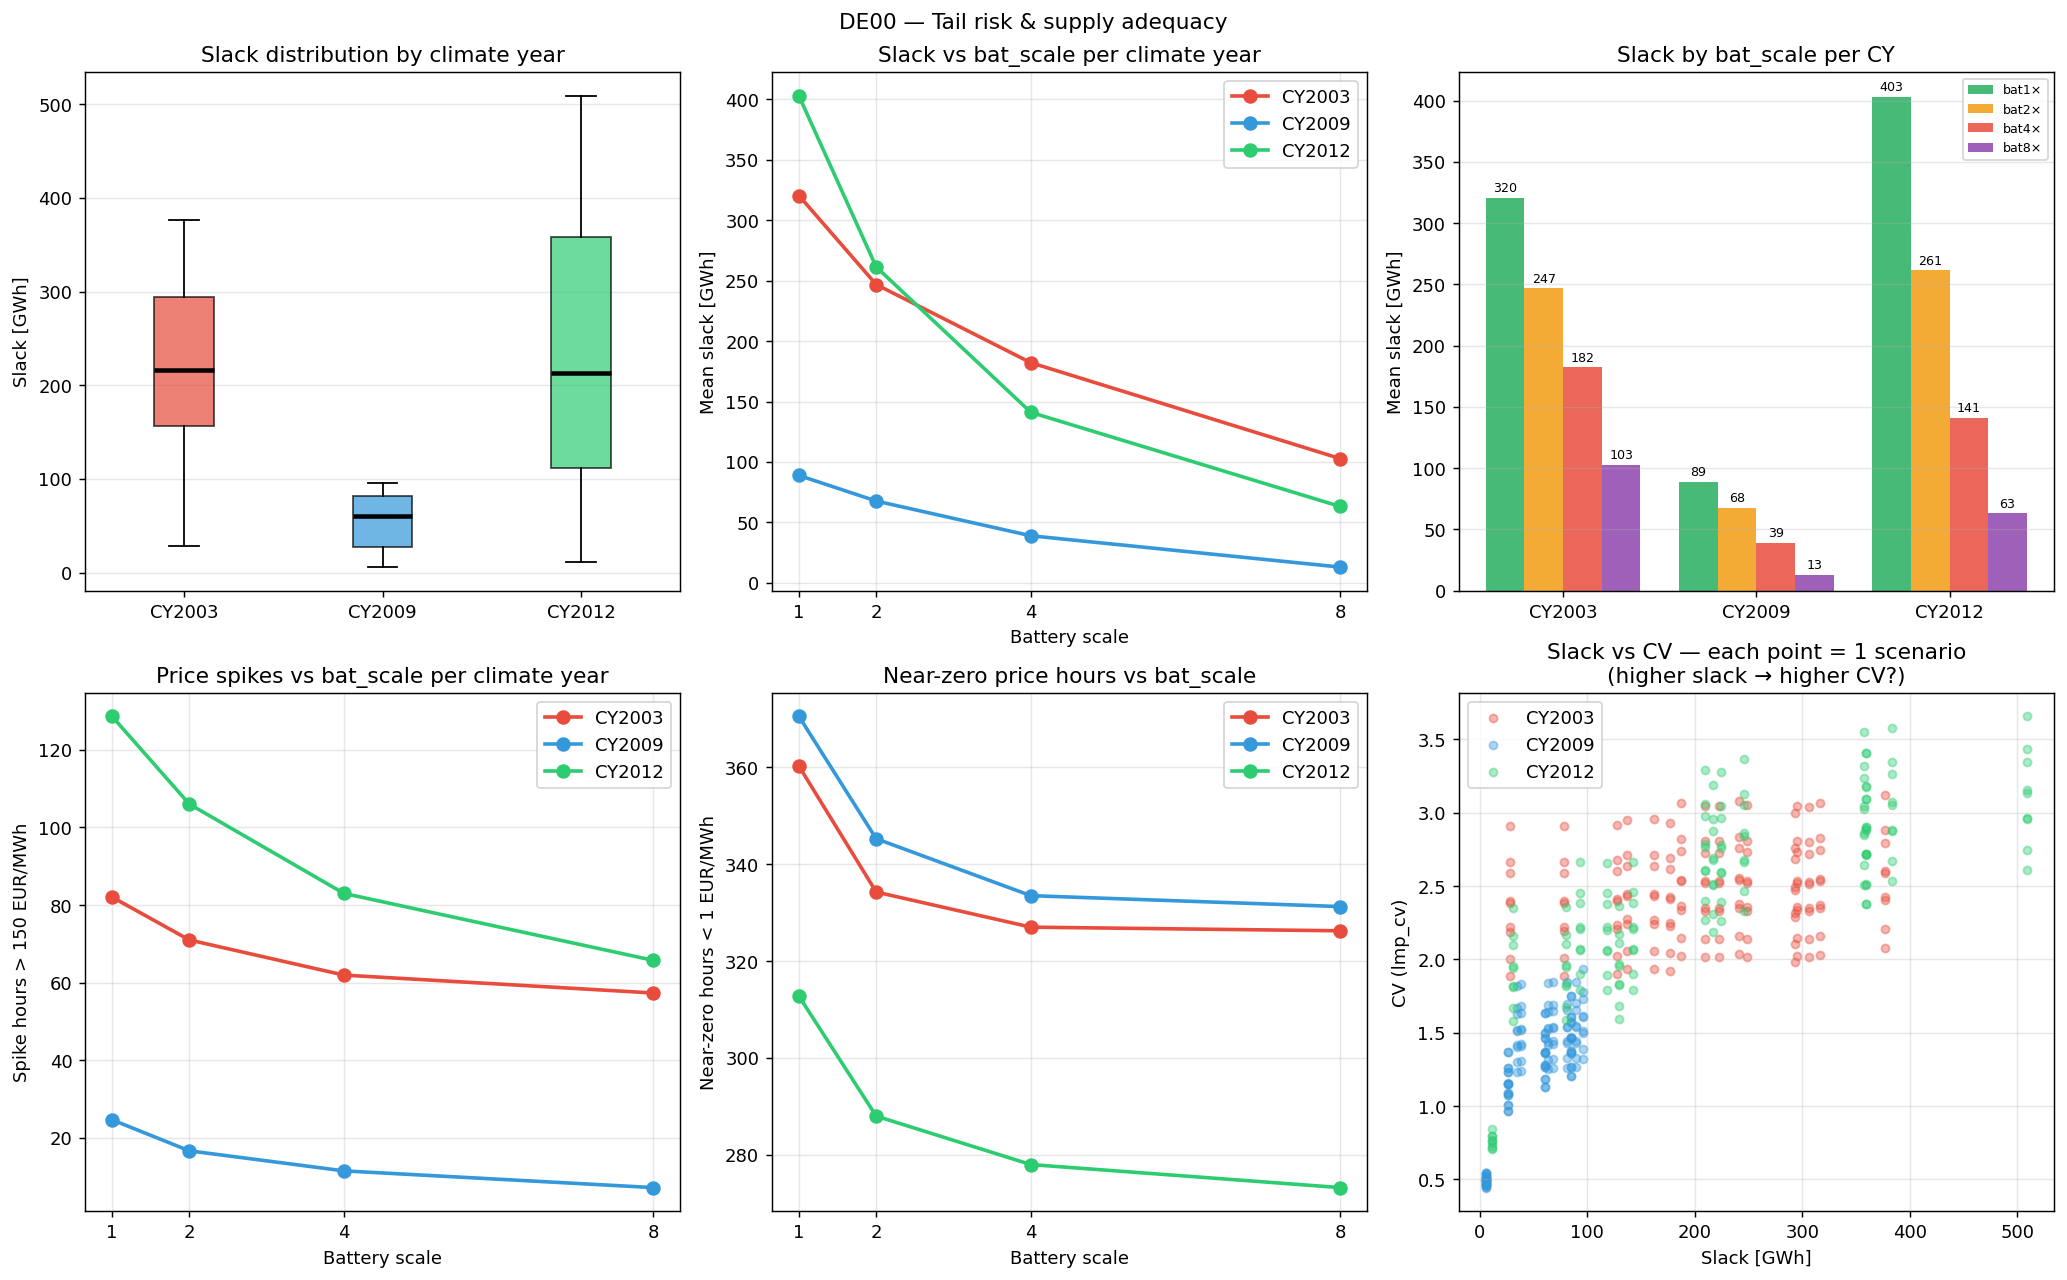

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
cy_colors = {2003:"#e74c3c", 2009:"#3498db", 2012:"#2ecc71"}

# 1. Slack distribution per climate year
ax = axes[0,0]
data_box = [res_vol[res_vol.climate_year==cy]["slack_mwh"].values/1e3 for cy in cy_list]
bp = ax.boxplot(data_box, labels=[f"CY{cy}" for cy in cy_list], patch_artist=True,
                   medianprops=dict(color="black", lw=2.5))
for patch, cy in zip(bp["boxes"], cy_list):
    patch.set_facecolor(cy_colors[cy]); patch.set_alpha(0.7)
ax.set_ylabel("Slack [GWh]"); ax.set_title("Slack distribution by climate year")
ax.grid(axis="y", alpha=0.3)

# 2. Slack vs bat_scale per climate year
ax = axes[0,1]
for cy, color in cy_colors.items():
    vals = [res_vol[(res_vol.climate_year==cy)&(res_vol.bat_scale==s)]["slack_mwh"].mean()/1e3
            for s in scales]
    ax.plot(scales, vals, "o-", color=color, linewidth=2, markersize=7, label=f"CY{cy}")
ax.set_xlabel("Battery scale"); ax.set_ylabel("Mean slack [GWh]")
ax.set_title("Slack vs bat_scale per climate year"); ax.legend(); ax.grid(alpha=0.3)
ax.set_xticks(scales)

# 3. % Slack by bat_scale per climate year (grouped bars, absolute GWh)
ax = axes[0,2]
x_pos = np.arange(len(cy_list))
bar_w = 0.2
sc_colors = {1: "#27ae60", 2: "#f39c12", 4: "#e74c3c", 8: "#8e44ad"}
for k, bs in enumerate([1, 2, 4, 8]):
    vals = [res_vol[(res_vol.climate_year==cy)&(res_vol.bat_scale==bs)]["slack_mwh"].mean()/1e3
            for cy in cy_list]
    b = ax.bar(x_pos + k*bar_w, vals, bar_w, color=sc_colors[bs], alpha=0.85,
               label=f"bat{bs}×")
    for bi, v in zip(b, vals):
        ax.text(bi.get_x() + bi.get_width()/2, v + 5, f"{v:.0f}", ha="center", fontsize=7)
ax.set_xticks(x_pos + 1.5*bar_w)
ax.set_xticklabels([f"CY{cy}" for cy in cy_list])
ax.set_ylabel("Mean slack [GWh]")
ax.set_title("Slack by bat_scale per CY")
ax.legend(fontsize=7); ax.grid(axis="y", alpha=0.3)
for cy in cy_list:
    s1 = res_vol[(res_vol.climate_year==cy)&(res_vol.bat_scale==1)]["slack_mwh"].mean()
    s8 = res_vol[(res_vol.climate_year==cy)&(res_vol.bat_scale==8)]["slack_mwh"].mean()
    print(f"CY{cy}: bat1x={s1/1e3:.1f} GWh, bat8x={s8/1e3:.1f} GWh (reduction={(s1-s8)/s1*100:.1f}%)")

# 4. spike_hours vs bat_scale per climate year
ax = axes[1,0]
for cy, color in cy_colors.items():
    vals = [res_vol[(res_vol.climate_year==cy)&(res_vol.bat_scale==s)]["spike_hours"].mean()
            for s in scales]
    ax.plot(scales, vals, "o-", color=color, linewidth=2, markersize=7, label=f"CY{cy}")
ax.set_xlabel("Battery scale"); ax.set_ylabel("Spike hours > 150 EUR/MWh")
ax.set_title("Price spikes vs bat_scale per climate year"); ax.legend(); ax.grid(alpha=0.3)
ax.set_xticks(scales)

# 5. zero_hours vs bat_scale per climate year
ax = axes[1,1]
for cy, color in cy_colors.items():
    vals = [res_vol[(res_vol.climate_year==cy)&(res_vol.bat_scale==s)]["zero_hours"].mean()
            for s in scales]
    ax.plot(scales, vals, "o-", color=color, linewidth=2, markersize=7, label=f"CY{cy}")
ax.set_xlabel("Battery scale"); ax.set_ylabel("Near-zero hours < 1 EUR/MWh")
ax.set_title("Near-zero price hours vs bat_scale"); ax.legend(); ax.grid(alpha=0.3)
ax.set_xticks(scales)

# 6. CV reduction vs slack level (scatter — each point = one scenario)
ax = axes[1,2]
for cy, color in cy_colors.items():
    sub = res_vol[res_vol.climate_year==cy]
    ax.scatter(sub.slack_mwh/1e3, sub.lmp_cv, color=color, alpha=0.4, s=20, label=f"CY{cy}")
ax.set_xlabel("Slack [GWh]"); ax.set_ylabel("CV (lmp_cv)")
ax.set_title("Slack vs CV — each point = 1 scenario\n(higher slack → higher CV?)")
ax.legend(); ax.grid(alpha=0.3)

fig.suptitle("DE00 — Tail risk & supply adequacy",
             fontsize=12)
plt.tight_layout()
plt.show()

## Section 16 — Merit Order Displacement

Which generators are displaced when battery scale increases from 1× to 8×?
Uses `gen_p.parquet` — filters to 6 scenarios (3 climate years × bat1×/bat8×).

Flatter merit order (more flexible generation) → lower price volatility.


In [33]:
gen_file = PREPROCESSED / "gen_p.parquet"

# 6 scenarios: bat_scale [1,8], gas=22.68, co2=113.4, dur=1, all 3 climate years
gen_tags = res_vol[
    (res_vol.gas_price == 22.68) & (res_vol.co2_price == 113.4) &
    (res_vol.bat_scale.isin([1, 8])) & (res_vol.bat_duration == 1)
]["tag"].tolist()

print(f"Loading gen_p for {len(gen_tags)} scenarios...")
gen_raw = pd.read_parquet(gen_file, filters=[("tag", "in", gen_tags)])
print(f"gen_p shape: {gen_raw.shape}")

# Map generator columns to carrier using static_gen
gen_unit_cols = [c for c in gen_raw.columns if c not in ["tag","timestamp"]]

# Carrier grouping
carrier_map = static_gen["carrier"].to_dict()
CARRIER_GROUPS = {
    "nuclear":["nuclear"], "coal":["coal","coal-ccs"],
    "lignite":["lignite","lignite-ccs"], "gas":["gas","gas-ccgt","gas-ocgt","gas-ccs","h2-ccgt","h2-fuel-cell"],
    "oil":["oil-heavy","oil-light","oil-shale","other-thermal"],
    "onwind":["onwind"], "offwind":["offwind"],
    "solar":["solar-pv-utility","solar-pv-rooftop"],
    "hydro":["hydro-ror"], "other-res":["other-res"],
    "dsr":["DSR","dsr"], "battery":["battery"],
}

def get_group(carrier):
    for grp, carriers in CARRIER_GROUPS.items():
        if carrier in carriers: return grp
    return "other"

gen_raw["timestamp"] = pd.to_datetime(gen_raw["timestamp"])
gen_meta = gen_raw.merge(res_vol[["tag","bat_scale","climate_year"]], on="tag")
print("Carriers in static_gen:", static_gen["carrier"].unique()[:15])


Loading gen_p for 6 scenarios...
gen_p shape: (52560, 559)
Carriers in static_gen: ['gas' 'oil-light' 'lignite' 'coal' 'nuclear' 'oil-heavy' 'oil-shale'
 'gas-ccs' 'hydro-ror' 'onwind' 'solar-pv-utility' 'solar-pv-rooftop'
 'other-thermal' 'other-res' 'offwind']


In [34]:
# Annual generation by carrier group
records = []
for _, grp_row in res_vol[res_vol.tag.isin(gen_tags)][["tag","bat_scale","climate_year"]].iterrows():
    tag = grp_row["tag"]
    sub = gen_raw[gen_raw.tag == tag]
    for col in gen_unit_cols:
        if col not in static_gen.index: continue
        carrier = carrier_map.get(col, "other")
        group   = get_group(carrier)
        total_twh = sub[col].sum() / 1e6  # MWh → TWh
        records.append({"tag":tag, "bat_scale":grp_row["bat_scale"],
                        "climate_year":grp_row["climate_year"],
                        "carrier_group":group, "twh":total_twh})

gen_df = pd.DataFrame(records)
gen_agg = gen_df.groupby(["bat_scale","climate_year","carrier_group"])["twh"].sum().reset_index()
print("Generation computed.")
print(gen_agg[gen_agg.climate_year==2009].pivot(index="carrier_group",
      columns="bat_scale", values="twh").round(1).to_string())


Generation computed.
bat_scale               1           8
carrier_group                        
coal             3.500000    3.300000
dsr             32.900002   33.099998
gas            348.500000  318.899994
hydro          201.600006  201.600006
lignite          0.100000    0.000000
nuclear        602.200012  605.099976
offwind        627.400024  634.099976
oil             65.300003   61.599998
onwind         838.299988  860.200012
other           48.599998   48.500000
other-res      124.000000  125.900002
solar          769.400024  771.099976


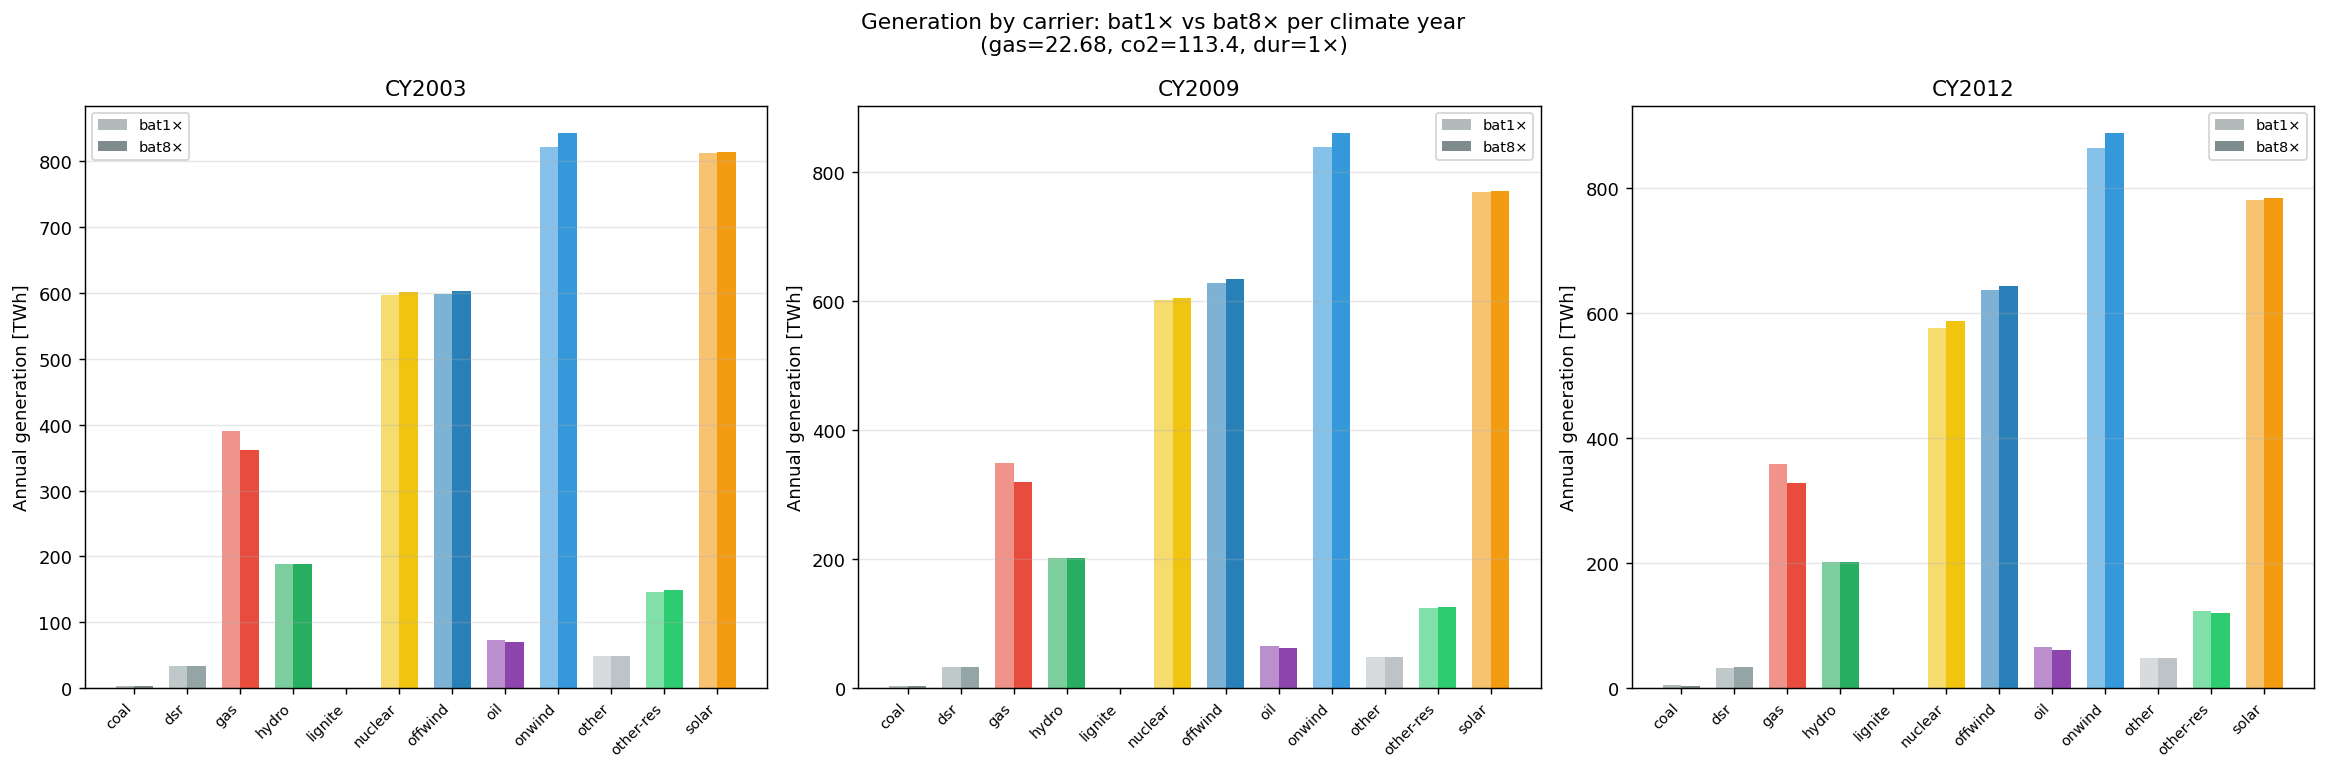


Displacement (bat8x - bat1x) [TWh] — averaged over 3 climate years:
carrier_group
gas         -29.500000
oil          -3.830000
coal         -0.290000
other        -0.210000
lignite      -0.080000
hydro         0.000000
other-res     0.330000
dsr           0.460000
solar         1.630000
nuclear       5.770000
offwind       6.000000
onwind       21.940001


In [35]:
carrier_colors = {
    "nuclear":"#f1c40f","coal":"#7f8c8d","lignite":"#6d4c41",
    "gas":"#e74c3c","oil":"#8e44ad","onwind":"#3498db",
    "offwind":"#2980b9","solar":"#f39c12","hydro":"#27ae60",
    "other-res":"#2ecc71","dsr":"#95a5a6","battery":"#1abc9c","other":"#bdc3c7"
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, cy in zip(axes, cy_list):
    sub1 = gen_agg[(gen_agg.climate_year==cy) & (gen_agg.bat_scale==1)].set_index("carrier_group")["twh"]
    sub8 = gen_agg[(gen_agg.climate_year==cy) & (gen_agg.bat_scale==8)].set_index("carrier_group")["twh"]
    carriers = sorted(set(sub1.index)|set(sub8.index))
    x = np.arange(len(carriers)); w = 0.35

    bars1 = [sub1.get(c, 0) for c in carriers]
    bars8 = [sub8.get(c, 0) for c in carriers]
    colors = [carrier_colors.get(c, "#bdc3c7") for c in carriers]

    ax.bar(x - w/2, bars1, w, color=colors, alpha=0.6, label="bat1×")
    ax.bar(x + w/2, bars8, w, color=colors, alpha=1.0, label="bat8×")
    ax.set_xticks(x); ax.set_xticklabels(carriers, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Annual generation [TWh]")
    ax.set_title(f"CY{cy}"); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

fig.suptitle("Generation by carrier: bat1× vs bat8× per climate year\n"
             "(gas=22.68, co2=113.4, dur=1×)", fontsize=12)
plt.tight_layout()
plt.show()

# Displacement summary
print("\nDisplacement (bat8x - bat1x) [TWh] — averaged over 3 climate years:")
disp = gen_agg.groupby(["bat_scale","carrier_group"])["twh"].mean().unstack(0)
if 1 in disp.columns and 8 in disp.columns:
    disp["delta"] = disp[8] - disp[1]
    print(disp["delta"].sort_values().round(2).to_string())


## Section 17 — Merit Order Displacement by Bidding Zone

Which bidding zones experience the largest shift in generation mix when battery capacity scales from 1× to 8×?
Metric: total annual generation change (TWh) per carrier per zone, averaged over all other scenario parameters.

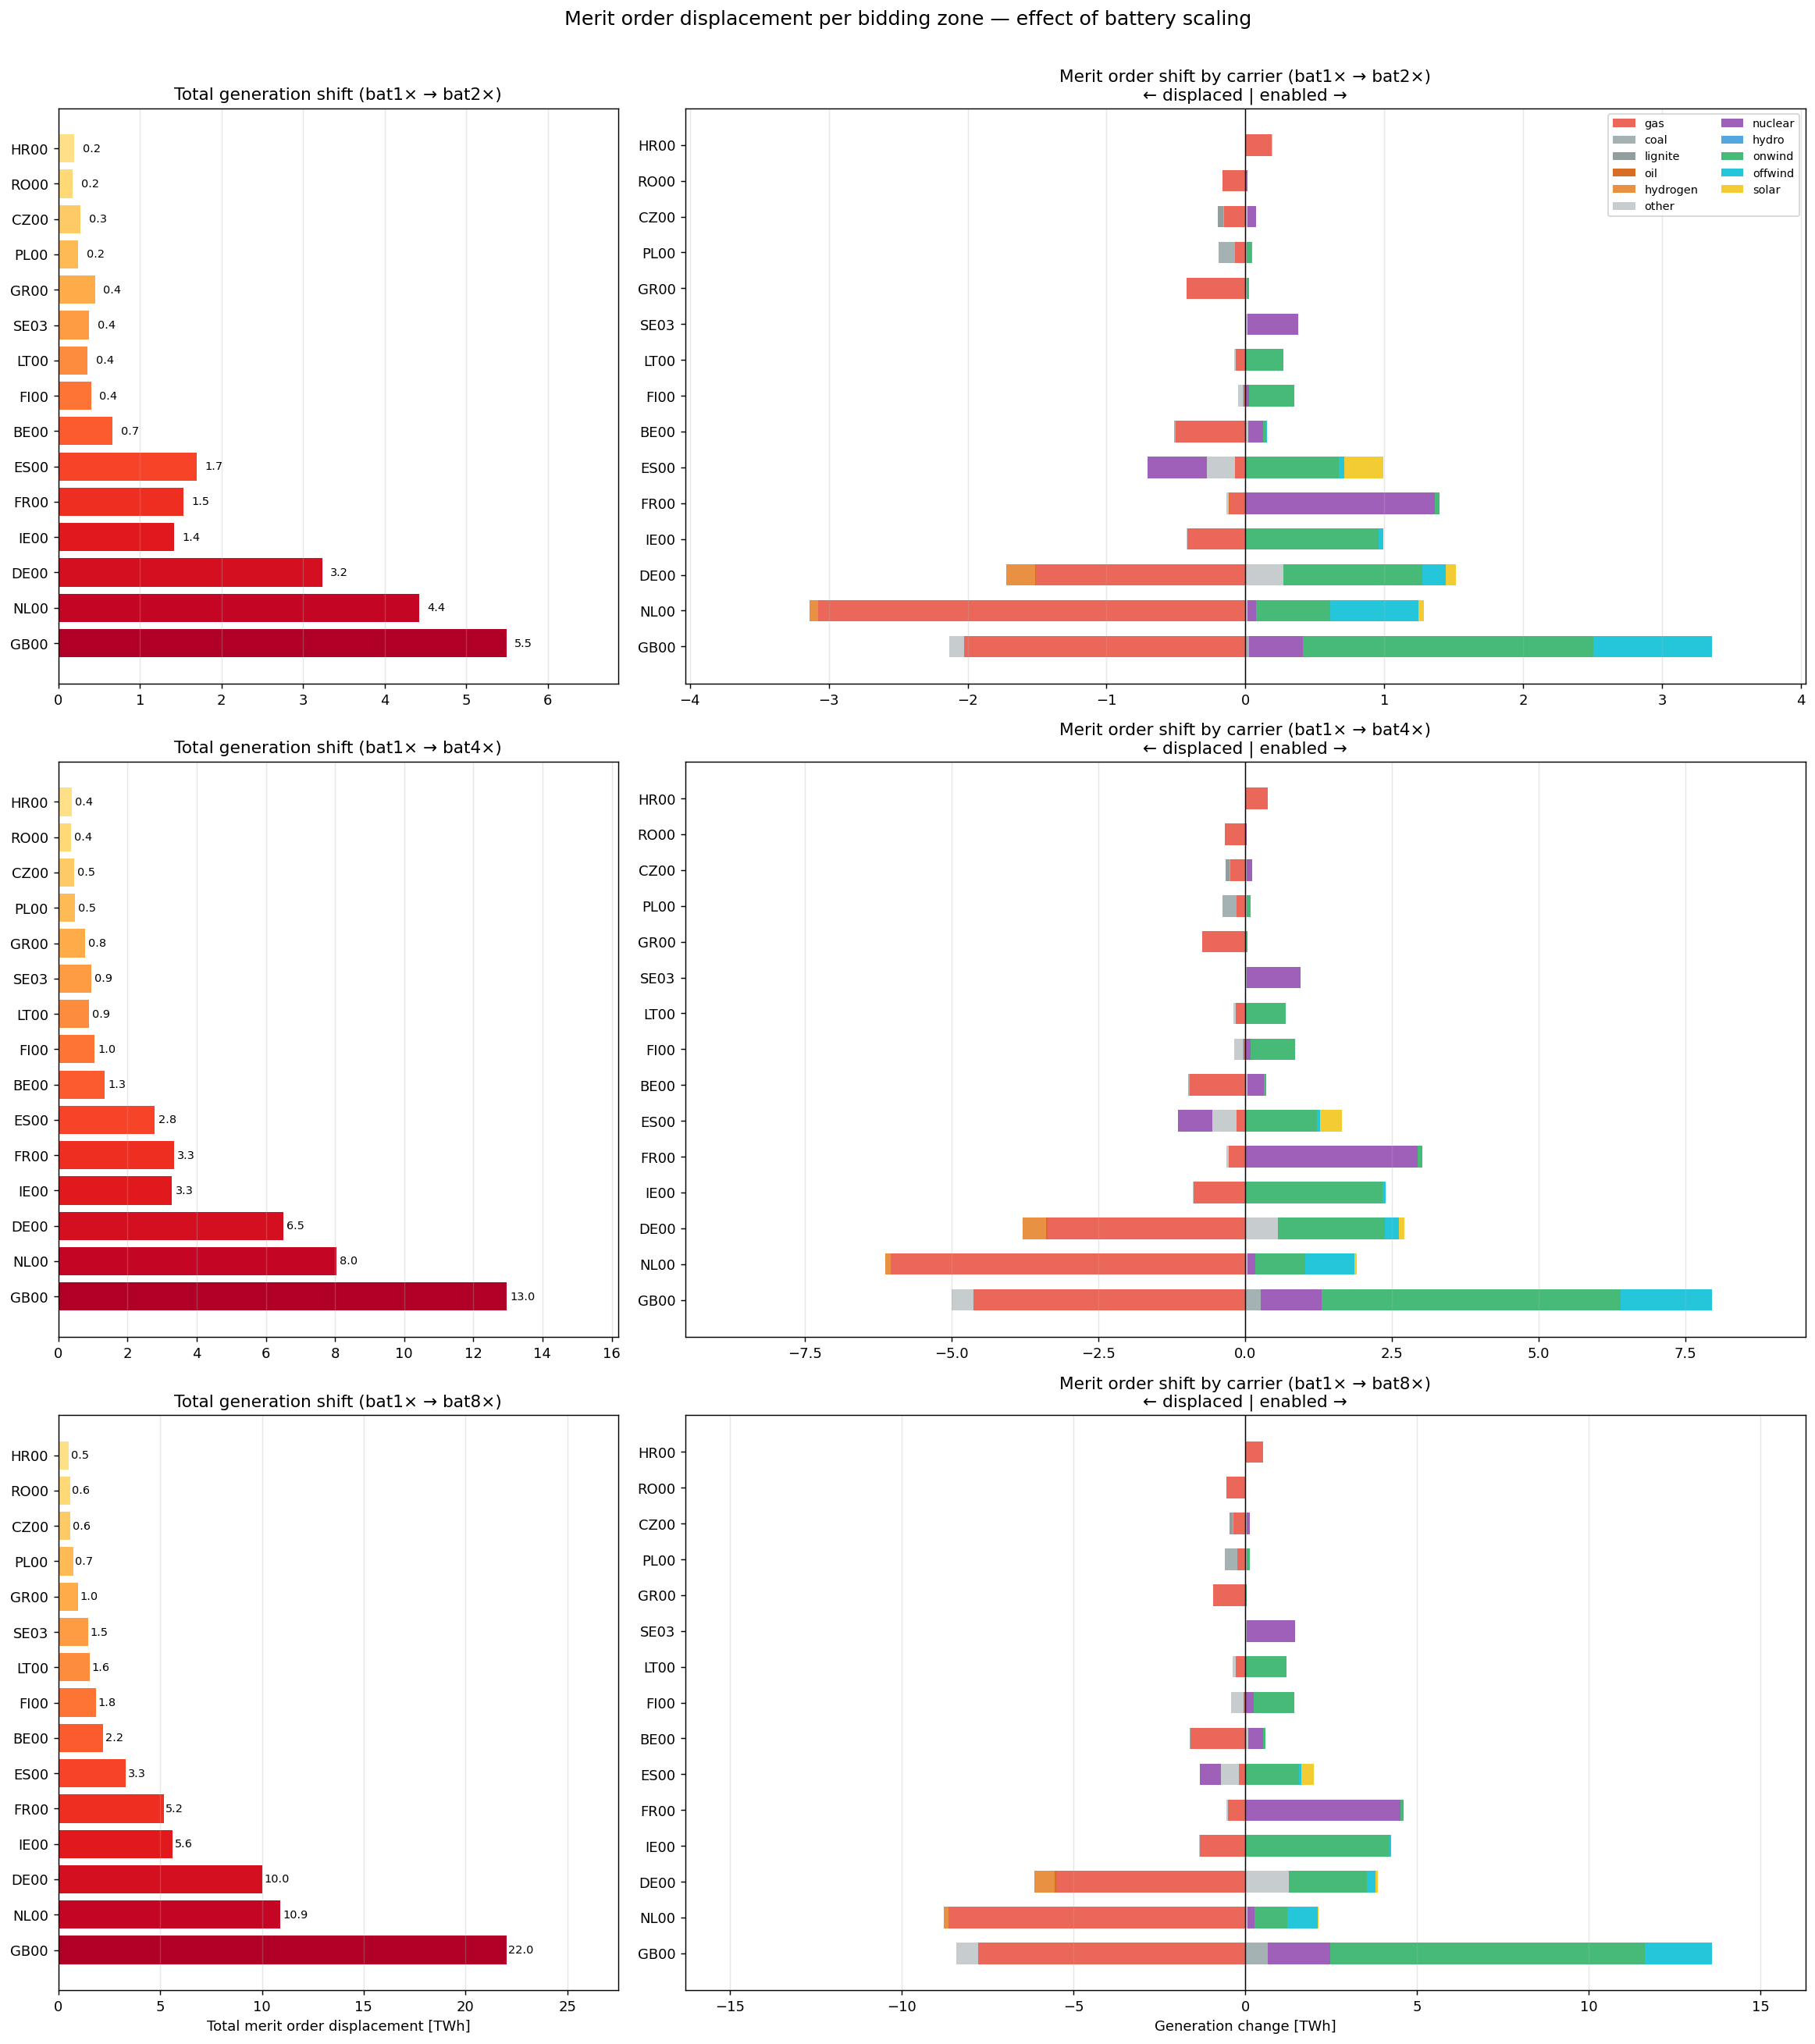

In [36]:
import re

# Load gen_p
gp = pd.read_parquet(PREPROCESSED / "gen_p.parquet")
gp['bat_scale'] = gp['tag'].str.extract(r'bat(\d+)x')[0].astype(int)
gen_cols_gp = [c for c in gp.columns if re.match(r'^[A-Z]{2}\d{2}-', c)]

def carrier_group(carrier):
    if carrier.startswith('slack') or carrier.startswith('dsr'):
        return None
    if 'onwind' in carrier: return 'onwind'
    if 'offwind' in carrier: return 'offwind'
    if 'solar' in carrier: return 'solar'
    if 'nuclear' in carrier: return 'nuclear'
    if 'hydro' in carrier: return 'hydro'
    if 'lignite' in carrier: return 'lignite'
    if 'coal' in carrier: return 'coal'
    if 'gas' in carrier: return 'gas'
    if 'oil' in carrier: return 'oil'
    if 'h2' in carrier: return 'hydrogen'
    return 'other'

gen_info = {}
for c in gen_cols_gp:
    m = re.match(r'^([A-Z]{2}\d{2})-(.*)', c)
    if m:
        zone, carrier = m.group(1), m.group(2)
        cg = carrier_group(carrier)
        if cg:
            gen_info[c] = (zone, cg)

# Compute annual generation per zone-carrier for each bat_scale (avg over other params)
records = []
for bs in [1, 2, 4, 8]:
    sub = gp[gp.bat_scale == bs]
    n_tags = sub['tag'].nunique()
    for col, (zone, cg) in gen_info.items():
        twh = sub[col].sum() / 1e6 / n_tags
        records.append({'bat_scale': bs, 'zone': zone, 'carrier': cg, 'twh': twh})

df_mo = pd.DataFrame(records).groupby(['bat_scale', 'zone', 'carrier'])['twh'].sum().reset_index()

carrier_colors_mo = {
    'gas': '#e74c3c', 'coal': '#95a5a6', 'lignite': '#7f8c8d', 'oil': '#d35400',
    'nuclear': '#8e44ad', 'onwind': '#27ae60', 'offwind': '#00bcd4',
    'solar': '#f1c40f', 'hydro': '#3498db', 'hydrogen': '#e67e22', 'other': '#bdc3c7'
}
all_carriers = ['gas', 'coal', 'lignite', 'oil', 'hydrogen', 'other',
                'nuclear', 'hydro', 'onwind', 'offwind', 'solar']

comparisons = [(1, 2), (1, 4), (1, 8)]

# Shared x-axis range across all comparisons
for bs_from, bs_to in comparisons:
    piv = df_mo[df_mo.bat_scale.isin([bs_from, bs_to])].pivot_table(
        index=['zone', 'carrier'], columns='bat_scale', values='twh', fill_value=0)
    piv.columns = ['twh_from', 'twh_to']
    piv['delta'] = piv['twh_to'] - piv['twh_from']
    zone_disp = piv.groupby('zone')['delta'].apply(lambda x: x.abs().sum())

# Zone order from bat1→bat8
piv_ref = df_mo[df_mo.bat_scale.isin([1, 8])].pivot_table(
    index=['zone', 'carrier'], columns='bat_scale', values='twh', fill_value=0)
piv_ref.columns = ['twh_from', 'twh_to']
piv_ref['delta'] = piv_ref['twh_to'] - piv_ref['twh_from']
zone_disp_ref = piv_ref.groupby('zone')['delta'].apply(lambda x: x.abs().sum()).sort_values()
top_zones = zone_disp_ref.tail(15).index[::-1]
y_pos = np.arange(len(top_zones))

fig, axes = plt.subplots(3, 2, figsize=(18, 20),
                         gridspec_kw={'width_ratios': [1, 2]})

for row, (bs_from, bs_to) in enumerate(comparisons):
    piv = df_mo[df_mo.bat_scale.isin([bs_from, bs_to])].pivot_table(
        index=['zone', 'carrier'], columns='bat_scale', values='twh', fill_value=0)
    piv.columns = ['twh_from', 'twh_to']
    piv['delta'] = piv['twh_to'] - piv['twh_from']
    zone_disp = piv.groupby('zone')['delta'].apply(lambda x: x.abs().sum())
    zone_disp_sorted = zone_disp.reindex(top_zones)

    # Left panel: total displacement
    ax_l = axes[row, 0]
    colors_bar = plt.cm.YlOrRd(np.linspace(0.2, 0.9, len(top_zones)))[::-1]
    ax_l.barh(y_pos, zone_disp_sorted.values, color=colors_bar)
    ax_l.set_yticks(y_pos)
    ax_l.set_yticklabels(top_zones)
    ax_l.set_title(f'Total generation shift (bat{bs_from}× → bat{bs_to}×)')
    ax_l.grid(axis='x', alpha=0.3)
    xmax_l = max(zone_disp_sorted.values) * 1.25
    ax_l.set_xlim(0, xmax_l)
    for i, v in enumerate(zone_disp_sorted.values):
        ax_l.text(v + 0.1, i, f'{v:.1f}', va='center', fontsize=8)
    if row == 2:
        ax_l.set_xlabel('Total merit order displacement [TWh]')

    # Right panel: stacked carrier breakdown
    ax_r = axes[row, 1]
    delta_matrix = np.zeros((len(top_zones), len(all_carriers)))
    for j, carrier in enumerate(all_carriers):
        for i, z in enumerate(top_zones):
            try:
                delta_matrix[i, j] = piv.loc[(z, carrier), 'delta']
            except KeyError:
                delta_matrix[i, j] = 0

    neg_left = np.zeros(len(top_zones))
    pos_left = np.zeros(len(top_zones))
    for j, carrier in enumerate(all_carriers):
        vals = delta_matrix[:, j]
        color = carrier_colors_mo.get(carrier, '#bdc3c7')
        neg_part = np.where(vals < 0, vals, 0)
        pos_part = np.where(vals > 0, vals, 0)
        label = carrier if row == 0 else ''
        ax_r.barh(y_pos, neg_part, 0.6, left=neg_left, color=color, alpha=0.85, label=label)
        ax_r.barh(y_pos, pos_part, 0.6, left=pos_left, color=color, alpha=0.85)
        neg_left += neg_part
        pos_left += pos_part

    ax_r.set_yticks(y_pos)
    ax_r.set_yticklabels(top_zones)
    ax_r.axvline(0, color='black', linewidth=0.8)
    ax_r.set_title(f'Merit order shift by carrier (bat{bs_from}× → bat{bs_to}×)\n← displaced | enabled →')
    ax_r.grid(axis='x', alpha=0.3)
    xabs = max(abs(neg_left.min()), abs(pos_left.max())) * 1.2
    ax_r.set_xlim(-xabs, xabs)
    if row == 2:
        ax_r.set_xlabel('Generation change [TWh]')

axes[0, 1].legend(loc='upper right', fontsize=8, ncol=2)
fig.suptitle('Merit order displacement per bidding zone — effect of battery scaling',
             fontsize=14, y=1.005)
plt.tight_layout()
plt.show()

In [37]:
# Export for thesis
fig.savefig("../tukedip_pdflatex_utf-8/figures/fig_merit_order.jpg", dpi=200, bbox_inches="tight")
print("Saved fig_merit_order.jpg")

Saved fig_merit_order.jpg


## Synthesis & Key Findings

### Parameter Importance Ranking

Across all methods (ANOVA, OLS, quantile regression, quantile regression), the parameter importance ranking is consistent:

1. **bat_scale** — dominant driver of LMP volatility reduction (OLS β = −0.388, SHAP #1)
2. **gas_price** — second strongest, but counterintuitive: higher gas *reduces* CV because it raises mean LMP faster than std (OLS β = −0.254)
3. **climate_year** — CY2012 (cold winter) benefits far more from batteries than CY2003 (CV reduction −44.6% vs −5.5% at bat8×)
4. **co2_price** — drives price spikes (r = +0.417 with spike_hours) but weak effect on CV
5. **bat_duration** — surprisingly weak effect on aggregate volatility metrics

### Key Interactions

- **bat_scale × climate_year**: The CY2012 paradox — cold years have higher baseline volatility AND benefit more from batteries. Explained by supply adequacy: CY2012 has 403 GWh slack at bat1× (vs 320 GWh for CY2003), and batteries reduce it by −84% (vs −68%).
- **bat_scale × gas_price**: Batteries are more valuable at high gas prices, but the interaction is modest (~31-32% CV reduction regardless of gas level).

### Non-linearity

OLS explains only R² = 0.30 of CV variance. Non-linear models capture R² > 0.95 — the remaining ~70% is locked in non-linear effects (diminishing returns of bat_scale) and higher-order interactions. This validates the use of multiple methods rather than relying on linear regression alone.

### Distributional Effects (Quantile Regression)

bat_scale effect is strongest at τ = 0.1 (β = −0.364) and weakest at τ = 0.9 (β = −0.121). Batteries help most in normal/moderate scenarios but are overwhelmed under extreme volatility conditions.

### Merit Order Displacement

Batteries primarily displace gas generation (−29.5 TWh) while enabling onshore wind (+21.9 TWh). This is the physical mechanism behind volatility reduction: batteries absorb surplus wind during low-demand hours and discharge during evening peaks, reducing the need for gas peakers.

### Limitations

1. **DE00 focus** — most section-level analyses use Germany as the primary zone. Section 13 confirms spatial generality across 55 zones, but zone-specific patterns (e.g., hydro-dominated Nordics) may differ.
2. **Linear models** — OLS R² = 0.30 means linear coefficients should be interpreted as directional indicators, not precise effect sizes.
3. **LP model** — perfect foresight and no unit commitment constraints. Real-world battery dispatch would be less efficient.
4. **Fixed parameter conditioning** — several sections fix gas and CO₂ at median values. Full parameter space is explored in SHAP and regression sections.